# Step 19 — LSTM Feasibility Study

## Purpose

This notebook evaluates whether a compact Long Short-Term Memory model can provide useful 28-day forecasts for smooth and erratic retail demand.

The feasibility study covers ten models:

- five walk-forward folds;
- two demand types;
- 200 series in each fold and demand-type group.

Each model receives the previous 56 daily sales observations and predicts the following 28 days directly. A direct multi-output design is used to avoid incorporating actual test-period sales and to avoid recursive error propagation within the LSTM experiment.

The models are trained separately for smooth and erratic demand. Sales are transformed using `log1p` and standardised separately for each series using parameters estimated from training data only.

The final 28 days of each outer-training period form an inner validation horizon. Early stopping is used to select the training epoch count. The model is then rebuilt and trained on the complete outer-training period for the selected number of epochs before the untouched outer-test forecast is produced.

The LSTM is evaluated as a sequence-only feasibility benchmark. It does not use the engineered calendar, event, SNAP, price, lag or rolling features used by XGBoost. Therefore, the comparison assesses practical forecasting performance rather than isolating the effect of model architecture under identical inputs.

In [1]:
# Cell 1: Install, import and audit TensorFlow

from pathlib import Path

import importlib.util
import os
import platform
import random
import struct
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42
TENSORFLOW_VERSION = "2.21.0"

# These variables must be set before importing TensorFlow.
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

python_major = sys.version_info.major
python_minor = sys.version_info.minor

python_version_short = (
    f"{python_major}.{python_minor}"
)

is_64_bit = (
    struct.calcsize("P") * 8
    == 64
)

is_windows = (
    platform.system().lower()
    == "windows"
)

supported_python = (
    python_major == 3
    and 10 <= python_minor <= 13
)

print("Step 19 TensorFlow setup")
print("-" * 70)
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"64-bit Python: {is_64_bit}")
print(
    "Requested TensorFlow version:",
    TENSORFLOW_VERSION,
)

tensorflow_available = (
    importlib.util.find_spec(
        "tensorflow"
    )
    is not None
)

installation_required = (
    not tensorflow_available
)

if installation_required:
    print()
    print(
        "TensorFlow is not installed in this "
        "notebook environment."
    )

    installation_checks = {
        "Supported Python version": (
            supported_python
        ),
        "64-bit Python installation": (
            is_64_bit
        ),
    }

    installation_check_table = pd.DataFrame(
        {
            "check": (
                installation_checks.keys()
            ),
            "passed": (
                installation_checks.values()
            ),
        }
    )

    display(
        installation_check_table
    )

    failed_installation_checks = [
        check
        for check, passed
        in installation_checks.items()
        if not passed
    ]

    if failed_installation_checks:
        raise RuntimeError(
            "TensorFlow cannot be installed safely "
            "in the current notebook environment:\n- "
            + "\n- ".join(
                failed_installation_checks
            )
            + "\n\nDetected Python version: "
            + python_version_short
            + "\nRequired Python versions for this "
            "locked setup: 3.10 to 3.13."
        )

    print()
    print(
        "Installing TensorFlow into the current "
        "Jupyter kernel environment."
    )
    print(
        "This download may take several minutes."
    )

    pip_upgrade_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "pip",
    ]

    tensorflow_install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        f"tensorflow=={TENSORFLOW_VERSION}",
    ]

    print()
    print("Updating pip...")
    print(
        " ".join(
            pip_upgrade_command
        )
    )

    pip_upgrade_result = subprocess.run(
        pip_upgrade_command,
        check=False,
        text=True,
    )

    if pip_upgrade_result.returncode != 0:
        raise RuntimeError(
            "The pip update failed. "
            "TensorFlow was not installed."
        )

    print()
    print(
        f"Installing TensorFlow "
        f"{TENSORFLOW_VERSION}..."
    )
    print(
        " ".join(
            tensorflow_install_command
        )
    )

    tensorflow_install_result = subprocess.run(
        tensorflow_install_command,
        check=False,
        text=True,
    )

    if (
        tensorflow_install_result.returncode
        != 0
    ):
        raise RuntimeError(
            "TensorFlow installation failed. "
            "Do not continue to Cell 2."
        )

    print()
    print("=" * 70)
    print(
        "TensorFlow installation completed."
    )
    print()
    print(
        "IMPORTANT: Restart the notebook kernel now:"
    )
    print()
    print(
        "Kernel → Restart Kernel"
    )
    print()
    print(
        "After restarting, run Cell 1 again."
    )
    print(
        "Do not run Cell 2 until Cell 1 ends with:"
    )
    print(
        "'Step 19 environment audit passed.'"
    )
    print("=" * 70)

else:
    import tensorflow as tf
    from tensorflow import keras

    random.seed(SEED)
    np.random.seed(SEED)

    keras.utils.set_random_seed(
        SEED
    )

    determinism_enabled = False
    determinism_message = (
        "Not attempted"
    )

    try:
        tf.config.experimental.enable_op_determinism()

        determinism_enabled = True
        determinism_message = (
            "Enabled"
        )

    except Exception as error:
        determinism_message = (
            "Could not enable: "
            f"{type(error).__name__}: "
            f"{error}"
        )

    physical_cpus = (
        tf.config.list_physical_devices(
            "CPU"
        )
    )

    physical_gpus = (
        tf.config.list_physical_devices(
            "GPU"
        )
    )

    logical_cpus = (
        tf.config.list_logical_devices(
            "CPU"
        )
    )

    logical_gpus = (
        tf.config.list_logical_devices(
            "GPU"
        )
    )

    installed_tensorflow_version = str(
        tf.__version__
    )

    installed_keras_version = str(
        getattr(
            keras,
            "__version__",
            "Not separately exposed",
        )
    )

    simple_tensor_test = (
        tf.reduce_sum(
            tf.constant(
                [
                    1.0,
                    2.0,
                    3.0,
                ],
                dtype=tf.float32,
            )
        )
        .numpy()
    )

    expected_tensor_sum = 6.0

    print()
    print("Step 19 environment")
    print("-" * 70)
    print(
        f"Python executable: "
        f"{sys.executable}"
    )
    print(
        f"Python version: "
        f"{sys.version}"
    )
    print(
        f"Platform: "
        f"{platform.platform()}"
    )
    print(
        f"TensorFlow version: "
        f"{installed_tensorflow_version}"
    )
    print(
        f"Keras version: "
        f"{installed_keras_version}"
    )
    print(
        f"Random seed: "
        f"{SEED}"
    )
    print(
        "Deterministic operations:",
        determinism_message,
    )
    print(
        f"Physical CPU devices: "
        f"{len(physical_cpus)}"
    )
    print(
        f"Logical CPU devices: "
        f"{len(logical_cpus)}"
    )
    print(
        f"Physical GPU devices: "
        f"{len(physical_gpus)}"
    )
    print(
        f"Logical GPU devices: "
        f"{len(logical_gpus)}"
    )
    print(
        f"Tensor calculation test: "
        f"{simple_tensor_test}"
    )

    if physical_gpus:
        print()
        print(
            "TensorFlow GPU devices detected:"
        )

        for device_number, device in enumerate(
            physical_gpus,
            start=1,
        ):
            print(
                f"GPU {device_number}: "
                f"{device.name}"
            )

    else:
        print()
        print(
            "No TensorFlow GPU was detected."
        )

        if is_windows:
            print(
                "The Step 19 feasibility study "
                "will run using the Windows CPU."
            )
        else:
            print(
                "The Step 19 feasibility study "
                "will run using the available CPU."
            )

    environment_checks = {
        "TensorFlow imported": (
            tensorflow_available
        ),
        "Supported Python version": (
            supported_python
        ),
        "64-bit Python installation": (
            is_64_bit
        ),
        "TensorFlow version available": (
            isinstance(
                installed_tensorflow_version,
                str,
            )
            and len(
                installed_tensorflow_version
            ) > 0
        ),
        "TensorFlow 2.x installed": (
            installed_tensorflow_version
            .startswith("2.")
        ),
        "At least one CPU or GPU device": (
            len(physical_cpus)
            + len(physical_gpus)
            >= 1
        ),
        "Tensor calculation passed": (
            np.isclose(
                simple_tensor_test,
                expected_tensor_sum,
                rtol=0.0,
                atol=1e-7,
            )
        ),
        "Random seed fixed at 42": (
            SEED == 42
        ),
        "Deterministic operations enabled": (
            determinism_enabled
        ),
    }

    environment_check_table = pd.DataFrame(
        {
            "check": (
                environment_checks.keys()
            ),
            "passed": (
                environment_checks.values()
            ),
        }
    )

    print()
    print("Environment checks")

    display(
        environment_check_table
    )

    failed_environment_checks = [
        check
        for check, passed
        in environment_checks.items()
        if not passed
    ]

    if failed_environment_checks:
        raise AssertionError(
            "Step 19 environment audit failed:\n- "
            + "\n- ".join(
                failed_environment_checks
            )
        )

    print()
    print(
        "Step 19 environment audit passed."
    )

Step 19 TensorFlow setup
----------------------------------------------------------------------
Python executable: C:\ProgramData\anaconda3\python.exe
Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
64-bit Python: True
Requested TensorFlow version: 2.21.0

Step 19 environment
----------------------------------------------------------------------
Python executable: C:\ProgramData\anaconda3\python.exe
Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
TensorFlow version: 2.21.0
Keras version: 3.15.0
Random seed: 42
Deterministic operations: Enabled
Physical CPU devices: 1
Logical CPU devices: 1
Physical GPU devices: 0
Logical GPU devices: 0
Tensor calculation test: 6.0

No TensorFlow GPU was detected.
The Step 19 feasibility study will run using the Windows CPU.

Environment checks


,check,passed
0,TensorFlow imported,True
1,Supported Python version,True
2,64-bit Python installation,True
3,TensorFlow version available,True
4,TensorFlow 2.x installed,True
5,At least one CPU or GPU device,True
6,Tensor calculation passed,True
7,Random seed fixed at 42,True
8,Deterministic operations enabled,True



Step 19 environment audit passed.


In [2]:
# Cell 2: Project paths and input files

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

DATA_DIR = (
    PROJECT_ROOT
    / "data"
)

PROCESSED_DATA_DIR = (
    DATA_DIR
    / "processed"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
)

TABLE_DIR = (
    OUTPUT_DIR
    / "tables"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

MODEL_RESULTS_DIR = (
    OUTPUT_DIR
    / "model_results"
)

STEP16_TABLE_DIR = (
    TABLE_DIR
    / "step16"
)

STEP19_TABLE_DIR = (
    TABLE_DIR
    / "step19"
)

STEP19_FIGURE_DIR = (
    FIGURE_DIR
    / "step19"
)

STEP19_MODEL_DIR = (
    MODEL_DIR
    / "step19"
)

STEP19_RESULT_DIR = (
    MODEL_RESULTS_DIR
    / "step19"
)

for output_directory in [
    STEP19_TABLE_DIR,
    STEP19_FIGURE_DIR,
    STEP19_MODEL_DIR,
    STEP19_RESULT_DIR,
]:
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

MODELLING_DATA_FILE = (
    PROCESSED_DATA_DIR
    / "modelling_dataset.parquet"
)

STEP16_RESULTS_FILE = (
    STEP16_TABLE_DIR
    / "step16_xgb_fold_results.csv"
)

required_input_paths = [
    PROJECT_ROOT,
    MODELLING_DATA_FILE,
    STEP16_RESULTS_FILE,
]

missing_input_paths = [
    path
    for path in required_input_paths
    if not path.exists()
]

print("Step 19 project paths")
print("-" * 70)
print(f"Project root: {PROJECT_ROOT}")
print(
    "Modelling data:",
    MODELLING_DATA_FILE,
)
print(
    "Step 16 results:",
    STEP16_RESULTS_FILE,
)
print(
    "Step 19 tables:",
    STEP19_TABLE_DIR,
)
print(
    "Step 19 figures:",
    STEP19_FIGURE_DIR,
)
print(
    "Step 19 models:",
    STEP19_MODEL_DIR,
)

if missing_input_paths:
    raise FileNotFoundError(
        "The following Step 19 inputs are missing:\n- "
        + "\n- ".join(
            str(path)
            for path in missing_input_paths
        )
    )

print()
print("Step 19 path audit passed.")

Step 19 project paths
----------------------------------------------------------------------
Project root: C:\Users\gamec\Documents\MSc_Dissertation_M5
Modelling data: C:\Users\gamec\Documents\MSc_Dissertation_M5\data\processed\modelling_dataset.parquet
Step 16 results: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step16\step16_xgb_fold_results.csv
Step 19 tables: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19
Step 19 figures: C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step19
Step 19 models: C:\Users\gamec\Documents\MSc_Dissertation_M5\models\step19

Step 19 path audit passed.


In [4]:
# Cell 3: Load and audit the LSTM data

import time

import numpy as np
import pandas as pd


SERIES_COLUMN = "id"
DATE_COLUMN = "date"
TARGET_COLUMN = "sales"
DEMAND_TYPE_COLUMN = "demand_type"

LSTM_DEMAND_TYPES = [
    "smooth",
    "erratic",
]

# Confirm that Cell 2 created the required file paths.
required_path_variables = [
    "MODELLING_DATA_FILE",
    "STEP16_RESULTS_FILE",
]

missing_path_variables = [
    variable_name
    for variable_name in required_path_variables
    if variable_name not in globals()
]

if missing_path_variables:
    raise NameError(
        "The following path variables are missing:\n- "
        + "\n- ".join(
            missing_path_variables
        )
        + "\n\nRun Cell 2 before running Cell 3."
    )

required_input_files = [
    MODELLING_DATA_FILE,
    STEP16_RESULTS_FILE,
]

missing_input_files = [
    input_file
    for input_file in required_input_files
    if not input_file.exists()
]

if missing_input_files:
    raise FileNotFoundError(
        "The following Step 19 input files are missing:\n- "
        + "\n- ".join(
            str(input_file)
            for input_file in missing_input_files
        )
    )

load_start = time.perf_counter()

# Load only the four columns needed for the
# sequence-only LSTM feasibility study.
lstm_panel = pd.read_parquet(
    MODELLING_DATA_FILE,
    columns=[
        SERIES_COLUMN,
        DATE_COLUMN,
        TARGET_COLUMN,
        DEMAND_TYPE_COLUMN,
    ],
)

step16_fold_results = pd.read_csv(
    STEP16_RESULTS_FILE,
    parse_dates=[
        "train_end",
        "test_start",
        "test_end",
    ],
)

load_seconds = (
    time.perf_counter()
    - load_start
)

# Standardise data types.
lstm_panel[DATE_COLUMN] = pd.to_datetime(
    lstm_panel[DATE_COLUMN]
)

lstm_panel[SERIES_COLUMN] = (
    lstm_panel[SERIES_COLUMN]
    .astype(str)
)

lstm_panel[DEMAND_TYPE_COLUMN] = (
    lstm_panel[DEMAND_TYPE_COLUMN]
    .astype(str)
)

step16_fold_results[
    DEMAND_TYPE_COLUMN
] = (
    step16_fold_results[
        DEMAND_TYPE_COLUMN
    ]
    .astype(str)
)

# Retain only the two demand types included
# in the locked LSTM feasibility study.
lstm_panel = (
    lstm_panel.loc[
        lstm_panel[
            DEMAND_TYPE_COLUMN
        ].isin(
            LSTM_DEMAND_TYPES
        )
    ]
    .sort_values(
        [
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

# Extract the ten relevant outer-fold records
# from the validated Step 16 results.
required_step16_columns = {
    "fold",
    DEMAND_TYPE_COLUMN,
    "train_end",
    "test_start",
    "test_end",
    "selected_rounds",
    "xgb_wrmsse",
    "xgb_mae",
    "xgb_rmse",
}

missing_step16_columns = sorted(
    required_step16_columns.difference(
        step16_fold_results.columns
    )
)

if missing_step16_columns:
    raise KeyError(
        "The Step 16 result file is missing "
        "required columns:\n- "
        + "\n- ".join(
            missing_step16_columns
        )
    )

lstm_fold_plan = (
    step16_fold_results.loc[
        step16_fold_results[
            DEMAND_TYPE_COLUMN
        ].isin(
            LSTM_DEMAND_TYPES
        ),
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "train_end",
            "test_start",
            "test_end",
            "selected_rounds",
            "xgb_wrmsse",
            "xgb_mae",
            "xgb_rmse",
        ],
    ]
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

# Demand-type-level audit.
series_audit = (
    lstm_panel
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
        as_index=False,
    )
    .agg(
        rows=(
            TARGET_COLUMN,
            "size",
        ),
        series_count=(
            SERIES_COLUMN,
            "nunique",
        ),
        date_count=(
            DATE_COLUMN,
            "nunique",
        ),
        minimum_date=(
            DATE_COLUMN,
            "min",
        ),
        maximum_date=(
            DATE_COLUMN,
            "max",
        ),
        missing_sales=(
            TARGET_COLUMN,
            lambda values: int(
                values.isna().sum()
            ),
        ),
        negative_sales=(
            TARGET_COLUMN,
            lambda values: int(
                (values < 0).sum()
            ),
        ),
        zero_sales=(
            TARGET_COLUMN,
            lambda values: int(
                (values == 0).sum()
            ),
        ),
    )
)

# Series-level date coverage.
series_date_counts = (
    lstm_panel
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
        ],
        observed=True,
    )[DATE_COLUMN]
    .nunique()
)

series_row_counts = (
    lstm_panel
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
        ],
        observed=True,
    )
    .size()
)

duplicate_series_dates = int(
    lstm_panel.duplicated(
        subset=[
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    ).sum()
)

non_finite_sales = int(
    (
        ~np.isfinite(
            lstm_panel[
                TARGET_COLUMN
            ].to_numpy(
                dtype=np.float64
            )
        )
    ).sum()
)

# Audit each outer-test period.
fold_horizon_days = (
    (
        lstm_fold_plan[
            "test_end"
        ]
        - lstm_fold_plan[
            "test_start"
        ]
    )
    .dt.days
    .add(1)
)

fold_date_order_valid = (
    (
        lstm_fold_plan[
            "train_end"
        ]
        < lstm_fold_plan[
            "test_start"
        ]
    )
    & (
        lstm_fold_plan[
            "test_start"
        ]
        <= lstm_fold_plan[
            "test_end"
        ]
    )
)

input_checks = {
    "776,400 LSTM panel rows": (
        len(lstm_panel)
        == 776_400
    ),
    "400 LSTM series": (
        lstm_panel[
            SERIES_COLUMN
        ].nunique()
        == 400
    ),
    "Two demand types": (
        set(
            lstm_panel[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(
            LSTM_DEMAND_TYPES
        )
    ),
    "200 series per demand type": (
        series_audit[
            "series_count"
        ].eq(200).all()
    ),
    "388,200 rows per demand type": (
        series_audit[
            "rows"
        ].eq(388_200).all()
    ),
    "1,941 dates per demand type": (
        series_audit[
            "date_count"
        ].eq(1_941).all()
    ),
    "1,941 dates per series": (
        series_date_counts
        .eq(1_941)
        .all()
    ),
    "1,941 rows per series": (
        series_row_counts
        .eq(1_941)
        .all()
    ),
    "No duplicate series-date rows": (
        duplicate_series_dates
        == 0
    ),
    "No missing sales": (
        lstm_panel[
            TARGET_COLUMN
        ].isna().sum()
        == 0
    ),
    "No non-finite sales": (
        non_finite_sales
        == 0
    ),
    "No negative sales": (
        (
            lstm_panel[
                TARGET_COLUMN
            ] < 0
        ).sum()
        == 0
    ),
    "Ten LSTM fold rows": (
        len(lstm_fold_plan)
        == 10
    ),
    "Five folds per demand type": (
        lstm_fold_plan
        .groupby(
            DEMAND_TYPE_COLUMN,
            observed=True,
        )["fold"]
        .nunique()
        .eq(5)
        .all()
    ),
    "Outer horizons contain 28 days": (
        fold_horizon_days
        .eq(28)
        .all()
    ),
    "Fold dates are correctly ordered": (
        fold_date_order_valid
        .all()
    ),
    "No duplicate fold-demand rows": (
        lstm_fold_plan
        .duplicated(
            subset=[
                "fold",
                DEMAND_TYPE_COLUMN,
            ]
        )
        .sum()
        == 0
    ),
    "No missing fold-plan values": (
        lstm_fold_plan
        .isna()
        .sum()
        .sum()
        == 0
    ),
    "XGBoost comparison metrics are finite": (
        np.isfinite(
            lstm_fold_plan[
                [
                    "xgb_wrmsse",
                    "xgb_mae",
                    "xgb_rmse",
                ]
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
}

input_check_table = pd.DataFrame(
    {
        "check": input_checks.keys(),
        "passed": input_checks.values(),
    }
)

print("Loaded Step 19 inputs")
print("-" * 70)
print(
    f"LSTM panel rows: "
    f"{len(lstm_panel):,}"
)
print(
    f"LSTM series: "
    f"{lstm_panel[SERIES_COLUMN].nunique():,}"
)
print(
    f"Demand types: "
    f"{LSTM_DEMAND_TYPES}"
)
print(
    f"Fold-plan rows: "
    f"{len(lstm_fold_plan):,}"
)
print(
    f"Minimum date: "
    f"{lstm_panel[DATE_COLUMN].min().date()}"
)
print(
    f"Maximum date: "
    f"{lstm_panel[DATE_COLUMN].max().date()}"
)
print(
    f"Load time: "
    f"{load_seconds:.2f} seconds"
)

print()
print("Demand-type data audit")
print("-" * 70)

display(
    series_audit
)

print()
print("LSTM fold plan")
print("-" * 70)

display(
    lstm_fold_plan
)

print()
print("Input checks")
print("-" * 70)

display(
    input_check_table
)

failed_input_checks = [
    check
    for check, passed
    in input_checks.items()
    if not passed
]

if failed_input_checks:
    raise AssertionError(
        "Step 19 input audit failed:\n- "
        + "\n- ".join(
            failed_input_checks
        )
    )

print()
print("Step 19 input audit passed.")

Loaded Step 19 inputs
----------------------------------------------------------------------
LSTM panel rows: 776,400
LSTM series: 400
Demand types: ['smooth', 'erratic']
Fold-plan rows: 10
Minimum date: 2011-01-29
Maximum date: 2016-05-22
Load time: 0.67 seconds

Demand-type data audit
----------------------------------------------------------------------


,demand_type,rows,series_count,date_count,minimum_date,maximum_date,missing_sales,negative_sales,zero_sales
0,erratic,388200,200,1941,2011-01-29,2016-05-22,0,0,65321
1,smooth,388200,200,1941,2011-01-29,2016-05-22,0,0,55831



LSTM fold plan
----------------------------------------------------------------------


,fold,demand_type,train_end,test_start,test_end,selected_rounds,xgb_wrmsse,xgb_mae,xgb_rmse
0,1,erratic,2016-01-03,2016-01-04,2016-01-31,970,1.053686,3.639830,6.276018
1,1,smooth,2016-01-03,2016-01-04,2016-01-31,560,0.750139,2.692900,4.803945
2,2,erratic,2016-01-31,2016-02-01,2016-02-28,175,0.829196,3.695783,5.842285
3,2,smooth,2016-01-31,2016-02-01,2016-02-28,310,0.641965,2.642066,4.256063
4,3,erratic,2016-02-28,2016-02-29,2016-03-27,440,0.719521,3.595203,5.562652
5,3,smooth,2016-02-28,2016-02-29,2016-03-27,400,0.618523,2.524062,3.910347
6,4,erratic,2016-03-27,2016-03-28,2016-04-24,150,0.644770,3.487994,5.359454
7,4,smooth,2016-03-27,2016-03-28,2016-04-24,400,0.538867,2.624678,4.204689
8,5,erratic,2016-04-24,2016-04-25,2016-05-22,150,0.721705,3.234563,5.278287
9,5,smooth,2016-04-24,2016-04-25,2016-05-22,185,0.630434,2.494188,3.899230



Input checks
----------------------------------------------------------------------


,check,passed
0,"776,400 LSTM panel rows",True
1,400 LSTM series,True
2,Two demand types,True
3,200 series per demand type,True
4,"388,200 rows per demand type",True
5,"1,941 dates per demand type",True
6,"1,941 dates per series",True
7,"1,941 rows per series",True
8,No duplicate series-date rows,True
9,No missing sales,True



Step 19 input audit passed.


## LSTM Feasibility Rules

The following rules are fixed before model training:

1. Separate LSTM models are trained for smooth and erratic demand.

2. Each model is global within its demand type and is trained using all 200 series in that group.

3. Each training example contains 56 historical daily sales values and a 28-day future sales target.

4. The model predicts all 28 forecast days simultaneously.

5. Sales are transformed using `log1p` and then standardised separately for each series.

6. Every scaling parameter is estimated using the relevant training period only.

7. The last 28 days of each outer-training period form the inner validation horizon.

8. Training windows whose targets overlap the inner validation horizon are excluded from inner model fitting.

9. Early stopping selects the epoch count using the inner validation loss.

10. The model is rebuilt from a fresh fixed seed and refitted on the full outer-training period for the selected number of epochs.

11. The outer-test period is not used during scaling, model fitting, early stopping or epoch selection.

12. Negative forecasts after inverse transformation are clipped to zero.

13. No hyperparameter search is conducted.

14. LSTM performance is reported separately for smooth and erratic demand.

15. The LSTM experiment is a sequence-only feasibility test and is not interpreted as an isolated comparison of model architecture.

In [5]:
# Cell 5: Locked LSTM configuration and experiment plan

INPUT_LENGTH = 56
OUTPUT_LENGTH = 28
INNER_VALIDATION_DAYS = 28

LSTM_UNITS = 32
DENSE_UNITS = 16

LEARNING_RATE = 0.001
CLIPNORM = 1.0

BATCH_SIZE = 512
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5

WINDOW_STRIDE = 1

LOG_TRANSFORMATION = "log1p"
SCALING_METHOD = (
    "Per-series standardisation "
    "using training data only"
)

LSTM_CONFIGURATION = {
    "input_length": INPUT_LENGTH,
    "output_length": OUTPUT_LENGTH,
    "inner_validation_days": (
        INNER_VALIDATION_DAYS
    ),
    "lstm_units": LSTM_UNITS,
    "dense_units": DENSE_UNITS,
    "learning_rate": LEARNING_RATE,
    "clipnorm": CLIPNORM,
    "batch_size": BATCH_SIZE,
    "maximum_epochs": MAX_EPOCHS,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "window_stride": WINDOW_STRIDE,
    "log_transformation": (
        LOG_TRANSFORMATION
    ),
    "scaling_method": (
        SCALING_METHOD
    ),
    "seed": SEED,
}

all_dates = pd.DatetimeIndex(
    sorted(
        lstm_panel[
            DATE_COLUMN
        ].unique()
    )
)

plan_records = []

for _, fold_row in (
    lstm_fold_plan.iterrows()
):
    fold_number = int(
        fold_row["fold"]
    )

    demand_type = str(
        fold_row[
            DEMAND_TYPE_COLUMN
        ]
    )

    outer_train_end = pd.Timestamp(
        fold_row["train_end"]
    )

    outer_test_start = pd.Timestamp(
        fold_row["test_start"]
    )

    outer_test_end = pd.Timestamp(
        fold_row["test_end"]
    )

    inner_validation_start = (
        outer_train_end
        - pd.Timedelta(
            days=INNER_VALIDATION_DAYS - 1
        )
    )

    inner_fit_end = (
        inner_validation_start
        - pd.Timedelta(days=1)
    )

    inner_fit_days = int(
        (
            all_dates
            <= inner_fit_end
        ).sum()
    )

    outer_train_days = int(
        (
            all_dates
            <= outer_train_end
        ).sum()
    )

    inner_windows_per_series = max(
        0,
        (
            inner_fit_days
            - INPUT_LENGTH
            - OUTPUT_LENGTH
            + 1
        ),
    )

    refit_windows_per_series = max(
        0,
        (
            outer_train_days
            - INPUT_LENGTH
            - OUTPUT_LENGTH
            + 1
        ),
    )

    plan_records.append(
        {
            "fold": fold_number,
            "demand_type": demand_type,
            "outer_train_end": (
                outer_train_end
            ),
            "inner_fit_end": (
                inner_fit_end
            ),
            "inner_validation_start": (
                inner_validation_start
            ),
            "inner_validation_end": (
                outer_train_end
            ),
            "outer_test_start": (
                outer_test_start
            ),
            "outer_test_end": (
                outer_test_end
            ),
            "inner_fit_days": (
                inner_fit_days
            ),
            "outer_train_days": (
                outer_train_days
            ),
            "inner_windows_per_series": (
                inner_windows_per_series
            ),
            "inner_training_windows": (
                inner_windows_per_series
                * 200
            ),
            "inner_validation_sequences": (
                200
            ),
            "refit_windows_per_series": (
                refit_windows_per_series
            ),
            "refit_training_windows": (
                refit_windows_per_series
                * 200
            ),
            "outer_test_sequences": (
                200
            ),
            "outer_test_forecasts": (
                200 * OUTPUT_LENGTH
            ),
        }
    )

lstm_experiment_plan = pd.DataFrame(
    plan_records
)

configuration_checks = {
    "Ten planned models": (
        len(lstm_experiment_plan) == 10
    ),
    "Five folds per demand type": (
        lstm_experiment_plan
        .groupby(
            DEMAND_TYPE_COLUMN,
            observed=True,
        )["fold"]
        .nunique()
        .eq(5)
        .all()
    ),
    "56-day input length": (
        INPUT_LENGTH == 56
    ),
    "28-day output length": (
        OUTPUT_LENGTH == 28
    ),
    "28-day inner validation": (
        INNER_VALIDATION_DAYS == 28
    ),
    "Positive inner training windows": (
        lstm_experiment_plan[
            "inner_training_windows"
        ].gt(0).all()
    ),
    "Positive refit training windows": (
        lstm_experiment_plan[
            "refit_training_windows"
        ].gt(0).all()
    ),
    "5,600 forecasts per model": (
        lstm_experiment_plan[
            "outer_test_forecasts"
        ].eq(5_600).all()
    ),
    "56,000 total outer forecasts": (
        lstm_experiment_plan[
            "outer_test_forecasts"
        ].sum() == 56_000
    ),
}

configuration_check_table = pd.DataFrame(
    {
        "check": configuration_checks.keys(),
        "passed": configuration_checks.values(),
    }
)

print("Locked Step 19 configuration")
print("-" * 70)

for configuration_name, configuration_value in (
    LSTM_CONFIGURATION.items()
):
    print(
        f"{configuration_name}: "
        f"{configuration_value}"
    )

print()
print("Step 19 experiment plan")

display(lstm_experiment_plan)

print("Configuration checks")

display(configuration_check_table)

failed_configuration_checks = [
    check
    for check, passed
    in configuration_checks.items()
    if not passed
]

if failed_configuration_checks:
    raise AssertionError(
        "Step 19 configuration audit failed:\n- "
        + "\n- ".join(
            failed_configuration_checks
        )
    )

print()
print("Step 19 configuration audit passed.")

Locked Step 19 configuration
----------------------------------------------------------------------
input_length: 56
output_length: 28
inner_validation_days: 28
lstm_units: 32
dense_units: 16
learning_rate: 0.001
clipnorm: 1.0
batch_size: 512
maximum_epochs: 50
early_stopping_patience: 5
window_stride: 1
log_transformation: log1p
scaling_method: Per-series standardisation using training data only
seed: 42

Step 19 experiment plan


,fold,demand_type,outer_train_end,inner_fit_end,inner_validation_start,inner_validation_end,outer_test_start,outer_test_end,inner_fit_days,outer_train_days,inner_windows_per_series,inner_training_windows,inner_validation_sequences,refit_windows_per_series,refit_training_windows,outer_test_sequences,outer_test_forecasts
0,1,erratic,2016-01-03,2015-12-06,2015-12-07,2016-01-03,2016-01-04,2016-01-31,1773,1801,1690,338000,200,1718,343600,200,5600
1,1,smooth,2016-01-03,2015-12-06,2015-12-07,2016-01-03,2016-01-04,2016-01-31,1773,1801,1690,338000,200,1718,343600,200,5600
2,2,erratic,2016-01-31,2016-01-03,2016-01-04,2016-01-31,2016-02-01,2016-02-28,1801,1829,1718,343600,200,1746,349200,200,5600
3,2,smooth,2016-01-31,2016-01-03,2016-01-04,2016-01-31,2016-02-01,2016-02-28,1801,1829,1718,343600,200,1746,349200,200,5600
4,3,erratic,2016-02-28,2016-01-31,2016-02-01,2016-02-28,2016-02-29,2016-03-27,1829,1857,1746,349200,200,1774,354800,200,5600
5,3,smooth,2016-02-28,2016-01-31,2016-02-01,2016-02-28,2016-02-29,2016-03-27,1829,1857,1746,349200,200,1774,354800,200,5600
6,4,erratic,2016-03-27,2016-02-28,2016-02-29,2016-03-27,2016-03-28,2016-04-24,1857,1885,1774,354800,200,1802,360400,200,5600
7,4,smooth,2016-03-27,2016-02-28,2016-02-29,2016-03-27,2016-03-28,2016-04-24,1857,1885,1774,354800,200,1802,360400,200,5600
8,5,erratic,2016-04-24,2016-03-27,2016-03-28,2016-04-24,2016-04-25,2016-05-22,1885,1913,1802,360400,200,1830,366000,200,5600
9,5,smooth,2016-04-24,2016-03-27,2016-03-28,2016-04-24,2016-04-25,2016-05-22,1885,1913,1802,360400,200,1830,366000,200,5600


Configuration checks


,check,passed
0,Ten planned models,True
1,Five folds per demand type,True
2,56-day input length,True
3,28-day output length,True
4,28-day inner validation,True
5,Positive inner training windows,True
6,Positive refit training windows,True
7,"5,600 forecasts per model",True
8,"56,000 total outer forecasts",True



Step 19 configuration audit passed.


In [6]:
# Cell 6: Build leakage-safe LSTM sequence datasets

from numpy.lib.stride_tricks import sliding_window_view


def build_demand_sales_matrix(
    panel_df,
    demand_type,
):
    """
    Build a 200-series by 1,941-day sales matrix for one demand type.
    """

    type_panel = (
        panel_df.loc[
            panel_df[
                DEMAND_TYPE_COLUMN
            ] == demand_type,
            [
                SERIES_COLUMN,
                DATE_COLUMN,
                TARGET_COLUMN,
            ],
        ]
        .copy()
    )

    sales_wide = (
        type_panel
        .pivot(
            index=SERIES_COLUMN,
            columns=DATE_COLUMN,
            values=TARGET_COLUMN,
        )
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    series_ids = (
        sales_wide.index
        .astype(str)
        .to_numpy()
    )

    matrix_dates = pd.DatetimeIndex(
        sales_wide.columns
    )

    sales_matrix = (
        sales_wide
        .to_numpy(
            dtype=np.float32
        )
    )

    checks = {
        "200 series": (
            sales_matrix.shape[0]
            == 200
        ),
        "1,941 dates": (
            sales_matrix.shape[1]
            == 1_941
        ),
        "No missing sales": (
            not np.isnan(
                sales_matrix
            ).any()
        ),
        "All sales finite": (
            np.isfinite(
                sales_matrix
            ).all()
        ),
        "No negative sales": (
            (
                sales_matrix < 0
            ).sum() == 0
        ),
        "Dates strictly increasing": (
            matrix_dates
            .is_monotonic_increasing
        ),
        "Series IDs unique": (
            len(
                np.unique(
                    series_ids
                )
            ) == 200
        ),
    }

    failed_checks = [
        check
        for check, passed
        in checks.items()
        if not passed
    ]

    if failed_checks:
        raise AssertionError(
            f"{demand_type} matrix audit failed:\n- "
            + "\n- ".join(
                failed_checks
            )
        )

    return (
        sales_matrix,
        series_ids,
        matrix_dates,
    )


def fit_series_log_scalers(
    training_sales,
):
    """
    Fit one log-scale mean and standard deviation for each series.

    Only the supplied training period is used.
    """

    log_training_sales = np.log1p(
        training_sales.astype(
            np.float64
        )
    )

    series_means = np.mean(
        log_training_sales,
        axis=1,
        keepdims=True,
        dtype=np.float64,
    )

    series_standard_deviations = np.std(
        log_training_sales,
        axis=1,
        keepdims=True,
        dtype=np.float64,
        ddof=0,
    )

    constant_series = (
        series_standard_deviations
        < 1e-8
    )

    series_standard_deviations[
        constant_series
    ] = 1.0

    return (
        series_means,
        series_standard_deviations,
        int(
            constant_series.sum()
        ),
    )


def transform_sales(
    sales_values,
    series_means,
    series_standard_deviations,
):
    """
    Apply log1p and per-series standardisation.
    """

    transformed = (
        (
            np.log1p(
                sales_values.astype(
                    np.float64
                )
            )
            - series_means
        )
        / series_standard_deviations
    )

    return transformed.astype(
        np.float32
    )


def inverse_transform_forecasts(
    scaled_forecasts,
    series_means,
    series_standard_deviations,
):
    """
    Reverse the per-series standardisation and log1p transform.
    """

    log_forecasts = (
        scaled_forecasts.astype(
            np.float64
        )
        * series_standard_deviations
        + series_means
    )

    forecasts = np.expm1(
        log_forecasts
    )

    forecasts = np.clip(
        forecasts,
        a_min=0.0,
        a_max=None,
    )

    return forecasts.astype(
        np.float32
    )


def create_training_windows(
    transformed_training_sales,
    input_length=INPUT_LENGTH,
    output_length=OUTPUT_LENGTH,
    stride=WINDOW_STRIDE,
):
    """
    Create direct 56-input and 28-output windows.

    Each series remains separate while windows are created.
    The series and window dimensions are then flattened.
    """

    total_window_length = (
        input_length
        + output_length
    )

    all_windows = sliding_window_view(
        transformed_training_sales,
        window_shape=total_window_length,
        axis=1,
    )

    all_windows = (
        all_windows[
            :,
            ::stride,
            :,
        ]
    )

    x_windows = (
        all_windows[
            :,
            :,
            :input_length,
        ]
        .reshape(
            -1,
            input_length,
            1,
        )
        .astype(
            np.float32,
            copy=True,
        )
    )

    y_windows = (
        all_windows[
            :,
            :,
            input_length:,
        ]
        .reshape(
            -1,
            output_length,
        )
        .astype(
            np.float32,
            copy=True,
        )
    )

    return (
        x_windows,
        y_windows,
    )


def prepare_lstm_fold_data(
    fold_number,
    demand_type,
    stage="inner",
):
    """
    Prepare either:

    stage='inner':
        training data ending before the 28-day validation period,
        plus one validation sequence for each series.

    stage='refit':
        training data through the complete outer-training period,
        plus one untouched outer-test sequence for each series.
    """

    if stage not in {
        "inner",
        "refit",
    }:
        raise ValueError(
            "stage must be either "
            "'inner' or 'refit'."
        )

    plan_rows = (
        lstm_experiment_plan.loc[
            (
                lstm_experiment_plan[
                    "fold"
                ] == fold_number
            )
            & (
                lstm_experiment_plan[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            )
        ]
    )

    if len(plan_rows) != 1:
        raise AssertionError(
            f"Expected one experiment-plan row for "
            f"Fold {fold_number}, {demand_type}."
        )

    plan_row = plan_rows.iloc[0]

    (
        sales_matrix,
        series_ids,
        matrix_dates,
    ) = build_demand_sales_matrix(
        panel_df=lstm_panel,
        demand_type=demand_type,
    )

    if stage == "inner":
        scaler_end = pd.Timestamp(
            plan_row[
                "inner_fit_end"
            ]
        )

        forecast_start = pd.Timestamp(
            plan_row[
                "inner_validation_start"
            ]
        )

        forecast_end = pd.Timestamp(
            plan_row[
                "inner_validation_end"
            ]
        )

    else:
        scaler_end = pd.Timestamp(
            plan_row[
                "outer_train_end"
            ]
        )

        forecast_start = pd.Timestamp(
            plan_row[
                "outer_test_start"
            ]
        )

        forecast_end = pd.Timestamp(
            plan_row[
                "outer_test_end"
            ]
        )

    scaler_end_position = int(
        np.where(
            matrix_dates
            == scaler_end
        )[0][0]
    )

    forecast_start_position = int(
        np.where(
            matrix_dates
            == forecast_start
        )[0][0]
    )

    forecast_end_position = int(
        np.where(
            matrix_dates
            == forecast_end
        )[0][0]
    )

    training_sales = (
        sales_matrix[
            :,
            :scaler_end_position + 1,
        ]
    )

    forecast_input_start = (
        forecast_start_position
        - INPUT_LENGTH
    )

    forecast_input_sales = (
        sales_matrix[
            :,
            forecast_input_start:
            forecast_start_position,
        ]
    )

    forecast_target_sales = (
        sales_matrix[
            :,
            forecast_start_position:
            forecast_end_position + 1,
        ]
    )

    (
        series_means,
        series_standard_deviations,
        constant_series_count,
    ) = fit_series_log_scalers(
        training_sales
    )

    transformed_training_sales = (
        transform_sales(
            sales_values=training_sales,
            series_means=series_means,
            series_standard_deviations=(
                series_standard_deviations
            ),
        )
    )

    transformed_forecast_inputs = (
        transform_sales(
            sales_values=forecast_input_sales,
            series_means=series_means,
            series_standard_deviations=(
                series_standard_deviations
            ),
        )
    )

    transformed_forecast_targets = (
        transform_sales(
            sales_values=forecast_target_sales,
            series_means=series_means,
            series_standard_deviations=(
                series_standard_deviations
            ),
        )
    )

    (
        x_training,
        y_training,
    ) = create_training_windows(
        transformed_training_sales=(
            transformed_training_sales
        ),
    )

    x_forecast = (
        transformed_forecast_inputs[
            :,
            :,
            np.newaxis,
        ]
        .astype(
            np.float32,
            copy=True,
        )
    )

    y_forecast_scaled = (
        transformed_forecast_targets
        .astype(
            np.float32,
            copy=True,
        )
    )

    expected_training_windows = int(
        plan_row[
            (
                "inner_training_windows"
                if stage == "inner"
                else "refit_training_windows"
            )
        ]
    )

    data_checks = {
        "Expected training windows": (
            len(x_training)
            == expected_training_windows
        ),
        "Training inputs shaped correctly": (
            x_training.shape
            == (
                expected_training_windows,
                INPUT_LENGTH,
                1,
            )
        ),
        "Training targets shaped correctly": (
            y_training.shape
            == (
                expected_training_windows,
                OUTPUT_LENGTH,
            )
        ),
        "200 forecast sequences": (
            x_forecast.shape
            == (
                200,
                INPUT_LENGTH,
                1,
            )
        ),
        "200 forecast targets": (
            y_forecast_scaled.shape
            == (
                200,
                OUTPUT_LENGTH,
            )
        ),
        "56 input days": (
            forecast_input_sales.shape[1]
            == INPUT_LENGTH
        ),
        "28 target days": (
            forecast_target_sales.shape[1]
            == OUTPUT_LENGTH
        ),
        "Training inputs finite": (
            np.isfinite(
                x_training
            ).all()
        ),
        "Training targets finite": (
            np.isfinite(
                y_training
            ).all()
        ),
        "Forecast inputs finite": (
            np.isfinite(
                x_forecast
            ).all()
        ),
        "Forecast targets finite": (
            np.isfinite(
                y_forecast_scaled
            ).all()
        ),
        "No actual forecast targets in training input": (
            scaler_end
            < forecast_start
        ),
    }

    failed_data_checks = [
        check
        for check, passed
        in data_checks.items()
        if not passed
    ]

    if failed_data_checks:
        raise AssertionError(
            f"Fold {fold_number}, {demand_type}, "
            f"{stage} data audit failed:\n- "
            + "\n- ".join(
                failed_data_checks
            )
        )

    metadata = {
        "fold": fold_number,
        "demand_type": demand_type,
        "stage": stage,
        "scaler_end": scaler_end,
        "forecast_start": forecast_start,
        "forecast_end": forecast_end,
        "training_days": (
            training_sales.shape[1]
        ),
        "training_windows": (
            len(x_training)
        ),
        "constant_series_count": (
            constant_series_count
        ),
        "x_training_mb": (
            x_training.nbytes
            / 1024**2
        ),
        "y_training_mb": (
            y_training.nbytes
            / 1024**2
        ),
    }

    return {
        "x_training": x_training,
        "y_training": y_training,
        "x_forecast": x_forecast,
        "y_forecast_scaled": (
            y_forecast_scaled
        ),
        "y_forecast_actual": (
            forecast_target_sales
            .astype(
                np.float32,
                copy=True,
            )
        ),
        "series_ids": series_ids,
        "forecast_dates": (
            matrix_dates[
                forecast_start_position:
                forecast_end_position + 1
            ]
        ),
        "series_means": (
            series_means
        ),
        "series_standard_deviations": (
            series_standard_deviations
        ),
        "metadata": metadata,
        "checks": data_checks,
    }


print(
    "Leakage-safe LSTM data functions defined."
)

Leakage-safe LSTM data functions defined.


In [7]:
# Cell 7: Define the compact direct multi-output LSTM

def build_lstm_model():
    """
    Build one compact 56-input to 28-output LSTM model.
    """

    keras.backend.clear_session()

    keras.utils.set_random_seed(
        SEED
    )

    model = keras.Sequential(
        [
            keras.layers.Input(
                shape=(
                    INPUT_LENGTH,
                    1,
                ),
                name="sales_history",
            ),
            keras.layers.LSTM(
                units=LSTM_UNITS,
                activation="tanh",
                recurrent_activation="sigmoid",
                use_bias=True,
                dropout=0.0,
                recurrent_dropout=0.0,
                return_sequences=False,
                name="lstm_encoder",
            ),
            keras.layers.Dense(
                units=DENSE_UNITS,
                activation="relu",
                name="dense_hidden",
            ),
            keras.layers.Dense(
                units=OUTPUT_LENGTH,
                activation="linear",
                name="forecast_output",
            ),
        ],
        name="direct_28_day_lstm",
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        clipnorm=CLIPNORM,
    )

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            ),
        ],
        jit_compile=False,
    )

    return model


pilot_model = build_lstm_model()

pilot_model.summary()

model_checks = {
    "56-step model input": (
        pilot_model.input_shape
        == (
            None,
            INPUT_LENGTH,
            1,
        )
    ),
    "28-value model output": (
        pilot_model.output_shape
        == (
            None,
            OUTPUT_LENGTH,
        )
    ),
    "Model has trainable parameters": (
        pilot_model.count_params()
        > 0
    ),
    "Compact model below 20,000 parameters": (
        pilot_model.count_params()
        < 20_000
    ),
}

model_check_table = pd.DataFrame(
    {
        "check": model_checks.keys(),
        "passed": model_checks.values(),
    }
)

display(model_check_table)

failed_model_checks = [
    check
    for check, passed
    in model_checks.items()
    if not passed
]

if failed_model_checks:
    raise AssertionError(
        "LSTM architecture audit failed:\n- "
        + "\n- ".join(
            failed_model_checks
        )
    )

print()
print("LSTM architecture audit passed.")
print(
    "Trainable parameters:",
    f"{pilot_model.count_params():,}",
)

Model: "direct_28_day_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_encoder (LSTM)                  │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ forecast_output (Dense)              │ (None, 28)                  │             476 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,356 (20.92 KB)

 Trainable params: 5,356 (20.92 KB)

 Non-trainable params: 0 (0.00 B)

,check,passed
0,56-step model input,True
1,28-value model output,True
2,Model has trainable parameters,True
3,"Compact model below 20,000 parameters",True



LSTM architecture audit passed.
Trainable parameters: 5,356


In [8]:
# Cell 8: Prepare the Fold 1 smooth inner-training pilot

PILOT_FOLD = 1
PILOT_DEMAND_TYPE = "smooth"

pilot_data_start = time.perf_counter()

pilot_inner_data = (
    prepare_lstm_fold_data(
        fold_number=PILOT_FOLD,
        demand_type=PILOT_DEMAND_TYPE,
        stage="inner",
    )
)

pilot_data_seconds = (
    time.perf_counter()
    - pilot_data_start
)

pilot_metadata = (
    pilot_inner_data[
        "metadata"
    ]
)

pilot_data_check_table = pd.DataFrame(
    {
        "check": (
            pilot_inner_data[
                "checks"
            ].keys()
        ),
        "passed": (
            pilot_inner_data[
                "checks"
            ].values()
        ),
    }
)

print(
    "Fold 1 smooth pilot data"
)
print("-" * 70)
print(
    "Scaler fitted through:",
    pilot_metadata[
        "scaler_end"
    ].date(),
)
print(
    "Validation period:",
    pilot_metadata[
        "forecast_start"
    ].date(),
    "to",
    pilot_metadata[
        "forecast_end"
    ].date(),
)
print(
    "Training days:",
    f"{pilot_metadata['training_days']:,}",
)
print(
    "Training windows:",
    f"{pilot_metadata['training_windows']:,}",
)
print(
    "Constant series:",
    pilot_metadata[
        "constant_series_count"
    ],
)
print(
    "Training input memory:",
    f"{pilot_metadata['x_training_mb']:.2f} MB",
)
print(
    "Training target memory:",
    f"{pilot_metadata['y_training_mb']:.2f} MB",
)
print(
    "Preparation time:",
    f"{pilot_data_seconds:.2f} seconds",
)

display(
    pilot_data_check_table
)

if not pilot_data_check_table[
    "passed"
].all():
    raise AssertionError(
        "Fold 1 smooth pilot-data "
        "audit failed."
    )

print()
print(
    "Fold 1 smooth pilot-data audit passed."
)

Fold 1 smooth pilot data
----------------------------------------------------------------------
Scaler fitted through: 2015-12-06
Validation period: 2015-12-07 to 2016-01-03
Training days: 1,773
Training windows: 338,000
Constant series: 0
Training input memory: 72.20 MB
Training target memory: 36.10 MB
Preparation time: 0.36 seconds


,check,passed
0,Expected training windows,True
1,Training inputs shaped correctly,True
2,Training targets shaped correctly,True
3,200 forecast sequences,True
4,200 forecast targets,True
5,56 input days,True
6,28 target days,True
7,Training inputs finite,True
8,Training targets finite,True
9,Forecast inputs finite,True



Fold 1 smooth pilot-data audit passed.


In [10]:
# Cell 9: Run a two-epoch CPU benchmark

import gc


class EpochTimingCallback(
    keras.callbacks.Callback
):
    """
    Record the duration of each training epoch.
    """

    def on_train_begin(
        self,
        logs=None,
    ):
        self.epoch_seconds = []

    def on_epoch_begin(
        self,
        epoch,
        logs=None,
    ):
        self.epoch_start = (
            time.perf_counter()
        )

    def on_epoch_end(
        self,
        epoch,
        logs=None,
    ):
        epoch_duration = (
            time.perf_counter()
            - self.epoch_start
        )

        self.epoch_seconds.append(
            float(epoch_duration)
        )


def make_training_dataset(
    x_values,
    y_values,
    batch_size,
):
    """
    Create a deterministic shuffled and batched
    TensorFlow training dataset.
    """

    if len(x_values) != len(y_values):
        raise AssertionError(
            "Training inputs and targets must "
            "contain the same number of rows."
        )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                x_values,
                y_values,
            )
        )
    )

    dataset = dataset.shuffle(
        buffer_size=min(
            len(x_values),
            50_000,
        ),
        seed=SEED,
        reshuffle_each_iteration=False,
    )

    dataset = dataset.batch(
        batch_size,
        drop_remainder=False,
    )

    dataset_options = (
        tf.data.Options()
    )

    dataset_options.experimental_deterministic = (
        True
    )

    dataset = dataset.with_options(
        dataset_options
    )

    dataset = dataset.prefetch(
        1
    )

    return dataset


print("Preparing the Fold 1 smooth CPU benchmark")
print("-" * 70)

# Clear any earlier TensorFlow model state.
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

gc.collect()

benchmark_model = build_lstm_model()

benchmark_training_dataset = (
    make_training_dataset(
        x_values=(
            pilot_inner_data[
                "x_training"
            ]
        ),
        y_values=(
            pilot_inner_data[
                "y_training"
            ]
        ),
        batch_size=BATCH_SIZE,
    )
)

epoch_timer = EpochTimingCallback()

terminate_on_nan = (
    keras.callbacks.TerminateOnNaN()
)

benchmark_start = (
    time.perf_counter()
)

benchmark_history = (
    benchmark_model.fit(
        benchmark_training_dataset,
        validation_data=(
            pilot_inner_data[
                "x_forecast"
            ],
            pilot_inner_data[
                "y_forecast_scaled"
            ],
        ),
        epochs=2,
        verbose=2,
        callbacks=[
            epoch_timer,
            terminate_on_nan,
        ],
    )
)

benchmark_total_seconds = (
    time.perf_counter()
    - benchmark_start
)

benchmark_epoch_seconds = (
    epoch_timer.epoch_seconds
)

if len(
    benchmark_epoch_seconds
) != 2:
    raise AssertionError(
        "The benchmark did not complete "
        "exactly two epochs."
    )

first_epoch_seconds = float(
    benchmark_epoch_seconds[0]
)

second_epoch_seconds = float(
    benchmark_epoch_seconds[1]
)

required_history_keys = {
    "loss",
    "mae",
    "val_loss",
    "val_mae",
}

missing_history_keys = sorted(
    required_history_keys.difference(
        benchmark_history.history.keys()
    )
)

if missing_history_keys:
    raise KeyError(
        "The benchmark training history is missing:\n- "
        + "\n- ".join(
            missing_history_keys
        )
    )

benchmark_train_loss = float(
    benchmark_history.history[
        "loss"
    ][-1]
)

benchmark_validation_loss = float(
    benchmark_history.history[
        "val_loss"
    ][-1]
)

benchmark_train_mae = float(
    benchmark_history.history[
        "mae"
    ][-1]
)

benchmark_validation_mae = float(
    benchmark_history.history[
        "val_mae"
    ][-1]
)

projected_50_epoch_seconds = (
    second_epoch_seconds
    * MAX_EPOCHS
)

projected_50_epoch_minutes = (
    projected_50_epoch_seconds
    / 60
)

projected_50_epoch_hours = (
    projected_50_epoch_seconds
    / 3600
)

all_history_values = np.concatenate(
    [
        np.asarray(
            history_values,
            dtype=np.float64,
        )
        for history_values
        in benchmark_history.history.values()
    ]
)

benchmark_checks = {
    "Two epochs completed": (
        len(
            benchmark_epoch_seconds
        ) == 2
    ),
    "First epoch time positive": (
        first_epoch_seconds > 0
    ),
    "Second epoch time positive": (
        second_epoch_seconds > 0
    ),
    "Total runtime positive": (
        benchmark_total_seconds > 0
    ),
    "Training loss finite": (
        np.isfinite(
            benchmark_train_loss
        )
    ),
    "Validation loss finite": (
        np.isfinite(
            benchmark_validation_loss
        )
    ),
    "Training MAE finite": (
        np.isfinite(
            benchmark_train_mae
        )
    ),
    "Validation MAE finite": (
        np.isfinite(
            benchmark_validation_mae
        )
    ),
    "No NaN training result": (
        not np.isnan(
            all_history_values
        ).any()
    ),
    "No infinite training result": (
        np.isfinite(
            all_history_values
        ).all()
    ),
    "Projected runtime finite": (
        np.isfinite(
            projected_50_epoch_hours
        )
    ),
}

benchmark_check_table = pd.DataFrame(
    {
        "check": benchmark_checks.keys(),
        "passed": benchmark_checks.values(),
    }
)

benchmark_summary = pd.DataFrame(
    [
        {
            "fold": PILOT_FOLD,
            "demand_type": (
                PILOT_DEMAND_TYPE
            ),
            "training_windows": int(
                pilot_metadata[
                    "training_windows"
                ]
            ),
            "batch_size": BATCH_SIZE,
            "epochs_run": 2,
            "first_epoch_seconds": (
                first_epoch_seconds
            ),
            "second_epoch_seconds": (
                second_epoch_seconds
            ),
            "mean_epoch_seconds": float(
                np.mean(
                    benchmark_epoch_seconds
                )
            ),
            "total_seconds": (
                benchmark_total_seconds
            ),
            "final_training_loss": (
                benchmark_train_loss
            ),
            "final_validation_loss": (
                benchmark_validation_loss
            ),
            "final_training_mae": (
                benchmark_train_mae
            ),
            "final_validation_mae": (
                benchmark_validation_mae
            ),
            "projected_50_epoch_minutes": (
                projected_50_epoch_minutes
            ),
            "projected_50_epoch_hours": (
                projected_50_epoch_hours
            ),
        }
    ]
)

print()
print("Fold 1 smooth CPU benchmark")
print("-" * 70)

print(
    "Training windows:",
    f"{pilot_metadata['training_windows']:,}",
)

print(
    "Batch size:",
    BATCH_SIZE,
)

print(
    "First epoch:",
    f"{first_epoch_seconds:.2f} seconds",
)

print(
    "Second epoch:",
    f"{second_epoch_seconds:.2f} seconds",
)

print(
    "Total benchmark time:",
    f"{benchmark_total_seconds:.2f} seconds",
)

print(
    "Final training loss:",
    f"{benchmark_train_loss:.6f}",
)

print(
    "Final validation loss:",
    f"{benchmark_validation_loss:.6f}",
)

print(
    "Final training MAE:",
    f"{benchmark_train_mae:.6f}",
)

print(
    "Final validation MAE:",
    f"{benchmark_validation_mae:.6f}",
)

print(
    "Projected 50-epoch time:",
    f"{projected_50_epoch_minutes:.2f} minutes "
    f"({projected_50_epoch_hours:.2f} hours)",
)

print()
print("Benchmark checks")

display(
    benchmark_check_table
)

print("Benchmark summary")

display(
    benchmark_summary.round(6)
)

failed_benchmark_checks = [
    check
    for check, passed
    in benchmark_checks.items()
    if not passed
]

if failed_benchmark_checks:
    raise AssertionError(
        "Step 19 CPU benchmark failed:\n- "
        + "\n- ".join(
            failed_benchmark_checks
        )
    )

STEP19_BENCHMARK_FILE = (
    STEP19_TABLE_DIR
    / "step19_cpu_benchmark.csv"
)

benchmark_summary.to_csv(
    STEP19_BENCHMARK_FILE,
    index=False,
)

if not STEP19_BENCHMARK_FILE.exists():
    raise FileNotFoundError(
        "The Step 19 CPU benchmark file "
        "was not saved."
    )

if STEP19_BENCHMARK_FILE.stat().st_size == 0:
    raise AssertionError(
        "The Step 19 CPU benchmark file is empty."
    )

print()
print("Step 19 CPU benchmark passed.")
print("Saved:")
print(STEP19_BENCHMARK_FILE)

# Release the temporary benchmark model and dataset.
del benchmark_model
del benchmark_training_dataset
del terminate_on_nan

keras.backend.clear_session()

collected_objects = gc.collect()

print(
    "Temporary TensorFlow benchmark objects cleared."
)

print(
    "Python objects collected:",
    collected_objects,
)

Preparing the Fold 1 smooth CPU benchmark
----------------------------------------------------------------------
Epoch 1/2
661/661 - 32s - 48ms/step - loss: 0.8481 - mae: 0.7235 - val_loss: 1.0559 - val_mae: 0.7758
Epoch 2/2
661/661 - 30s - 45ms/step - loss: 0.8361 - mae: 0.7159 - val_loss: 1.0536 - val_mae: 0.7737

Fold 1 smooth CPU benchmark
----------------------------------------------------------------------
Training windows: 338,000
Batch size: 512
First epoch: 31.88 seconds
Second epoch: 29.67 seconds
Total benchmark time: 61.56 seconds
Final training loss: 0.836127
Final validation loss: 1.053568
Final training MAE: 0.715948
Final validation MAE: 0.773672
Projected 50-epoch time: 24.72 minutes (0.41 hours)

Benchmark checks


,check,passed
0,Two epochs completed,True
1,First epoch time positive,True
2,Second epoch time positive,True
3,Total runtime positive,True
4,Training loss finite,True
5,Validation loss finite,True
6,Training MAE finite,True
7,Validation MAE finite,True
8,No NaN training result,True
9,No infinite training result,True


Benchmark summary


,fold,demand_type,training_windows,batch_size,epochs_run,first_epoch_seconds,second_epoch_seconds,mean_epoch_seconds,total_seconds,final_training_loss,final_validation_loss,final_training_mae,final_validation_mae,projected_50_epoch_minutes,projected_50_epoch_hours
0,1,smooth,338000,512,2,31.879336,29.668292,30.773814,61.564314,0.836127,1.053568,0.715948,0.773672,24.723577,0.41206



Step 19 CPU benchmark passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_cpu_benchmark.csv
Temporary TensorFlow benchmark objects cleared.
Python objects collected: 0


In [14]:
# Cell 10: Select the epoch count using Fold 1 smooth validation

print("Starting Fold 1 smooth epoch-selection training")
print("-" * 70)

keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

selection_model = build_lstm_model()

selection_training_dataset = (
    make_training_dataset(
        x_values=pilot_inner_data[
            "x_training"
        ],
        y_values=pilot_inner_data[
            "y_training"
        ],
        batch_size=BATCH_SIZE,
    )
)

selection_epoch_timer = (
    EpochTimingCallback()
)

EARLY_STOPPING_MIN_DELTA = 1e-4

early_stopping_callback = (
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        min_delta=(
            EARLY_STOPPING_MIN_DELTA
        ),
        patience=(
            EARLY_STOPPING_PATIENCE
        ),
        restore_best_weights=True,
        verbose=1,
    )
)

selection_callbacks = [
    selection_epoch_timer,
    early_stopping_callback,
    keras.callbacks.TerminateOnNaN(),
]

selection_start = time.perf_counter()

selection_history_object = (
    selection_model.fit(
        selection_training_dataset,
        validation_data=(
            pilot_inner_data[
                "x_forecast"
            ],
            pilot_inner_data[
                "y_forecast_scaled"
            ],
        ),
        epochs=MAX_EPOCHS,
        verbose=2,
        callbacks=selection_callbacks,
    )
)

selection_total_seconds = (
    time.perf_counter()
    - selection_start
)

selection_history = pd.DataFrame(
    selection_history_object.history
)

selection_history.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(selection_history) + 1,
    ),
)

selection_epoch_times = np.asarray(
    selection_epoch_timer.epoch_seconds,
    dtype=np.float64,
)

if (
    len(selection_epoch_times)
    != len(selection_history)
):
    raise AssertionError(
        "The number of recorded epoch times "
        "does not match the training history."
    )

selection_history[
    "epoch_seconds"
] = selection_epoch_times

epochs_completed = int(
    len(selection_history)
)

# Calculate the absolute minimum validation-loss epoch.
# This is retained as a diagnostic but is not automatically
# the epoch selected by EarlyStopping when min_delta is used.
absolute_minimum_position = int(
    selection_history[
        "val_loss"
    ].idxmin()
)

ABSOLUTE_MINIMUM_EPOCH = int(
    selection_history.loc[
        absolute_minimum_position,
        "epoch",
    ]
)

absolute_minimum_validation_loss = float(
    selection_history.loc[
        absolute_minimum_position,
        "val_loss",
    ]
)

# Reproduce the min_delta-aware improvement rule.
validation_loss_values = (
    selection_history[
        "val_loss"
    ].to_numpy(
        dtype=np.float64
    )
)

manual_best_loss = np.inf
manual_best_epoch_index = None

for epoch_index, validation_loss in enumerate(
    validation_loss_values
):
    qualifies_as_improvement = (
        validation_loss
        < (
            manual_best_loss
            - EARLY_STOPPING_MIN_DELTA
        )
    )

    if qualifies_as_improvement:
        manual_best_loss = float(
            validation_loss
        )

        manual_best_epoch_index = int(
            epoch_index
        )

if manual_best_epoch_index is None:
    raise AssertionError(
        "No valid EarlyStopping epoch "
        "could be identified."
    )

manual_selected_epoch = (
    manual_best_epoch_index
    + 1
)

# Keras records its selected epoch internally
# using a zero-based index.
callback_best_epoch_index = getattr(
    early_stopping_callback,
    "best_epoch",
    None,
)

if callback_best_epoch_index is None:
    callback_selected_epoch = (
        manual_selected_epoch
    )
else:
    callback_selected_epoch = (
        int(
            callback_best_epoch_index
        )
        + 1
    )

SELECTED_EPOCHS_PILOT = int(
    callback_selected_epoch
)

selected_history_rows = (
    selection_history.loc[
        selection_history[
            "epoch"
        ] == SELECTED_EPOCHS_PILOT
    ]
)

if len(selected_history_rows) != 1:
    raise AssertionError(
        "The EarlyStopping-selected epoch "
        "does not identify one history row."
    )

selected_history_row = (
    selected_history_rows.iloc[0]
)

best_validation_loss = float(
    selected_history_row[
        "val_loss"
    ]
)

best_validation_mae = float(
    selected_history_row[
        "val_mae"
    ]
)

training_loss_at_best_epoch = float(
    selected_history_row[
        "loss"
    ]
)

training_mae_at_best_epoch = float(
    selected_history_row[
        "mae"
    ]
)

mean_epoch_seconds = float(
    selection_epoch_times.mean()
)

median_epoch_seconds = float(
    np.median(
        selection_epoch_times
    )
)

selection_stopped_early = (
    epochs_completed
    < MAX_EPOCHS
)

# Evaluate the restored weights to confirm that they
# correspond to the EarlyStopping-selected epoch.
restored_validation_metrics = (
    selection_model.evaluate(
        pilot_inner_data[
            "x_forecast"
        ],
        pilot_inner_data[
            "y_forecast_scaled"
        ],
        batch_size=BATCH_SIZE,
        verbose=0,
        return_dict=True,
    )
)

restored_validation_loss = float(
    restored_validation_metrics[
        "loss"
    ]
)

restored_validation_mae = float(
    restored_validation_metrics[
        "mae"
    ]
)

selection_checks = {
    "At least one epoch completed": (
        epochs_completed >= 1
    ),
    "No more than 50 epochs completed": (
        epochs_completed
        <= MAX_EPOCHS
    ),
    "Selected epoch is valid": (
        1
        <= SELECTED_EPOCHS_PILOT
        <= epochs_completed
    ),
    "Manual and callback epochs agree": (
        manual_selected_epoch
        == SELECTED_EPOCHS_PILOT
    ),
    "Training history rows match epochs": (
        len(selection_history)
        == epochs_completed
    ),
    "All history values are finite": (
        np.isfinite(
            selection_history[
                [
                    "loss",
                    "mae",
                    "val_loss",
                    "val_mae",
                    "epoch_seconds",
                ]
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "Selected validation loss is finite": (
        np.isfinite(
            best_validation_loss
        )
    ),
    "Selected validation MAE is finite": (
        np.isfinite(
            best_validation_mae
        )
    ),
    "Restored validation loss is finite": (
        np.isfinite(
            restored_validation_loss
        )
    ),
    "Restored validation MAE is finite": (
        np.isfinite(
            restored_validation_mae
        )
    ),
    "Restored weights match selected loss": (
        np.isclose(
            restored_validation_loss,
            best_validation_loss,
            rtol=1e-5,
            atol=1e-5,
        )
    ),
    "Restored weights match selected MAE": (
        np.isclose(
            restored_validation_mae,
            best_validation_mae,
            rtol=1e-5,
            atol=1e-5,
        )
    ),
    "Epoch times are positive": (
        (
            selection_epoch_times
            > 0
        ).all()
    ),
    "Total runtime is positive": (
        selection_total_seconds
        > 0
    ),
}

selection_check_table = pd.DataFrame(
    {
        "check": selection_checks.keys(),
        "passed": selection_checks.values(),
    }
)

selection_summary = pd.DataFrame(
    [
        {
            "fold": PILOT_FOLD,
            "demand_type": (
                PILOT_DEMAND_TYPE
            ),
            "maximum_epochs": (
                MAX_EPOCHS
            ),
            "patience": (
                EARLY_STOPPING_PATIENCE
            ),
            "minimum_delta": (
                EARLY_STOPPING_MIN_DELTA
            ),
            "epochs_completed": (
                epochs_completed
            ),
            "selected_epochs": (
                SELECTED_EPOCHS_PILOT
            ),
            "manual_selected_epoch": (
                manual_selected_epoch
            ),
            "callback_selected_epoch": (
                callback_selected_epoch
            ),
            "absolute_minimum_epoch": (
                ABSOLUTE_MINIMUM_EPOCH
            ),
            "stopped_early": (
                selection_stopped_early
            ),
            "selected_validation_loss": (
                best_validation_loss
            ),
            "selected_validation_mae": (
                best_validation_mae
            ),
            "absolute_minimum_validation_loss": (
                absolute_minimum_validation_loss
            ),
            "restored_validation_loss": (
                restored_validation_loss
            ),
            "restored_validation_mae": (
                restored_validation_mae
            ),
            "training_loss_at_selected_epoch": (
                training_loss_at_best_epoch
            ),
            "training_mae_at_selected_epoch": (
                training_mae_at_best_epoch
            ),
            "mean_epoch_seconds": (
                mean_epoch_seconds
            ),
            "median_epoch_seconds": (
                median_epoch_seconds
            ),
            "total_training_seconds": (
                selection_total_seconds
            ),
            "total_training_minutes": (
                selection_total_seconds
                / 60
            ),
        }
    ]
)

print()
print("Fold 1 smooth epoch-selection result")
print("-" * 70)
print(
    "Epochs completed:",
    epochs_completed,
)
print(
    "EarlyStopping-selected epoch:",
    SELECTED_EPOCHS_PILOT,
)
print(
    "Absolute minimum-loss epoch:",
    ABSOLUTE_MINIMUM_EPOCH,
)
print(
    "Stopped before maximum:",
    selection_stopped_early,
)
print(
    "Selected validation loss:",
    f"{best_validation_loss:.6f}",
)
print(
    "Absolute minimum validation loss:",
    f"{absolute_minimum_validation_loss:.6f}",
)
print(
    "Restored validation loss:",
    f"{restored_validation_loss:.6f}",
)
print(
    "Selected validation MAE:",
    f"{best_validation_mae:.6f}",
)
print(
    "Mean epoch time:",
    f"{mean_epoch_seconds:.2f} seconds",
)
print(
    "Total selection time:",
    f"{selection_total_seconds / 60:.2f} minutes",
)

print()
print("Selection checks")

display(
    selection_check_table
)

print("Selection summary")

display(
    selection_summary.round(6)
)

failed_selection_checks = [
    check
    for check, passed
    in selection_checks.items()
    if not passed
]

if failed_selection_checks:
    raise AssertionError(
        "Fold 1 smooth epoch selection failed:\n- "
        + "\n- ".join(
            failed_selection_checks
        )
    )

STEP19_SELECTION_HISTORY_FILE = (
    STEP19_TABLE_DIR
    / "step19_pilot_selection_history.csv"
)

STEP19_SELECTION_SUMMARY_FILE = (
    STEP19_TABLE_DIR
    / "step19_pilot_selection_summary.csv"
)

selection_history.to_csv(
    STEP19_SELECTION_HISTORY_FILE,
    index=False,
)

selection_summary.to_csv(
    STEP19_SELECTION_SUMMARY_FILE,
    index=False,
)

print()
print("Fold 1 smooth epoch selection passed.")
print("Saved:")
print(STEP19_SELECTION_HISTORY_FILE)
print(STEP19_SELECTION_SUMMARY_FILE)

Starting Fold 1 smooth epoch-selection training
----------------------------------------------------------------------
Epoch 1/50
661/661 - 37s - 56ms/step - loss: 0.8481 - mae: 0.7235 - val_loss: 1.0559 - val_mae: 0.7758
Epoch 2/50
661/661 - 32s - 49ms/step - loss: 0.8361 - mae: 0.7159 - val_loss: 1.0536 - val_mae: 0.7737
Epoch 3/50
661/661 - 32s - 49ms/step - loss: 0.8347 - mae: 0.7150 - val_loss: 1.0535 - val_mae: 0.7739
Epoch 4/50
661/661 - 33s - 49ms/step - loss: 0.8332 - mae: 0.7142 - val_loss: 1.0555 - val_mae: 0.7743
Epoch 5/50
661/661 - 33s - 51ms/step - loss: 0.8222 - mae: 0.7078 - val_loss: 1.0553 - val_mae: 0.7708
Epoch 6/50
661/661 - 32s - 49ms/step - loss: 0.8104 - mae: 0.7013 - val_loss: 1.0640 - val_mae: 0.7731
Epoch 7/50
661/661 - 31s - 48ms/step - loss: 0.8088 - mae: 0.7004 - val_loss: 1.0588 - val_mae: 0.7725
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.

Fold 1 smooth epoch-selection result
---------------------------------------

,check,passed
0,At least one epoch completed,True
1,No more than 50 epochs completed,True
2,Selected epoch is valid,True
3,Manual and callback epochs agree,True
4,Training history rows match epochs,True
5,All history values are finite,True
6,Selected validation loss is finite,True
7,Selected validation MAE is finite,True
8,Restored validation loss is finite,True
9,Restored validation MAE is finite,True


Selection summary


,fold,demand_type,maximum_epochs,patience,minimum_delta,epochs_completed,selected_epochs,manual_selected_epoch,callback_selected_epoch,absolute_minimum_epoch,...,selected_validation_mae,absolute_minimum_validation_loss,restored_validation_loss,restored_validation_mae,training_loss_at_selected_epoch,training_mae_at_selected_epoch,mean_epoch_seconds,median_epoch_seconds,total_training_seconds,total_training_minutes
0,1,smooth,50,5,0.0001,7,2,2,2,3,...,0.773672,1.053547,1.053568,0.773672,0.836127,0.715948,33.087724,32.407536,231.668284,3.861138



Fold 1 smooth epoch selection passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_pilot_selection_history.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_pilot_selection_summary.csv


Evaluating the selected inner-validation model
----------------------------------------------------------------------

Validation forecast diagnostics
----------------------------------------------------------------------
Prediction time: 0.28 seconds
Actual-scale validation MAE: 2.744061
Actual-scale validation RMSE: 4.681536
Actual-scale mean error: -0.680401


,check,passed
0,Scaled forecast shape correct,True
1,Actual-scale forecast shape correct,True
2,Actual target shape correct,True
3,No non-finite forecasts,True
4,No negative forecasts,True
5,No non-finite actual sales,True
6,Validation MAE finite,True
7,Validation RMSE finite,True
8,28 horizon-summary rows,True


Validation performance by horizon


,horizon,mae,rmse,mean_error,mean_actual_sales,mean_forecast_sales
0,1,2.349673,3.621941,-0.423829,5.365,4.941171
1,2,2.125826,2.953941,0.023393,4.730,4.753393
2,3,2.178671,3.116575,-0.134184,4.880,4.745816
3,4,2.182796,3.117454,-0.012739,4.795,4.782261
4,5,2.491771,3.993177,-0.749011,5.570,4.820989
5,6,3.273558,5.482401,-2.341411,7.280,4.938589
6,7,2.994977,4.489222,-2.065559,7.010,4.944441
7,8,2.238304,3.065005,-0.507367,5.305,4.797633
8,9,2.066872,3.075901,-0.155747,4.915,4.759253
9,10,2.277136,3.380021,-0.179244,4.905,4.725756


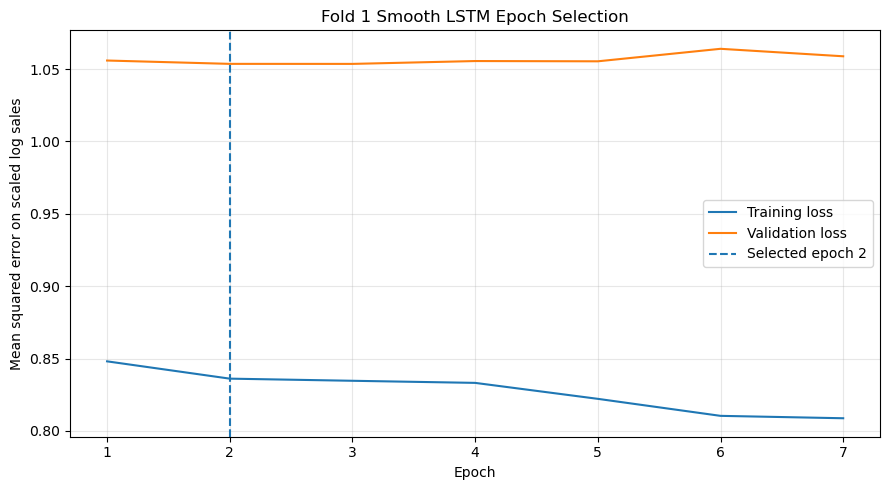


Fold 1 smooth validation diagnostic passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_pilot_validation_by_horizon.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step19\step19_pilot_epoch_selection.png


In [15]:
# Cell 11: Validate the selected Fold 1 smooth inner model

import matplotlib.pyplot as plt

print("Evaluating the selected inner-validation model")
print("-" * 70)

validation_prediction_start = (
    time.perf_counter()
)

pilot_validation_scaled_forecasts = (
    selection_model.predict(
        pilot_inner_data[
            "x_forecast"
        ],
        batch_size=BATCH_SIZE,
        verbose=0,
    )
)

validation_prediction_seconds = (
    time.perf_counter()
    - validation_prediction_start
)

pilot_validation_forecasts = (
    inverse_transform_forecasts(
        scaled_forecasts=(
            pilot_validation_scaled_forecasts
        ),
        series_means=(
            pilot_inner_data[
                "series_means"
            ]
        ),
        series_standard_deviations=(
            pilot_inner_data[
                "series_standard_deviations"
            ]
        ),
    )
)

pilot_validation_actual = (
    pilot_inner_data[
        "y_forecast_actual"
    ].astype(
        np.float64
    )
)

pilot_validation_forecasts = (
    pilot_validation_forecasts.astype(
        np.float64
    )
)

validation_errors = (
    pilot_validation_forecasts
    - pilot_validation_actual
)

validation_absolute_errors = np.abs(
    validation_errors
)

validation_squared_errors = np.square(
    validation_errors
)

validation_mae_actual_scale = float(
    validation_absolute_errors.mean()
)

validation_rmse_actual_scale = float(
    np.sqrt(
        validation_squared_errors.mean()
    )
)

validation_bias_actual_scale = float(
    validation_errors.mean()
)

validation_horizon_summary = pd.DataFrame(
    {
        "horizon": np.arange(
            1,
            OUTPUT_LENGTH + 1,
        ),
        "mae": (
            validation_absolute_errors
            .mean(axis=0)
        ),
        "rmse": np.sqrt(
            validation_squared_errors
            .mean(axis=0)
        ),
        "mean_error": (
            validation_errors
            .mean(axis=0)
        ),
        "mean_actual_sales": (
            pilot_validation_actual
            .mean(axis=0)
        ),
        "mean_forecast_sales": (
            pilot_validation_forecasts
            .mean(axis=0)
        ),
    }
)

validation_checks = {
    "Scaled forecast shape correct": (
        pilot_validation_scaled_forecasts.shape
        == (
            200,
            OUTPUT_LENGTH,
        )
    ),
    "Actual-scale forecast shape correct": (
        pilot_validation_forecasts.shape
        == (
            200,
            OUTPUT_LENGTH,
        )
    ),
    "Actual target shape correct": (
        pilot_validation_actual.shape
        == (
            200,
            OUTPUT_LENGTH,
        )
    ),
    "No non-finite forecasts": (
        np.isfinite(
            pilot_validation_forecasts
        ).all()
    ),
    "No negative forecasts": (
        (
            pilot_validation_forecasts
            < 0
        ).sum() == 0
    ),
    "No non-finite actual sales": (
        np.isfinite(
            pilot_validation_actual
        ).all()
    ),
    "Validation MAE finite": (
        np.isfinite(
            validation_mae_actual_scale
        )
    ),
    "Validation RMSE finite": (
        np.isfinite(
            validation_rmse_actual_scale
        )
    ),
    "28 horizon-summary rows": (
        len(
            validation_horizon_summary
        ) == 28
    ),
}

validation_check_table = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)

print()
print("Validation forecast diagnostics")
print("-" * 70)
print(
    "Prediction time:",
    f"{validation_prediction_seconds:.2f} seconds",
)
print(
    "Actual-scale validation MAE:",
    f"{validation_mae_actual_scale:.6f}",
)
print(
    "Actual-scale validation RMSE:",
    f"{validation_rmse_actual_scale:.6f}",
)
print(
    "Actual-scale mean error:",
    f"{validation_bias_actual_scale:.6f}",
)

display(
    validation_check_table
)

print("Validation performance by horizon")

display(
    validation_horizon_summary.round(6)
)

failed_validation_checks = [
    check
    for check, passed
    in validation_checks.items()
    if not passed
]

if failed_validation_checks:
    raise AssertionError(
        "Fold 1 smooth validation diagnostic failed:\n- "
        + "\n- ".join(
            failed_validation_checks
        )
    )

STEP19_VALIDATION_HORIZON_FILE = (
    STEP19_TABLE_DIR
    / "step19_pilot_validation_by_horizon.csv"
)

validation_horizon_summary.to_csv(
    STEP19_VALIDATION_HORIZON_FILE,
    index=False,
)

figure, axis = plt.subplots(
    figsize=(9, 5)
)

axis.plot(
    selection_history["epoch"],
    selection_history["loss"],
    label="Training loss",
)

axis.plot(
    selection_history["epoch"],
    selection_history["val_loss"],
    label="Validation loss",
)

axis.axvline(
    SELECTED_EPOCHS_PILOT,
    linestyle="--",
    label=(
        f"Selected epoch "
        f"{SELECTED_EPOCHS_PILOT}"
    ),
)

axis.set_title(
    "Fold 1 Smooth LSTM Epoch Selection"
)

axis.set_xlabel(
    "Epoch"
)

axis.set_ylabel(
    "Mean squared error on scaled log sales"
)

axis.legend()

axis.grid(
    alpha=0.3
)

figure.tight_layout()

STEP19_SELECTION_FIGURE_FILE = (
    STEP19_FIGURE_DIR
    / "step19_pilot_epoch_selection.png"
)

figure.savefig(
    STEP19_SELECTION_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print()
print(
    "Fold 1 smooth validation diagnostic passed."
)
print("Saved:")
print(STEP19_VALIDATION_HORIZON_FILE)
print(STEP19_SELECTION_FIGURE_FILE)

In [16]:
# Cell 12: Refit the Fold 1 smooth model on full outer training data

print("Preparing the Fold 1 smooth full-data refit")
print("-" * 70)

# Release the inner-selection model and large inner arrays
# before creating the full refit dataset.
if "selection_model" in globals():
    del selection_model

if "selection_training_dataset" in globals():
    del selection_training_dataset

keras.backend.clear_session()
gc.collect()

pilot_refit_data_start = (
    time.perf_counter()
)

pilot_refit_data = (
    prepare_lstm_fold_data(
        fold_number=PILOT_FOLD,
        demand_type=PILOT_DEMAND_TYPE,
        stage="refit",
    )
)

pilot_refit_data_seconds = (
    time.perf_counter()
    - pilot_refit_data_start
)

pilot_refit_metadata = (
    pilot_refit_data[
        "metadata"
    ]
)

pilot_refit_check_table = pd.DataFrame(
    {
        "check": (
            pilot_refit_data[
                "checks"
            ].keys()
        ),
        "passed": (
            pilot_refit_data[
                "checks"
            ].values()
        ),
    }
)

display(
    pilot_refit_check_table
)

if not pilot_refit_check_table[
    "passed"
].all():
    raise AssertionError(
        "Fold 1 smooth refit-data "
        "audit failed."
    )

keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

pilot_refit_model = (
    build_lstm_model()
)

pilot_refit_dataset = (
    make_training_dataset(
        x_values=(
            pilot_refit_data[
                "x_training"
            ]
        ),
        y_values=(
            pilot_refit_data[
                "y_training"
            ]
        ),
        batch_size=BATCH_SIZE,
    )
)

pilot_refit_timer = (
    EpochTimingCallback()
)

pilot_refit_start = (
    time.perf_counter()
)

pilot_refit_history_object = (
    pilot_refit_model.fit(
        pilot_refit_dataset,
        epochs=SELECTED_EPOCHS_PILOT,
        verbose=2,
        callbacks=[
            pilot_refit_timer,
            keras.callbacks.TerminateOnNaN(),
        ],
    )
)

pilot_refit_seconds = (
    time.perf_counter()
    - pilot_refit_start
)

pilot_refit_history = pd.DataFrame(
    pilot_refit_history_object.history
)

pilot_refit_history.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(pilot_refit_history) + 1,
    ),
)

pilot_refit_history[
    "epoch_seconds"
] = np.asarray(
    pilot_refit_timer.epoch_seconds,
    dtype=np.float64,
)

pilot_outer_scaled_forecasts = (
    pilot_refit_model.predict(
        pilot_refit_data[
            "x_forecast"
        ],
        batch_size=BATCH_SIZE,
        verbose=0,
    )
)

pilot_outer_forecasts = (
    inverse_transform_forecasts(
        scaled_forecasts=(
            pilot_outer_scaled_forecasts
        ),
        series_means=(
            pilot_refit_data[
                "series_means"
            ]
        ),
        series_standard_deviations=(
            pilot_refit_data[
                "series_standard_deviations"
            ]
        ),
    )
)

pilot_outer_actual = (
    pilot_refit_data[
        "y_forecast_actual"
    ].astype(
        np.float64
    )
)

pilot_outer_forecasts = (
    pilot_outer_forecasts.astype(
        np.float64
    )
)

pilot_outer_errors = (
    pilot_outer_forecasts
    - pilot_outer_actual
)

pilot_outer_mae = float(
    np.abs(
        pilot_outer_errors
    ).mean()
)

pilot_outer_rmse = float(
    np.sqrt(
        np.square(
            pilot_outer_errors
        ).mean()
    )
)

pilot_outer_mean_error = float(
    pilot_outer_errors.mean()
)

pilot_model_file = (
    STEP19_MODEL_DIR
    / "lstm_fold1_smooth.keras"
)

if pilot_model_file.exists():
    pilot_model_file.unlink()

pilot_refit_model.save(
    pilot_model_file
)

pilot_prediction_frame = pd.DataFrame(
    {
        "fold": PILOT_FOLD,
        DEMAND_TYPE_COLUMN: (
            PILOT_DEMAND_TYPE
        ),
        SERIES_COLUMN: np.repeat(
            pilot_refit_data[
                "series_ids"
            ],
            OUTPUT_LENGTH,
        ),
        DATE_COLUMN: np.tile(
            pilot_refit_data[
                "forecast_dates"
            ].to_numpy(),
            200,
        ),
        "horizon": np.tile(
            np.arange(
                1,
                OUTPUT_LENGTH + 1,
            ),
            200,
        ),
        "actual_sales": (
            pilot_outer_actual.reshape(-1)
        ),
        "lstm_forecast": (
            pilot_outer_forecasts.reshape(-1)
        ),
    }
)

pilot_outer_checks = {
    "Selected epoch count used": (
        len(
            pilot_refit_history
        )
        == SELECTED_EPOCHS_PILOT
    ),
    "5,600 pilot forecasts": (
        len(
            pilot_prediction_frame
        ) == 5_600
    ),
    "200 pilot series": (
        pilot_prediction_frame[
            SERIES_COLUMN
        ].nunique() == 200
    ),
    "28 pilot dates": (
        pilot_prediction_frame[
            DATE_COLUMN
        ].nunique() == 28
    ),
    "28 forecast horizons": (
        pilot_prediction_frame[
            "horizon"
        ].nunique() == 28
    ),
    "No missing forecasts": (
        pilot_prediction_frame[
            "lstm_forecast"
        ].isna().sum() == 0
    ),
    "No non-finite forecasts": (
        np.isfinite(
            pilot_prediction_frame[
                "lstm_forecast"
            ].to_numpy()
        ).all()
    ),
    "No negative forecasts": (
        (
            pilot_prediction_frame[
                "lstm_forecast"
            ] < 0
        ).sum() == 0
    ),
    "No duplicate forecast rows": (
        pilot_prediction_frame
        .duplicated(
            subset=[
                SERIES_COLUMN,
                DATE_COLUMN,
            ]
        )
        .sum() == 0
    ),
    "Outer MAE finite": (
        np.isfinite(
            pilot_outer_mae
        )
    ),
    "Outer RMSE finite": (
        np.isfinite(
            pilot_outer_rmse
        )
    ),
    "Saved model exists": (
        pilot_model_file.exists()
    ),
}

pilot_outer_check_table = pd.DataFrame(
    {
        "check": (
            pilot_outer_checks.keys()
        ),
        "passed": (
            pilot_outer_checks.values()
        ),
    }
)

pilot_outer_summary = pd.DataFrame(
    [
        {
            "fold": PILOT_FOLD,
            "demand_type": (
                PILOT_DEMAND_TYPE
            ),
            "selected_epochs": (
                SELECTED_EPOCHS_PILOT
            ),
            "refit_training_windows": (
                pilot_refit_metadata[
                    "training_windows"
                ]
            ),
            "refit_data_seconds": (
                pilot_refit_data_seconds
            ),
            "refit_training_seconds": (
                pilot_refit_seconds
            ),
            "refit_training_minutes": (
                pilot_refit_seconds
                / 60
            ),
            "outer_forecasts": 5_600,
            "outer_mae": (
                pilot_outer_mae
            ),
            "outer_rmse": (
                pilot_outer_rmse
            ),
            "outer_mean_error": (
                pilot_outer_mean_error
            ),
            "model_parameters": (
                pilot_refit_model
                .count_params()
            ),
        }
    ]
)

print()
print("Fold 1 smooth outer-test pilot")
print("-" * 70)
print(
    "Selected epochs:",
    SELECTED_EPOCHS_PILOT,
)
print(
    "Refit training windows:",
    f"{pilot_refit_metadata['training_windows']:,}",
)
print(
    "Refit runtime:",
    f"{pilot_refit_seconds / 60:.2f} minutes",
)
print(
    "Outer-test MAE:",
    f"{pilot_outer_mae:.6f}",
)
print(
    "Outer-test RMSE:",
    f"{pilot_outer_rmse:.6f}",
)
print(
    "Outer-test mean error:",
    f"{pilot_outer_mean_error:.6f}",
)

display(
    pilot_outer_check_table
)

display(
    pilot_outer_summary.round(6)
)

failed_pilot_outer_checks = [
    check
    for check, passed
    in pilot_outer_checks.items()
    if not passed
]

if failed_pilot_outer_checks:
    raise AssertionError(
        "Fold 1 smooth outer-test pilot failed:\n- "
        + "\n- ".join(
            failed_pilot_outer_checks
        )
    )

STEP19_PILOT_PREDICTIONS_FILE = (
    STEP19_RESULT_DIR
    / "step19_pilot_fold1_smooth_predictions.parquet"
)

STEP19_PILOT_OUTER_SUMMARY_FILE = (
    STEP19_TABLE_DIR
    / "step19_pilot_outer_summary.csv"
)

STEP19_PILOT_REFIT_HISTORY_FILE = (
    STEP19_TABLE_DIR
    / "step19_pilot_refit_history.csv"
)

pilot_prediction_frame.to_parquet(
    STEP19_PILOT_PREDICTIONS_FILE,
    index=False,
)

pilot_outer_summary.to_csv(
    STEP19_PILOT_OUTER_SUMMARY_FILE,
    index=False,
)

pilot_refit_history.to_csv(
    STEP19_PILOT_REFIT_HISTORY_FILE,
    index=False,
)

print()
print("Fold 1 smooth outer-test pilot passed.")
print("Saved:")
print(pilot_model_file)
print(STEP19_PILOT_PREDICTIONS_FILE)
print(STEP19_PILOT_OUTER_SUMMARY_FILE)
print(STEP19_PILOT_REFIT_HISTORY_FILE)

Preparing the Fold 1 smooth full-data refit
----------------------------------------------------------------------


,check,passed
0,Expected training windows,True
1,Training inputs shaped correctly,True
2,Training targets shaped correctly,True
3,200 forecast sequences,True
4,200 forecast targets,True
5,56 input days,True
6,28 target days,True
7,Training inputs finite,True
8,Training targets finite,True
9,Forecast inputs finite,True


Epoch 1/2
672/672 - 29s - 43ms/step - loss: 0.8451 - mae: 0.7222
Epoch 2/2
672/672 - 27s - 40ms/step - loss: 0.8334 - mae: 0.7147

Fold 1 smooth outer-test pilot
----------------------------------------------------------------------
Selected epochs: 2
Refit training windows: 343,600
Refit runtime: 0.93 minutes
Outer-test MAE: 2.985713
Outer-test RMSE: 5.329670
Outer-test mean error: -0.818315


,check,passed
0,Selected epoch count used,True
1,"5,600 pilot forecasts",True
2,200 pilot series,True
3,28 pilot dates,True
4,28 forecast horizons,True
5,No missing forecasts,True
6,No non-finite forecasts,True
7,No negative forecasts,True
8,No duplicate forecast rows,True
9,Outer MAE finite,True


,fold,demand_type,selected_epochs,refit_training_windows,refit_data_seconds,refit_training_seconds,refit_training_minutes,outer_forecasts,outer_mae,outer_rmse,outer_mean_error,model_parameters
0,1,smooth,2,343600,0.489296,55.701295,0.928355,5600,2.985713,5.32967,-0.818315,5356



Fold 1 smooth outer-test pilot passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\models\step19\lstm_fold1_smooth.keras
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\model_results\step19\step19_pilot_fold1_smooth_predictions.parquet
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_pilot_outer_summary.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_pilot_refit_history.csv


In [17]:
# Cell 13: Define the complete LSTM experiment function

import gc


EARLY_STOPPING_MIN_DELTA = 1e-4


def identify_selected_epoch(
    validation_losses,
    early_stopping_callback,
    minimum_delta=EARLY_STOPPING_MIN_DELTA,
):
    """
    Identify the epoch selected by Keras EarlyStopping.

    A manual min-delta-aware calculation is performed
    and compared with the callback result.
    """

    validation_losses = np.asarray(
        validation_losses,
        dtype=np.float64,
    )

    if validation_losses.ndim != 1:
        raise ValueError(
            "validation_losses must be one-dimensional."
        )

    if len(validation_losses) == 0:
        raise ValueError(
            "No validation losses were supplied."
        )

    manual_best_loss = np.inf
    manual_best_epoch_index = None

    for epoch_index, validation_loss in enumerate(
        validation_losses
    ):
        qualifies_as_improvement = (
            validation_loss
            < (
                manual_best_loss
                - minimum_delta
            )
        )

        if qualifies_as_improvement:
            manual_best_loss = float(
                validation_loss
            )

            manual_best_epoch_index = int(
                epoch_index
            )

    if manual_best_epoch_index is None:
        raise AssertionError(
            "No valid selected epoch was identified."
        )

    manual_selected_epoch = (
        manual_best_epoch_index + 1
    )

    callback_best_epoch_index = getattr(
        early_stopping_callback,
        "best_epoch",
        None,
    )

    if callback_best_epoch_index is None:
        callback_selected_epoch = (
            manual_selected_epoch
        )
    else:
        callback_selected_epoch = (
            int(callback_best_epoch_index)
            + 1
        )

    if (
        manual_selected_epoch
        != callback_selected_epoch
    ):
        raise AssertionError(
            "The manual and Keras EarlyStopping "
            "epoch selections do not agree."
        )

    absolute_minimum_epoch = int(
        np.argmin(validation_losses)
        + 1
    )

    return {
        "selected_epoch": (
            callback_selected_epoch
        ),
        "manual_selected_epoch": (
            manual_selected_epoch
        ),
        "callback_selected_epoch": (
            callback_selected_epoch
        ),
        "absolute_minimum_epoch": (
            absolute_minimum_epoch
        ),
        "selected_validation_loss": float(
            validation_losses[
                callback_selected_epoch - 1
            ]
        ),
        "absolute_minimum_validation_loss": float(
            validation_losses.min()
        ),
    }


def run_one_lstm_experiment(
    fold_number,
    demand_type,
):
    """
    Run one complete LSTM experiment:

    1. Prepare leakage-safe inner-training data.
    2. Select the epoch count using EarlyStopping.
    3. Validate that restored weights match the selected epoch.
    4. Prepare complete outer-training data.
    5. Rebuild and refit the model.
    6. Forecast the untouched 28-day outer-test horizon.
    7. Save the model, histories and forecasts.
    """

    model_start = time.perf_counter()

    print()
    print(
        f"Fold {fold_number}, {demand_type}"
    )
    print("-" * 70)

    # -------------------------------------------------
    # Inner epoch-selection stage
    # -------------------------------------------------

    inner_data_start = time.perf_counter()

    inner_data = prepare_lstm_fold_data(
        fold_number=fold_number,
        demand_type=demand_type,
        stage="inner",
    )

    inner_data_seconds = (
        time.perf_counter()
        - inner_data_start
    )

    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    selection_model = build_lstm_model()

    selection_dataset = make_training_dataset(
        x_values=inner_data[
            "x_training"
        ],
        y_values=inner_data[
            "y_training"
        ],
        batch_size=BATCH_SIZE,
    )

    selection_timer = EpochTimingCallback()

    early_stopping = (
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            min_delta=(
                EARLY_STOPPING_MIN_DELTA
            ),
            patience=(
                EARLY_STOPPING_PATIENCE
            ),
            restore_best_weights=True,
            verbose=1,
        )
    )

    selection_start = time.perf_counter()

    selection_history_object = (
        selection_model.fit(
            selection_dataset,
            validation_data=(
                inner_data[
                    "x_forecast"
                ],
                inner_data[
                    "y_forecast_scaled"
                ],
            ),
            epochs=MAX_EPOCHS,
            verbose=2,
            callbacks=[
                selection_timer,
                early_stopping,
                keras.callbacks.TerminateOnNaN(),
            ],
        )
    )

    selection_seconds = (
        time.perf_counter()
        - selection_start
    )

    selection_history = pd.DataFrame(
        selection_history_object.history
    )

    selection_history.insert(
        0,
        "epoch",
        np.arange(
            1,
            len(selection_history) + 1,
        ),
    )

    selection_history[
        "epoch_seconds"
    ] = np.asarray(
        selection_timer.epoch_seconds,
        dtype=np.float64,
    )

    selection_history.insert(
        0,
        DEMAND_TYPE_COLUMN,
        demand_type,
    )

    selection_history.insert(
        0,
        "fold",
        fold_number,
    )

    epoch_selection = (
        identify_selected_epoch(
            validation_losses=(
                selection_history[
                    "val_loss"
                ].to_numpy(
                    dtype=np.float64
                )
            ),
            early_stopping_callback=(
                early_stopping
            ),
            minimum_delta=(
                EARLY_STOPPING_MIN_DELTA
            ),
        )
    )

    selected_epochs = int(
        epoch_selection[
            "selected_epoch"
        ]
    )

    selected_history_row = (
        selection_history.loc[
            selection_history[
                "epoch"
            ] == selected_epochs
        ]
        .iloc[0]
    )

    restored_metrics = (
        selection_model.evaluate(
            inner_data[
                "x_forecast"
            ],
            inner_data[
                "y_forecast_scaled"
            ],
            batch_size=BATCH_SIZE,
            verbose=0,
            return_dict=True,
        )
    )

    restored_validation_loss = float(
        restored_metrics["loss"]
    )

    restored_validation_mae = float(
        restored_metrics["mae"]
    )

    selected_validation_loss = float(
        selected_history_row[
            "val_loss"
        ]
    )

    selected_validation_mae = float(
        selected_history_row[
            "val_mae"
        ]
    )

    inner_scaled_forecasts = (
        selection_model.predict(
            inner_data[
                "x_forecast"
            ],
            batch_size=BATCH_SIZE,
            verbose=0,
        )
    )

    inner_actual_forecasts = (
        inverse_transform_forecasts(
            scaled_forecasts=(
                inner_scaled_forecasts
            ),
            series_means=(
                inner_data[
                    "series_means"
                ]
            ),
            series_standard_deviations=(
                inner_data[
                    "series_standard_deviations"
                ]
            ),
        )
        .astype(np.float64)
    )

    inner_actual_targets = (
        inner_data[
            "y_forecast_actual"
        ]
        .astype(np.float64)
    )

    inner_errors = (
        inner_actual_forecasts
        - inner_actual_targets
    )

    inner_actual_mae = float(
        np.abs(inner_errors).mean()
    )

    inner_actual_rmse = float(
        np.sqrt(
            np.square(inner_errors).mean()
        )
    )

    inner_actual_mean_error = float(
        inner_errors.mean()
    )

    selection_checks = {
        "Selected epoch valid": (
            1
            <= selected_epochs
            <= len(selection_history)
        ),
        "Manual and callback epochs agree": (
            epoch_selection[
                "manual_selected_epoch"
            ]
            == epoch_selection[
                "callback_selected_epoch"
            ]
        ),
        "Restored loss matches selected epoch": (
            np.isclose(
                restored_validation_loss,
                selected_validation_loss,
                rtol=1e-5,
                atol=1e-5,
            )
        ),
        "Restored MAE matches selected epoch": (
            np.isclose(
                restored_validation_mae,
                selected_validation_mae,
                rtol=1e-5,
                atol=1e-5,
            )
        ),
        "Selection history finite": (
            np.isfinite(
                selection_history[
                    [
                        "loss",
                        "mae",
                        "val_loss",
                        "val_mae",
                        "epoch_seconds",
                    ]
                ].to_numpy(
                    dtype=np.float64
                )
            ).all()
        ),
        "Inner forecasts finite": (
            np.isfinite(
                inner_actual_forecasts
            ).all()
        ),
        "Inner forecasts non-negative": (
            (
                inner_actual_forecasts < 0
            ).sum() == 0
        ),
    }

    failed_selection_checks = [
        check
        for check, passed
        in selection_checks.items()
        if not passed
    ]

    if failed_selection_checks:
        raise AssertionError(
            f"Fold {fold_number}, {demand_type} "
            "selection audit failed:\n- "
            + "\n- ".join(
                failed_selection_checks
            )
        )

    selection_history_file = (
        STEP19_TABLE_DIR
        / (
            f"step19_selection_history_"
            f"fold{fold_number}_{demand_type}.csv"
        )
    )

    selection_history.to_csv(
        selection_history_file,
        index=False,
    )

    del selection_model
    del selection_dataset
    del inner_scaled_forecasts

    keras.backend.clear_session()
    gc.collect()

    # Retain only the small inner-stage values.
    inner_training_windows = int(
        inner_data[
            "metadata"
        ][
            "training_windows"
        ]
    )

    inner_constant_series = int(
        inner_data[
            "metadata"
        ][
            "constant_series_count"
        ]
    )

    del inner_data
    gc.collect()

    # -------------------------------------------------
    # Full outer-training refit stage
    # -------------------------------------------------

    refit_data_start = time.perf_counter()

    refit_data = prepare_lstm_fold_data(
        fold_number=fold_number,
        demand_type=demand_type,
        stage="refit",
    )

    refit_data_seconds = (
        time.perf_counter()
        - refit_data_start
    )

    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    final_model = build_lstm_model()

    refit_dataset = make_training_dataset(
        x_values=refit_data[
            "x_training"
        ],
        y_values=refit_data[
            "y_training"
        ],
        batch_size=BATCH_SIZE,
    )

    refit_timer = EpochTimingCallback()

    refit_start = time.perf_counter()

    refit_history_object = (
        final_model.fit(
            refit_dataset,
            epochs=selected_epochs,
            verbose=2,
            callbacks=[
                refit_timer,
                keras.callbacks.TerminateOnNaN(),
            ],
        )
    )

    refit_seconds = (
        time.perf_counter()
        - refit_start
    )

    refit_history = pd.DataFrame(
        refit_history_object.history
    )

    refit_history.insert(
        0,
        "epoch",
        np.arange(
            1,
            len(refit_history) + 1,
        ),
    )

    refit_history[
        "epoch_seconds"
    ] = np.asarray(
        refit_timer.epoch_seconds,
        dtype=np.float64,
    )

    refit_history.insert(
        0,
        DEMAND_TYPE_COLUMN,
        demand_type,
    )

    refit_history.insert(
        0,
        "fold",
        fold_number,
    )

    scaled_outer_forecasts = (
        final_model.predict(
            refit_data[
                "x_forecast"
            ],
            batch_size=BATCH_SIZE,
            verbose=0,
        )
    )

    outer_forecasts = (
        inverse_transform_forecasts(
            scaled_forecasts=(
                scaled_outer_forecasts
            ),
            series_means=(
                refit_data[
                    "series_means"
                ]
            ),
            series_standard_deviations=(
                refit_data[
                    "series_standard_deviations"
                ]
            ),
        )
        .astype(np.float64)
    )

    outer_actual = (
        refit_data[
            "y_forecast_actual"
        ]
        .astype(np.float64)
    )

    outer_errors = (
        outer_forecasts
        - outer_actual
    )

    outer_mae = float(
        np.abs(outer_errors).mean()
    )

    outer_rmse = float(
        np.sqrt(
            np.square(outer_errors).mean()
        )
    )

    outer_mean_error = float(
        outer_errors.mean()
    )

    prediction_frame = pd.DataFrame(
        {
            "fold": fold_number,
            DEMAND_TYPE_COLUMN: (
                demand_type
            ),
            SERIES_COLUMN: np.repeat(
                refit_data[
                    "series_ids"
                ],
                OUTPUT_LENGTH,
            ),
            DATE_COLUMN: np.tile(
                refit_data[
                    "forecast_dates"
                ].to_numpy(),
                200,
            ),
            "horizon": np.tile(
                np.arange(
                    1,
                    OUTPUT_LENGTH + 1,
                ),
                200,
            ),
            "actual_sales": (
                outer_actual.reshape(-1)
            ),
            "lstm_forecast": (
                outer_forecasts.reshape(-1)
            ),
        }
    )

    model_file = (
        STEP19_MODEL_DIR
        / (
            f"lstm_fold{fold_number}_"
            f"{demand_type}.keras"
        )
    )

    prediction_file = (
        STEP19_RESULT_DIR
        / (
            f"step19_lstm_predictions_"
            f"fold{fold_number}_"
            f"{demand_type}.parquet"
        )
    )

    refit_history_file = (
        STEP19_TABLE_DIR
        / (
            f"step19_refit_history_"
            f"fold{fold_number}_"
            f"{demand_type}.csv"
        )
    )

    if model_file.exists():
        model_file.unlink()

    final_model.save(
        model_file
    )

    prediction_frame.to_parquet(
        prediction_file,
        index=False,
    )

    refit_history.to_csv(
        refit_history_file,
        index=False,
    )

    final_checks = {
        "Selected epoch count used": (
            len(refit_history)
            == selected_epochs
        ),
        "5,600 outer forecasts": (
            len(prediction_frame)
            == 5_600
        ),
        "200 outer series": (
            prediction_frame[
                SERIES_COLUMN
            ].nunique() == 200
        ),
        "28 outer dates": (
            prediction_frame[
                DATE_COLUMN
            ].nunique() == 28
        ),
        "28 forecast horizons": (
            prediction_frame[
                "horizon"
            ].nunique() == 28
        ),
        "No duplicate forecasts": (
            prediction_frame
            .duplicated(
                subset=[
                    SERIES_COLUMN,
                    DATE_COLUMN,
                ]
            )
            .sum() == 0
        ),
        "No missing forecasts": (
            prediction_frame[
                "lstm_forecast"
            ].isna().sum() == 0
        ),
        "All forecasts finite": (
            np.isfinite(
                prediction_frame[
                    "lstm_forecast"
                ].to_numpy(
                    dtype=np.float64
                )
            ).all()
        ),
        "No negative forecasts": (
            (
                prediction_frame[
                    "lstm_forecast"
                ] < 0
            ).sum() == 0
        ),
        "Outer MAE finite": (
            np.isfinite(outer_mae)
        ),
        "Outer RMSE finite": (
            np.isfinite(outer_rmse)
        ),
        "Model file exists": (
            model_file.exists()
        ),
        "Prediction file exists": (
            prediction_file.exists()
        ),
        "Selection history exists": (
            selection_history_file.exists()
        ),
        "Refit history exists": (
            refit_history_file.exists()
        ),
    }

    failed_final_checks = [
        check
        for check, passed
        in final_checks.items()
        if not passed
    ]

    if failed_final_checks:
        raise AssertionError(
            f"Fold {fold_number}, {demand_type} "
            "final audit failed:\n- "
            + "\n- ".join(
                failed_final_checks
            )
        )

    model_seconds = (
        time.perf_counter()
        - model_start
    )

    result_record = {
        "fold": fold_number,
        "demand_type": demand_type,
        "epochs_completed": int(
            len(selection_history)
        ),
        "selected_epochs": (
            selected_epochs
        ),
        "manual_selected_epoch": (
            epoch_selection[
                "manual_selected_epoch"
            ]
        ),
        "callback_selected_epoch": (
            epoch_selection[
                "callback_selected_epoch"
            ]
        ),
        "absolute_minimum_epoch": (
            epoch_selection[
                "absolute_minimum_epoch"
            ]
        ),
        "selected_validation_loss": (
            selected_validation_loss
        ),
        "selected_validation_mae_scaled": (
            selected_validation_mae
        ),
        "absolute_minimum_validation_loss": (
            epoch_selection[
                "absolute_minimum_validation_loss"
            ]
        ),
        "restored_validation_loss": (
            restored_validation_loss
        ),
        "restored_validation_mae_scaled": (
            restored_validation_mae
        ),
        "inner_validation_mae": (
            inner_actual_mae
        ),
        "inner_validation_rmse": (
            inner_actual_rmse
        ),
        "inner_validation_mean_error": (
            inner_actual_mean_error
        ),
        "inner_training_windows": (
            inner_training_windows
        ),
        "inner_constant_series": (
            inner_constant_series
        ),
        "inner_data_seconds": (
            inner_data_seconds
        ),
        "selection_seconds": (
            selection_seconds
        ),
        "refit_training_windows": int(
            refit_data[
                "metadata"
            ][
                "training_windows"
            ]
        ),
        "refit_constant_series": int(
            refit_data[
                "metadata"
            ][
                "constant_series_count"
            ]
        ),
        "refit_data_seconds": (
            refit_data_seconds
        ),
        "refit_seconds": (
            refit_seconds
        ),
        "outer_forecasts": 5_600,
        "outer_mae": (
            outer_mae
        ),
        "outer_rmse": (
            outer_rmse
        ),
        "outer_mean_error": (
            outer_mean_error
        ),
        "model_parameters": int(
            final_model.count_params()
        ),
        "total_model_seconds": (
            model_seconds
        ),
        "total_model_minutes": (
            model_seconds / 60
        ),
        "model_file": (
            model_file.name
        ),
        "prediction_file": (
            prediction_file.name
        ),
        "selection_history_file": (
            selection_history_file.name
        ),
        "refit_history_file": (
            refit_history_file.name
        ),
    }

    print()
    print(
        "Selected epochs:",
        selected_epochs,
    )
    print(
        "Selection epochs completed:",
        len(selection_history),
    )
    print(
        "Inner validation MAE:",
        f"{inner_actual_mae:.6f}",
    )
    print(
        "Inner validation RMSE:",
        f"{inner_actual_rmse:.6f}",
    )
    print(
        "Outer-test MAE:",
        f"{outer_mae:.6f}",
    )
    print(
        "Outer-test RMSE:",
        f"{outer_rmse:.6f}",
    )
    print(
        "Outer-test mean error:",
        f"{outer_mean_error:.6f}",
    )
    print(
        "Total model runtime:",
        f"{model_seconds / 60:.2f} minutes",
    )
    print(
        "Model passed."
    )

    del final_model
    del refit_dataset
    del scaled_outer_forecasts
    del outer_forecasts
    del outer_actual
    del outer_errors
    del prediction_frame
    del refit_data

    keras.backend.clear_session()
    gc.collect()

    return result_record


print(
    "Complete Step 19 LSTM experiment "
    "function defined."
)

Complete Step 19 LSTM experiment function defined.


In [18]:
# Cell 14: Run all ten LSTM models

print("Starting the complete Step 19 LSTM run")
print("-" * 70)

full_lstm_start = time.perf_counter()

lstm_result_records = []

ordered_experiment_plan = (
    lstm_experiment_plan
    .copy()
)

demand_sort_order = {
    "smooth": 0,
    "erratic": 1,
}

ordered_experiment_plan[
    "demand_sort_order"
] = (
    ordered_experiment_plan[
        DEMAND_TYPE_COLUMN
    ].map(
        demand_sort_order
    )
)

ordered_experiment_plan = (
    ordered_experiment_plan
    .sort_values(
        [
            "fold",
            "demand_sort_order",
        ]
    )
    .drop(
        columns="demand_sort_order"
    )
    .reset_index(drop=True)
)

if len(ordered_experiment_plan) != 10:
    raise AssertionError(
        "Expected ten LSTM experiments."
    )

STEP19_PARTIAL_RESULTS_FILE = (
    STEP19_TABLE_DIR
    / "step19_lstm_results_partial.csv"
)

for model_number, plan_row in (
    ordered_experiment_plan.iterrows()
):
    fold_number = int(
        plan_row["fold"]
    )

    demand_type = str(
        plan_row[
            DEMAND_TYPE_COLUMN
        ]
    )

    print()
    print(
        f"Model {model_number + 1}/10"
    )

    try:
        model_result = (
            run_one_lstm_experiment(
                fold_number=fold_number,
                demand_type=demand_type,
            )
        )

        lstm_result_records.append(
            model_result
        )

        pd.DataFrame(
            lstm_result_records
        ).to_csv(
            STEP19_PARTIAL_RESULTS_FILE,
            index=False,
        )

    except Exception as error:
        print()
        print(
            f"Model failed: Fold {fold_number}, "
            f"{demand_type}"
        )
        print(
            f"{type(error).__name__}: {error}"
        )

        if lstm_result_records:
            pd.DataFrame(
                lstm_result_records
            ).to_csv(
                STEP19_PARTIAL_RESULTS_FILE,
                index=False,
            )

        raise

    finally:
        keras.backend.clear_session()
        gc.collect()

full_lstm_seconds = (
    time.perf_counter()
    - full_lstm_start
)

lstm_results = (
    pd.DataFrame(
        lstm_result_records
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

print()
print("Complete Step 19 training run finished")
print("-" * 70)
print(
    "Models completed:",
    len(lstm_results),
)
print(
    "Total runtime:",
    f"{full_lstm_seconds / 60:.2f} minutes",
)

display(
    lstm_results[
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "epochs_completed",
            "selected_epochs",
            "inner_validation_mae",
            "inner_validation_rmse",
            "outer_mae",
            "outer_rmse",
            "outer_mean_error",
            "total_model_minutes",
        ]
    ].round(6)
)

Starting the complete Step 19 LSTM run
----------------------------------------------------------------------

Model 1/10

Fold 1, smooth
----------------------------------------------------------------------
Epoch 1/50
661/661 - 29s - 44ms/step - loss: 0.8481 - mae: 0.7235 - val_loss: 1.0559 - val_mae: 0.7758
Epoch 2/50
661/661 - 25s - 38ms/step - loss: 0.8361 - mae: 0.7159 - val_loss: 1.0536 - val_mae: 0.7737
Epoch 3/50
661/661 - 25s - 37ms/step - loss: 0.8347 - mae: 0.7150 - val_loss: 1.0535 - val_mae: 0.7739
Epoch 4/50
661/661 - 26s - 40ms/step - loss: 0.8332 - mae: 0.7142 - val_loss: 1.0555 - val_mae: 0.7743
Epoch 5/50
661/661 - 28s - 42ms/step - loss: 0.8222 - mae: 0.7078 - val_loss: 1.0553 - val_mae: 0.7708
Epoch 6/50
661/661 - 26s - 39ms/step - loss: 0.8104 - mae: 0.7013 - val_loss: 1.0640 - val_mae: 0.7731
Epoch 7/50
661/661 - 25s - 38ms/step - loss: 0.8088 - mae: 0.7004 - val_loss: 1.0588 - val_mae: 0.7725
Epoch 7: early stopping
Restoring model weights from the end of the be

,fold,demand_type,epochs_completed,selected_epochs,inner_validation_mae,inner_validation_rmse,outer_mae,outer_rmse,outer_mean_error,total_model_minutes
0,1,erratic,9,4,3.643442,6.410825,3.663339,6.470479,-1.753881,5.768123
1,1,smooth,7,2,2.744061,4.681536,2.985713,5.329670,-0.818315,4.065405
2,2,erratic,16,11,3.635266,6.415760,3.782114,6.542154,-2.152346,11.804074
3,2,smooth,16,11,2.815579,4.973912,2.839777,4.768720,-1.462507,12.286400
4,3,erratic,18,13,3.778638,6.538324,3.506943,6.056247,-1.665225,15.655257
5,3,smooth,15,10,2.843436,4.791992,2.629036,4.338341,-1.169513,10.671336
6,4,erratic,15,10,3.499655,6.035638,3.470608,5.844841,-1.292961,41.286466
7,4,smooth,22,17,2.616503,4.303546,2.648374,4.170111,-0.905923,64.404508
8,5,erratic,13,8,3.475887,5.865606,3.323007,5.705051,-1.540097,333.528061
9,5,smooth,12,7,2.640920,4.161409,2.591799,4.184007,-1.124302,30.754864


In [19]:
# Cell 15: Combine and audit all ten LSTM results

print("Auditing the complete Step 19 training run")
print("-" * 70)

prediction_files = sorted(
    STEP19_RESULT_DIR.glob(
        "step19_lstm_predictions_fold*_*.parquet"
    )
)

model_files = sorted(
    STEP19_MODEL_DIR.glob(
        "lstm_fold*_*.keras"
    )
)

selection_history_files = sorted(
    STEP19_TABLE_DIR.glob(
        "step19_selection_history_fold*_*.csv"
    )
)

refit_history_files = sorted(
    STEP19_TABLE_DIR.glob(
        "step19_refit_history_fold*_*.csv"
    )
)

prediction_parts = [
    pd.read_parquet(
        prediction_file
    )
    for prediction_file in prediction_files
]

lstm_predictions = (
    pd.concat(
        prediction_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

del prediction_parts
gc.collect()

model_group_audit = (
    lstm_predictions
    .groupby(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        rows=(
            "lstm_forecast",
            "size",
        ),
        series_count=(
            SERIES_COLUMN,
            "nunique",
        ),
        date_count=(
            DATE_COLUMN,
            "nunique",
        ),
        horizon_count=(
            "horizon",
            "nunique",
        ),
        missing_forecasts=(
            "lstm_forecast",
            lambda values: int(
                values.isna().sum()
            ),
        ),
        negative_forecasts=(
            "lstm_forecast",
            lambda values: int(
                (values < 0).sum()
            ),
        ),
    )
)

duplicate_prediction_rows = int(
    lstm_predictions.duplicated(
        subset=[
            "fold",
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    ).sum()
)

complete_run_checks = {
    "Ten result rows": (
        len(lstm_results) == 10
    ),
    "Ten prediction files": (
        len(prediction_files) == 10
    ),
    "Ten model files": (
        len(model_files) == 10
    ),
    "Ten selection histories": (
        len(selection_history_files) == 10
    ),
    "Ten refit histories": (
        len(refit_history_files) == 10
    ),
    "56,000 combined forecasts": (
        len(lstm_predictions) == 56_000
    ),
    "Ten fold-demand groups": (
        len(model_group_audit) == 10
    ),
    "5,600 forecasts per model": (
        model_group_audit[
            "rows"
        ].eq(5_600).all()
    ),
    "200 series per model": (
        model_group_audit[
            "series_count"
        ].eq(200).all()
    ),
    "28 dates per model": (
        model_group_audit[
            "date_count"
        ].eq(28).all()
    ),
    "28 horizons per model": (
        model_group_audit[
            "horizon_count"
        ].eq(28).all()
    ),
    "No duplicate forecast rows": (
        duplicate_prediction_rows == 0
    ),
    "No missing forecasts": (
        lstm_predictions[
            "lstm_forecast"
        ].isna().sum() == 0
    ),
    "All forecasts finite": (
        np.isfinite(
            lstm_predictions[
                "lstm_forecast"
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "No negative forecasts": (
        (
            lstm_predictions[
                "lstm_forecast"
            ] < 0
        ).sum() == 0
    ),
    "All actual sales finite": (
        np.isfinite(
            lstm_predictions[
                "actual_sales"
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "All selected epochs valid": (
        lstm_results[
            "selected_epochs"
        ].between(
            1,
            MAX_EPOCHS,
            inclusive="both",
        ).all()
    ),
    "Manual and callback epochs agree": (
        (
            lstm_results[
                "manual_selected_epoch"
            ]
            == lstm_results[
                "callback_selected_epoch"
            ]
        ).all()
    ),
    "All result metrics finite": (
        np.isfinite(
            lstm_results[
                [
                    "selected_validation_loss",
                    "inner_validation_mae",
                    "inner_validation_rmse",
                    "outer_mae",
                    "outer_rmse",
                    "outer_mean_error",
                ]
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
}

complete_run_check_table = pd.DataFrame(
    {
        "check": complete_run_checks.keys(),
        "passed": complete_run_checks.values(),
    }
)

display(
    complete_run_check_table
)

print()
print("Per-model forecast audit")

display(
    model_group_audit
)

failed_complete_run_checks = [
    check
    for check, passed
    in complete_run_checks.items()
    if not passed
]

if failed_complete_run_checks:
    raise AssertionError(
        "Complete Step 19 training audit failed:\n- "
        + "\n- ".join(
            failed_complete_run_checks
        )
    )

STEP19_LSTM_RESULTS_FILE = (
    STEP19_TABLE_DIR
    / "step19_lstm_fold_results.csv"
)

STEP19_LSTM_PREDICTIONS_FILE = (
    STEP19_RESULT_DIR
    / "step19_lstm_predictions.parquet"
)

STEP19_TRAINING_AUDIT_FILE = (
    STEP19_TABLE_DIR
    / "step19_training_audit.csv"
)

lstm_results.to_csv(
    STEP19_LSTM_RESULTS_FILE,
    index=False,
)

lstm_predictions.to_parquet(
    STEP19_LSTM_PREDICTIONS_FILE,
    index=False,
)

complete_run_check_table.to_csv(
    STEP19_TRAINING_AUDIT_FILE,
    index=False,
)

if STEP19_PARTIAL_RESULTS_FILE.exists():
    STEP19_PARTIAL_RESULTS_FILE.unlink()

print()
print("Complete Step 19 training audit passed.")
print("Saved:")
print(STEP19_LSTM_RESULTS_FILE)
print(STEP19_LSTM_PREDICTIONS_FILE)
print(STEP19_TRAINING_AUDIT_FILE)

Auditing the complete Step 19 training run
----------------------------------------------------------------------


,check,passed
0,Ten result rows,True
1,Ten prediction files,True
2,Ten model files,True
3,Ten selection histories,True
4,Ten refit histories,True
5,"56,000 combined forecasts",True
6,Ten fold-demand groups,True
7,"5,600 forecasts per model",True
8,200 series per model,True
9,28 dates per model,True



Per-model forecast audit


,fold,demand_type,rows,series_count,date_count,horizon_count,missing_forecasts,negative_forecasts
0,1,erratic,5600,200,28,28,0,0
1,1,smooth,5600,200,28,28,0,0
2,2,erratic,5600,200,28,28,0,0
3,2,smooth,5600,200,28,28,0,0
4,3,erratic,5600,200,28,28,0,0
5,3,smooth,5600,200,28,28,0,0
6,4,erratic,5600,200,28,28,0,0
7,4,smooth,5600,200,28,28,0,0
8,5,erratic,5600,200,28,28,0,0
9,5,smooth,5600,200,28,28,0,0



Complete Step 19 training audit passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_lstm_fold_results.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\model_results\step19\step19_lstm_predictions.parquet
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_training_audit.csv


In [20]:
# Cell 16: Load and audit the Step 19 evaluation inputs

import gc
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq


def resolve_column(
    available_columns,
    aliases,
    description,
    required=True,
):
    """
    Return the first available column from a list of aliases.
    """

    for column_name in aliases:
        if column_name in available_columns:
            return column_name

    if required:
        raise KeyError(
            f"Could not identify the {description} column.\n"
            f"Available columns:\n{sorted(available_columns)}"
        )

    return None


print("Loading Step 19 evaluation inputs")
print("-" * 70)

STEP16_RESULT_DIR = (
    MODEL_RESULTS_DIR
    / "step16"
)

STEP19_LSTM_RESULTS_FILE = (
    STEP19_TABLE_DIR
    / "step19_lstm_fold_results.csv"
)

STEP19_LSTM_PREDICTIONS_FILE = (
    STEP19_RESULT_DIR
    / "step19_lstm_predictions.parquet"
)

required_evaluation_files = [
    MODELLING_DATA_FILE,
    STEP16_RESULTS_FILE,
    STEP19_LSTM_RESULTS_FILE,
    STEP19_LSTM_PREDICTIONS_FILE,
]

missing_evaluation_files = [
    file_path
    for file_path in required_evaluation_files
    if not file_path.exists()
]

if missing_evaluation_files:
    raise FileNotFoundError(
        "The following evaluation inputs are missing:\n- "
        + "\n- ".join(
            str(file_path)
            for file_path in missing_evaluation_files
        )
    )

# ---------------------------------------------------------
# Load the model-result tables
# ---------------------------------------------------------

step16_fold_results = pd.read_csv(
    STEP16_RESULTS_FILE,
    parse_dates=[
        "train_end",
        "test_start",
        "test_end",
    ],
)

lstm_results = pd.read_csv(
    STEP19_LSTM_RESULTS_FILE
)

lstm_predictions = pd.read_parquet(
    STEP19_LSTM_PREDICTIONS_FILE
)

step16_fold_results[
    DEMAND_TYPE_COLUMN
] = (
    step16_fold_results[
        DEMAND_TYPE_COLUMN
    ].astype(str)
)

lstm_results[
    DEMAND_TYPE_COLUMN
] = (
    lstm_results[
        DEMAND_TYPE_COLUMN
    ].astype(str)
)

lstm_predictions[
    DEMAND_TYPE_COLUMN
] = (
    lstm_predictions[
        DEMAND_TYPE_COLUMN
    ].astype(str)
)

lstm_predictions[
    SERIES_COLUMN
] = (
    lstm_predictions[
        SERIES_COLUMN
    ].astype(str)
)

lstm_predictions[
    DATE_COLUMN
] = pd.to_datetime(
    lstm_predictions[
        DATE_COLUMN
    ]
)

# ---------------------------------------------------------
# Identify the Step 16 prediction file
# ---------------------------------------------------------

step16_parquet_candidates = sorted(
    STEP16_RESULT_DIR.rglob(
        "*.parquet"
    )
)

if not step16_parquet_candidates:
    step16_parquet_candidates = sorted(
        MODEL_RESULTS_DIR.rglob(
            "*step16*.parquet"
        )
    )

if not step16_parquet_candidates:
    raise FileNotFoundError(
        "No Step 16 Parquet prediction files were found."
    )

forecast_aliases = [
    "xgb_forecast",
    "forecast",
    "prediction",
    "predicted_sales",
    "recursive_forecast",
    "stored_forecast",
    "y_pred",
]

fold_aliases = [
    "fold",
]

demand_aliases = [
    DEMAND_TYPE_COLUMN,
    "demand",
    "type",
]

series_aliases = [
    SERIES_COLUMN,
    "series_id",
    "item_store_id",
]

date_aliases = [
    DATE_COLUMN,
    "forecast_date",
    "ds",
]

candidate_records = []

for candidate_path in step16_parquet_candidates:
    parquet_file = pq.ParquetFile(
        candidate_path
    )

    candidate_columns = (
        parquet_file.schema.names
    )

    candidate_records.append(
        {
            "path": candidate_path,
            "file": candidate_path.name,
            "rows": (
                parquet_file
                .metadata
                .num_rows
            ),
            "columns": candidate_columns,
            "has_fold": any(
                alias in candidate_columns
                for alias in fold_aliases
            ),
            "has_demand_type": any(
                alias in candidate_columns
                for alias in demand_aliases
            ),
            "has_series": any(
                alias in candidate_columns
                for alias in series_aliases
            ),
            "has_date": any(
                alias in candidate_columns
                for alias in date_aliases
            ),
            "has_forecast": any(
                alias in candidate_columns
                for alias in forecast_aliases
            ),
        }
    )

step16_candidate_audit = pd.DataFrame(
    candidate_records
)

valid_prediction_candidates = (
    step16_candidate_audit.loc[
        step16_candidate_audit[
            [
                "has_fold",
                "has_demand_type",
                "has_series",
                "has_date",
                "has_forecast",
            ]
        ].all(axis=1)
    ]
    .copy()
)

print("Step 16 Parquet candidates")

display(
    step16_candidate_audit[
        [
            "file",
            "rows",
            "has_fold",
            "has_demand_type",
            "has_series",
            "has_date",
            "has_forecast",
        ]
    ]
)

if valid_prediction_candidates.empty:
    raise FileNotFoundError(
        "No Step 16 Parquet file contained the "
        "required prediction columns."
    )

combined_candidates = (
    valid_prediction_candidates.loc[
        valid_prediction_candidates[
            "rows"
        ] >= 112_000
    ]
    .sort_values(
        "rows",
        ascending=False,
    )
)

if not combined_candidates.empty:
    STEP16_PREDICTIONS_FILE = (
        combined_candidates
        .iloc[0][
            "path"
        ]
    )

    step16_predictions = pd.read_parquet(
        STEP16_PREDICTIONS_FILE
    )

    step16_prediction_source = (
        f"Combined file: "
        f"{STEP16_PREDICTIONS_FILE.name}"
    )

else:
    individual_candidates = (
        valid_prediction_candidates.loc[
            valid_prediction_candidates[
                "rows"
            ] == 5_600
        ]
    )

    if len(individual_candidates) < 20:
        raise AssertionError(
            "A combined Step 16 prediction file was not found, "
            "and fewer than 20 individual prediction files "
            "were available."
        )

    individual_prediction_parts = [
        pd.read_parquet(
            file_path
        )
        for file_path in (
            individual_candidates[
                "path"
            ]
        )
    ]

    step16_predictions = pd.concat(
        individual_prediction_parts,
        ignore_index=True,
    )

    del individual_prediction_parts

    step16_prediction_source = (
        f"Combined from "
        f"{len(individual_candidates)} individual files"
    )

    STEP16_PREDICTIONS_FILE = None

gc.collect()

# ---------------------------------------------------------
# Standardise the Step 16 prediction columns
# ---------------------------------------------------------

step16_prediction_columns = (
    step16_predictions.columns.tolist()
)

STEP16_FOLD_COLUMN = resolve_column(
    step16_prediction_columns,
    fold_aliases,
    "Step 16 fold",
)

STEP16_DEMAND_COLUMN = resolve_column(
    step16_prediction_columns,
    demand_aliases,
    "Step 16 demand type",
)

STEP16_SERIES_COLUMN = resolve_column(
    step16_prediction_columns,
    series_aliases,
    "Step 16 series identifier",
)

STEP16_DATE_COLUMN = resolve_column(
    step16_prediction_columns,
    date_aliases,
    "Step 16 forecast date",
)

STEP16_FORECAST_COLUMN = resolve_column(
    step16_prediction_columns,
    forecast_aliases,
    "Step 16 XGBoost forecast",
)

step16_predictions = (
    step16_predictions.rename(
        columns={
            STEP16_FOLD_COLUMN: "fold",
            STEP16_DEMAND_COLUMN: (
                DEMAND_TYPE_COLUMN
            ),
            STEP16_SERIES_COLUMN: (
                SERIES_COLUMN
            ),
            STEP16_DATE_COLUMN: (
                DATE_COLUMN
            ),
            STEP16_FORECAST_COLUMN: (
                "xgb_forecast"
            ),
        }
    )
)

step16_predictions[
    DEMAND_TYPE_COLUMN
] = (
    step16_predictions[
        DEMAND_TYPE_COLUMN
    ].astype(str)
)

step16_predictions[
    SERIES_COLUMN
] = (
    step16_predictions[
        SERIES_COLUMN
    ].astype(str)
)

step16_predictions[
    DATE_COLUMN
] = pd.to_datetime(
    step16_predictions[
        DATE_COLUMN
    ]
)

step16_predictions = (
    step16_predictions.loc[
        step16_predictions[
            DEMAND_TYPE_COLUMN
        ].isin(
            LSTM_DEMAND_TYPES
        ),
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
            DATE_COLUMN,
            "xgb_forecast",
        ],
    ]
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Resolve seasonal-naive comparison columns
# ---------------------------------------------------------

step16_result_columns = (
    step16_fold_results.columns.tolist()
)

BASELINE_WRMSSE_COLUMN = resolve_column(
    step16_result_columns,
    [
        "baseline_wrmsse",
        "seasonal_naive_wrmsse",
        "naive_wrmsse",
    ],
    "seasonal-naive WRMSSE",
)

BASELINE_MAE_COLUMN = resolve_column(
    step16_result_columns,
    [
        "baseline_mae",
        "seasonal_naive_mae",
        "naive_mae",
    ],
    "seasonal-naive MAE",
)

BASELINE_RMSE_COLUMN = resolve_column(
    step16_result_columns,
    [
        "baseline_rmse",
        "seasonal_naive_rmse",
        "naive_rmse",
    ],
    "seasonal-naive RMSE",
)

# ---------------------------------------------------------
# Load only the columns required by the scorer
# ---------------------------------------------------------

required_panel_columns = [
    SERIES_COLUMN,
    DATE_COLUMN,
    TARGET_COLUMN,
    DEMAND_TYPE_COLUMN,
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "sell_price",
]

panel_schema_columns = (
    pq.ParquetFile(
        MODELLING_DATA_FILE
    )
    .schema
    .names
)

missing_panel_columns = sorted(
    set(
        required_panel_columns
    ).difference(
        panel_schema_columns
    )
)

if missing_panel_columns:
    raise KeyError(
        "The modelling dataset is missing columns "
        "required for the hierarchy scorer:\n- "
        + "\n- ".join(
            missing_panel_columns
        )
    )

evaluation_panel = pd.read_parquet(
    MODELLING_DATA_FILE,
    columns=required_panel_columns,
)

evaluation_panel[
    SERIES_COLUMN
] = (
    evaluation_panel[
        SERIES_COLUMN
    ].astype(str)
)

evaluation_panel[
    DEMAND_TYPE_COLUMN
] = (
    evaluation_panel[
        DEMAND_TYPE_COLUMN
    ].astype(str)
)

evaluation_panel[
    DATE_COLUMN
] = pd.to_datetime(
    evaluation_panel[
        DATE_COLUMN
    ]
)

evaluation_panel = (
    evaluation_panel.loc[
        evaluation_panel[
            DEMAND_TYPE_COLUMN
        ].isin(
            LSTM_DEMAND_TYPES
        )
    ]
    .sort_values(
        [
            DEMAND_TYPE_COLUMN,
            SERIES_COLUMN,
            DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

evaluation_input_checks = {
    "Ten LSTM result rows": (
        len(lstm_results) == 10
    ),
    "56,000 LSTM predictions": (
        len(lstm_predictions) == 56_000
    ),
    "56,000 smooth and erratic XGBoost predictions": (
        len(step16_predictions) == 56_000
    ),
    "776,400 evaluation-panel rows": (
        len(evaluation_panel) == 776_400
    ),
    "No duplicate LSTM predictions": (
        lstm_predictions.duplicated(
            subset=[
                "fold",
                DEMAND_TYPE_COLUMN,
                SERIES_COLUMN,
                DATE_COLUMN,
            ]
        ).sum() == 0
    ),
    "No duplicate XGBoost predictions": (
        step16_predictions.duplicated(
            subset=[
                "fold",
                DEMAND_TYPE_COLUMN,
                SERIES_COLUMN,
                DATE_COLUMN,
            ]
        ).sum() == 0
    ),
    "LSTM forecasts finite": (
        np.isfinite(
            lstm_predictions[
                "lstm_forecast"
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "XGBoost forecasts finite": (
        np.isfinite(
            step16_predictions[
                "xgb_forecast"
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "No negative LSTM forecasts": (
        (
            lstm_predictions[
                "lstm_forecast"
            ] < 0
        ).sum() == 0
    ),
    "No negative XGBoost forecasts": (
        (
            step16_predictions[
                "xgb_forecast"
            ] < 0
        ).sum() == 0
    ),
}

evaluation_input_check_table = pd.DataFrame(
    {
        "check": (
            evaluation_input_checks.keys()
        ),
        "passed": (
            evaluation_input_checks.values()
        ),
    }
)

print()
print("Selected Step 16 prediction source:")
print(step16_prediction_source)

print()
print("Resolved Step 16 columns")
print("-" * 70)
print(
    "Forecast column:",
    STEP16_FORECAST_COLUMN,
)
print(
    "Baseline WRMSSE column:",
    BASELINE_WRMSSE_COLUMN,
)
print(
    "Baseline MAE column:",
    BASELINE_MAE_COLUMN,
)
print(
    "Baseline RMSE column:",
    BASELINE_RMSE_COLUMN,
)

print()
print("Evaluation input checks")

display(
    evaluation_input_check_table
)

failed_evaluation_input_checks = [
    check
    for check, passed
    in evaluation_input_checks.items()
    if not passed
]

if failed_evaluation_input_checks:
    raise AssertionError(
        "Step 19 evaluation-input audit failed:\n- "
        + "\n- ".join(
            failed_evaluation_input_checks
        )
    )

print()
print("Step 19 evaluation inputs passed.")

Loading Step 19 evaluation inputs
----------------------------------------------------------------------
Step 16 Parquet candidates


,file,rows,has_fold,has_demand_type,has_series,has_date,has_forecast
0,step16_predictions_fold1_erratic.parquet,5600,True,True,True,True,True
1,step16_predictions_fold1_intermittent.parquet,5600,True,True,True,True,True
2,step16_predictions_fold1_lumpy.parquet,5600,True,True,True,True,True
3,step16_predictions_fold1_smooth.parquet,5600,True,True,True,True,True
4,step16_predictions_fold2_erratic.parquet,5600,True,True,True,True,True
5,step16_predictions_fold2_intermittent.parquet,5600,True,True,True,True,True
6,step16_predictions_fold2_lumpy.parquet,5600,True,True,True,True,True
7,step16_predictions_fold2_smooth.parquet,5600,True,True,True,True,True
8,step16_predictions_fold3_erratic.parquet,5600,True,True,True,True,True
9,step16_predictions_fold3_intermittent.parquet,5600,True,True,True,True,True



Selected Step 16 prediction source:
Combined file: step16_xgb_predictions.parquet

Resolved Step 16 columns
----------------------------------------------------------------------
Forecast column: xgb_forecast
Baseline WRMSSE column: naive_wrmsse
Baseline MAE column: naive_mae
Baseline RMSE column: naive_rmse

Evaluation input checks


,check,passed
0,Ten LSTM result rows,True
1,"56,000 LSTM predictions",True
2,"56,000 smooth and erratic XGBoost predictions",True
3,"776,400 evaluation-panel rows",True
4,No duplicate LSTM predictions,True
5,No duplicate XGBoost predictions,True
6,LSTM forecasts finite,True
7,XGBoost forecasts finite,True
8,No negative LSTM forecasts,True
9,No negative XGBoost forecasts,True



Step 19 evaluation inputs passed.


In [21]:
# Cell 17: Define and audit the exact 12-level subset WRMSSE scorer

HIERARCHY_DEFINITIONS = [
    (
        1,
        "Total",
        [],
    ),
    (
        2,
        "State",
        [
            "state_id",
        ],
    ),
    (
        3,
        "Store",
        [
            "store_id",
        ],
    ),
    (
        4,
        "Category",
        [
            "cat_id",
        ],
    ),
    (
        5,
        "Department",
        [
            "dept_id",
        ],
    ),
    (
        6,
        "State × Category",
        [
            "state_id",
            "cat_id",
        ],
    ),
    (
        7,
        "State × Department",
        [
            "state_id",
            "dept_id",
        ],
    ),
    (
        8,
        "Store × Category",
        [
            "store_id",
            "cat_id",
        ],
    ),
    (
        9,
        "Store × Department",
        [
            "store_id",
            "dept_id",
        ],
    ),
    (
        10,
        "Item",
        [
            "item_id",
        ],
    ),
    (
        11,
        "Item × State",
        [
            "item_id",
            "state_id",
        ],
    ),
    (
        12,
        "Item × Store",
        [
            "item_id",
            "store_id",
        ],
    ),
]


def aggregate_matrix_by_group(
    value_matrix,
    group_keys,
):
    """
    Aggregate a bottom-level matrix using fixed hierarchy keys.
    """

    value_frame = pd.DataFrame(
        value_matrix
    )

    grouped_frame = value_frame.groupby(
        np.asarray(
            group_keys,
            dtype=str,
        ),
        sort=True,
    ).sum()

    return (
        grouped_frame.index
        .astype(str)
        .to_numpy(),
        grouped_frame.to_numpy(
            dtype=np.float64
        ),
    )


def calculate_rmsse_scale(
    sales_series,
):
    """
    Calculate the M5 RMSSE scale after removing
    leading zero observations.
    """

    sales_series = np.asarray(
        sales_series,
        dtype=np.float64,
    )

    nonzero_positions = np.flatnonzero(
        sales_series != 0
    )

    if len(nonzero_positions) == 0:
        return np.nan

    first_nonzero_position = int(
        nonzero_positions[0]
    )

    trimmed_sales = sales_series[
        first_nonzero_position:
    ]

    if len(trimmed_sales) < 2:
        return np.nan

    squared_differences = np.square(
        np.diff(
            trimmed_sales
        )
    )

    if len(squared_differences) == 0:
        return np.nan

    return float(
        squared_differences.mean()
    )


def prepare_subset_wrmsse_components(
    fold_number,
    demand_type,
):
    """
    Prepare hierarchy keys, scales, globally normalised
    weights and outer-test actual sales for one fold/type.
    """

    fold_rows = (
        step16_fold_results.loc[
            (
                step16_fold_results[
                    "fold"
                ] == fold_number
            )
            & (
                step16_fold_results[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            )
        ]
    )

    if len(fold_rows) != 1:
        raise AssertionError(
            f"Expected one Step 16 row for Fold "
            f"{fold_number}, {demand_type}."
        )

    fold_row = fold_rows.iloc[0]

    train_end = pd.Timestamp(
        fold_row[
            "train_end"
        ]
    )

    test_start = pd.Timestamp(
        fold_row[
            "test_start"
        ]
    )

    test_end = pd.Timestamp(
        fold_row[
            "test_end"
        ]
    )

    type_panel = (
        evaluation_panel.loc[
            evaluation_panel[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        ]
        .copy()
    )

    metadata_columns = [
        SERIES_COLUMN,
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id",
    ]

    metadata_variation = (
        type_panel
        .groupby(
            SERIES_COLUMN,
            observed=True,
        )[
            [
                "item_id",
                "dept_id",
                "cat_id",
                "store_id",
                "state_id",
            ]
        ]
        .nunique()
    )

    if (
        metadata_variation
        .gt(1)
        .any()
        .any()
    ):
        raise AssertionError(
            "Hierarchy metadata changed within one "
            "bottom-level series."
        )

    series_metadata = (
        type_panel[
            metadata_columns
        ]
        .drop_duplicates(
            subset=[
                SERIES_COLUMN,
            ]
        )
        .set_index(
            SERIES_COLUMN
        )
        .sort_index()
    )

    sales_wide = (
        type_panel
        .pivot(
            index=SERIES_COLUMN,
            columns=DATE_COLUMN,
            values=TARGET_COLUMN,
        )
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    price_wide = (
        type_panel
        .pivot(
            index=SERIES_COLUMN,
            columns=DATE_COLUMN,
            values="sell_price",
        )
        .reindex(
            index=sales_wide.index,
            columns=sales_wide.columns,
        )
    )

    series_ids = (
        sales_wide.index
        .astype(str)
        .to_numpy()
    )

    all_dates = pd.DatetimeIndex(
        sales_wide.columns
    )

    train_dates = all_dates[
        all_dates <= train_end
    ]

    test_dates = all_dates[
        (
            all_dates >= test_start
        )
        & (
            all_dates <= test_end
        )
    ]

    if len(test_dates) != 28:
        raise AssertionError(
            f"Fold {fold_number}, {demand_type} "
            "does not contain 28 test dates."
        )

    if len(train_dates) < 28:
        raise AssertionError(
            "Fewer than 28 training dates were available."
        )

    training_sales = (
        sales_wide[
            train_dates
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    test_actual = (
        sales_wide[
            test_dates
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    weight_dates = train_dates[
        -28:
    ]

    weight_sales = (
        sales_wide[
            weight_dates
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    weight_prices = (
        price_wide[
            weight_dates
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    positive_sales_missing_price = (
        (
            weight_sales > 0
        )
        & np.isnan(
            weight_prices
        )
    )

    if positive_sales_missing_price.any():
        raise AssertionError(
            f"Fold {fold_number}, {demand_type} "
            "contains positive sales with missing price "
            "during the 28-day weight period."
        )

    weight_revenue = (
        weight_sales
        * np.nan_to_num(
            weight_prices,
            nan=0.0,
        )
    )

    level_components = []
    total_raw_weight = 0.0

    for (
        level_number,
        level_name,
        grouping_columns,
    ) in HIERARCHY_DEFINITIONS:

        if grouping_columns:
            group_keys = (
                series_metadata[
                    grouping_columns
                ]
                .astype(str)
                .agg(
                    "||".join,
                    axis=1,
                )
                .to_numpy()
            )
        else:
            group_keys = np.repeat(
                "__TOTAL__",
                len(series_metadata),
            )

        (
            hierarchy_ids,
            aggregated_training_sales,
        ) = aggregate_matrix_by_group(
            value_matrix=training_sales,
            group_keys=group_keys,
        )

        (
            revenue_hierarchy_ids,
            aggregated_revenue,
        ) = aggregate_matrix_by_group(
            value_matrix=weight_revenue,
            group_keys=group_keys,
        )

        if not np.array_equal(
            hierarchy_ids,
            revenue_hierarchy_ids,
        ):
            raise AssertionError(
                f"Hierarchy order mismatch at level "
                f"{level_number}."
            )

        scales = np.asarray(
            [
                calculate_rmsse_scale(
                    hierarchy_sales
                )
                for hierarchy_sales
                in aggregated_training_sales
            ],
            dtype=np.float64,
        )

        raw_weights = (
            aggregated_revenue.sum(
                axis=1
            )
        )

        total_raw_weight += float(
            raw_weights.sum()
        )

        level_components.append(
            {
                "level": level_number,
                "level_name": level_name,
                "grouping_columns": (
                    grouping_columns
                ),
                "group_keys": group_keys,
                "hierarchy_ids": (
                    hierarchy_ids
                ),
                "scales": scales,
                "raw_weights": (
                    raw_weights
                ),
            }
        )

    if not np.isfinite(
        total_raw_weight
    ):
        raise AssertionError(
            "The total hierarchy weight is not finite."
        )

    if total_raw_weight <= 0:
        raise AssertionError(
            "The total hierarchy weight is not positive."
        )

    positive_weight_invalid_scales = 0

    for level_component in level_components:
        level_component[
            "weights"
        ] = (
            level_component[
                "raw_weights"
            ]
            / total_raw_weight
        )

        invalid_scale_mask = (
            ~np.isfinite(
                level_component[
                    "scales"
                ]
            )
            | (
                level_component[
                    "scales"
                ] <= 0
            )
        )

        positive_weight_invalid_scales += int(
            (
                invalid_scale_mask
                & (
                    level_component[
                        "weights"
                    ] > 0
                )
            ).sum()
        )

    if positive_weight_invalid_scales != 0:
        raise AssertionError(
            "At least one positive-weight hierarchy series "
            "has an invalid RMSSE scale."
        )

    total_normalised_weight = sum(
        float(
            level_component[
                "weights"
            ].sum()
        )
        for level_component
        in level_components
    )

    component_checks = {
        "200 bottom-level series": (
            len(series_ids) == 200
        ),
        "28 outer-test dates": (
            len(test_dates) == 28
        ),
        "Twelve hierarchy levels": (
            len(level_components) == 12
        ),
        "All training sales finite": (
            np.isfinite(
                training_sales
            ).all()
        ),
        "All test actuals finite": (
            np.isfinite(
                test_actual
            ).all()
        ),
        "No negative training sales": (
            (
                training_sales < 0
            ).sum() == 0
        ),
        "No negative test actuals": (
            (
                test_actual < 0
            ).sum() == 0
        ),
        "No positive-weight invalid scales": (
            positive_weight_invalid_scales
            == 0
        ),
        "Normalised weights sum to one": (
            np.isclose(
                total_normalised_weight,
                1.0,
                rtol=1e-12,
                atol=1e-12,
            )
        ),
    }

    failed_component_checks = [
        check
        for check, passed
        in component_checks.items()
        if not passed
    ]

    if failed_component_checks:
        raise AssertionError(
            f"Fold {fold_number}, {demand_type} "
            "WRMSSE component audit failed:\n- "
            + "\n- ".join(
                failed_component_checks
            )
        )

    return {
        "fold": fold_number,
        "demand_type": demand_type,
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
        "series_ids": series_ids,
        "test_dates": test_dates,
        "test_actual": test_actual,
        "series_metadata": (
            series_metadata
        ),
        "level_components": (
            level_components
        ),
        "total_raw_weight": (
            total_raw_weight
        ),
        "checks": component_checks,
    }


def score_subset_forecasts(
    forecast_frame,
    forecast_column,
    scorer_components,
    model_name,
):
    """
    Calculate exact subset WRMSSE and bottom-level
    MAE/RMSE for one model, fold and demand type.
    """

    forecast_wide = (
        forecast_frame
        .pivot(
            index=SERIES_COLUMN,
            columns=DATE_COLUMN,
            values=forecast_column,
        )
        .reindex(
            index=(
                scorer_components[
                    "series_ids"
                ]
            ),
            columns=(
                scorer_components[
                    "test_dates"
                ]
            ),
        )
    )

    if forecast_wide.isna().any().any():
        raise AssertionError(
            f"{model_name} forecasts could not be aligned "
            "to every required series and date."
        )

    bottom_forecast = (
        forecast_wide.to_numpy(
            dtype=np.float64
        )
    )

    bottom_actual = (
        scorer_components[
            "test_actual"
        ]
    )

    bottom_errors = (
        bottom_forecast
        - bottom_actual
    )

    bottom_mae = float(
        np.abs(
            bottom_errors
        ).mean()
    )

    bottom_rmse = float(
        np.sqrt(
            np.square(
                bottom_errors
            ).mean()
        )
    )

    bottom_mean_error = float(
        bottom_errors.mean()
    )

    level_records = []
    overall_wrmsse = 0.0

    for level_component in (
        scorer_components[
            "level_components"
        ]
    ):
        (
            actual_hierarchy_ids,
            aggregated_actual,
        ) = aggregate_matrix_by_group(
            value_matrix=bottom_actual,
            group_keys=(
                level_component[
                    "group_keys"
                ]
            ),
        )

        (
            forecast_hierarchy_ids,
            aggregated_forecast,
        ) = aggregate_matrix_by_group(
            value_matrix=bottom_forecast,
            group_keys=(
                level_component[
                    "group_keys"
                ]
            ),
        )

        if not np.array_equal(
            actual_hierarchy_ids,
            level_component[
                "hierarchy_ids"
            ],
        ):
            raise AssertionError(
                "Actual hierarchy order changed during scoring."
            )

        if not np.array_equal(
            forecast_hierarchy_ids,
            level_component[
                "hierarchy_ids"
            ],
        ):
            raise AssertionError(
                "Forecast hierarchy order changed during scoring."
            )

        hierarchy_rmse = np.sqrt(
            np.mean(
                np.square(
                    aggregated_forecast
                    - aggregated_actual
                ),
                axis=1,
            )
        )

        scales = (
            level_component[
                "scales"
            ]
        )

        weights = (
            level_component[
                "weights"
            ]
        )

        valid_scale_mask = (
            np.isfinite(scales)
            & (
                scales > 0
            )
        )

        hierarchy_rmsse = np.zeros(
            len(scales),
            dtype=np.float64,
        )

        hierarchy_rmsse[
            valid_scale_mask
        ] = (
            hierarchy_rmse[
                valid_scale_mask
            ]
            / np.sqrt(
                scales[
                    valid_scale_mask
                ]
            )
        )

        invalid_positive_weight = (
            ~valid_scale_mask
            & (
                weights > 0
            )
        )

        if invalid_positive_weight.any():
            raise AssertionError(
                f"{model_name} encountered an invalid "
                "positive-weight scale."
            )

        hierarchy_contributions = (
            weights
            * hierarchy_rmsse
        )

        level_contribution = float(
            hierarchy_contributions.sum()
        )

        level_weight_sum = float(
            weights.sum()
        )

        overall_wrmsse += (
            level_contribution
        )

        level_records.append(
            {
                "fold": (
                    scorer_components[
                        "fold"
                    ]
                ),
                "demand_type": (
                    scorer_components[
                        "demand_type"
                    ]
                ),
                "model": model_name,
                "level": (
                    level_component[
                        "level"
                    ]
                ),
                "level_name": (
                    level_component[
                        "level_name"
                    ]
                ),
                "series_count": (
                    len(scales)
                ),
                "weight_sum": (
                    level_weight_sum
                ),
                "wrmsse_contribution": (
                    level_contribution
                ),
                "level_normalised_wrmsse": (
                    level_contribution
                    / level_weight_sum
                ),
            }
        )

    score_checks = {
        "Forecast matrix shaped 200 × 28": (
            bottom_forecast.shape
            == (
                200,
                28,
            )
        ),
        "All forecasts finite": (
            np.isfinite(
                bottom_forecast
            ).all()
        ),
        "No negative forecasts": (
            (
                bottom_forecast < 0
            ).sum() == 0
        ),
        "WRMSSE finite": (
            np.isfinite(
                overall_wrmsse
            )
        ),
        "MAE finite": (
            np.isfinite(
                bottom_mae
            )
        ),
        "RMSE finite": (
            np.isfinite(
                bottom_rmse
            )
        ),
        "Twelve level rows": (
            len(level_records) == 12
        ),
    }

    failed_score_checks = [
        check
        for check, passed
        in score_checks.items()
        if not passed
    ]

    if failed_score_checks:
        raise AssertionError(
            f"{model_name} score audit failed:\n- "
            + "\n- ".join(
                failed_score_checks
            )
        )

    return {
        "wrmsse": float(
            overall_wrmsse
        ),
        "mae": bottom_mae,
        "rmse": bottom_rmse,
        "mean_error": (
            bottom_mean_error
        ),
        "level_results": pd.DataFrame(
            level_records
        ),
        "checks": score_checks,
    }


print(
    "Exact 12-level subset WRMSSE scorer defined."
)

Exact 12-level subset WRMSSE scorer defined.


In [22]:
# Cell 18: Validate the scorer and compare seasonal naive, XGBoost and LSTM

print("Validating the WRMSSE scorer and evaluating LSTM")
print("-" * 70)

evaluation_start = (
    time.perf_counter()
)

comparison_records = []
scorer_validation_records = []
level_result_parts = []

evaluation_plan = (
    step16_fold_results.loc[
        step16_fold_results[
            DEMAND_TYPE_COLUMN
        ].isin(
            LSTM_DEMAND_TYPES
        )
    ]
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

if len(evaluation_plan) != 10:
    raise AssertionError(
        "Expected ten smooth/erratic evaluation groups."
    )

for evaluation_number, fold_row in (
    evaluation_plan.iterrows()
):
    fold_number = int(
        fold_row[
            "fold"
        ]
    )

    demand_type = str(
        fold_row[
            DEMAND_TYPE_COLUMN
        ]
    )

    print()
    print(
        f"Evaluation {evaluation_number + 1}/10: "
        f"Fold {fold_number}, {demand_type}"
    )

    scorer_components = (
        prepare_subset_wrmsse_components(
            fold_number=fold_number,
            demand_type=demand_type,
        )
    )

    xgb_group_predictions = (
        step16_predictions.loc[
            (
                step16_predictions[
                    "fold"
                ] == fold_number
            )
            & (
                step16_predictions[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            )
        ]
    )

    lstm_group_predictions = (
        lstm_predictions.loc[
            (
                lstm_predictions[
                    "fold"
                ] == fold_number
            )
            & (
                lstm_predictions[
                    DEMAND_TYPE_COLUMN
                ] == demand_type
            )
        ]
    )

    xgb_scores = score_subset_forecasts(
        forecast_frame=(
            xgb_group_predictions
        ),
        forecast_column=(
            "xgb_forecast"
        ),
        scorer_components=(
            scorer_components
        ),
        model_name="XGBoost",
    )

    lstm_scores = score_subset_forecasts(
        forecast_frame=(
            lstm_group_predictions
        ),
        forecast_column=(
            "lstm_forecast"
        ),
        scorer_components=(
            scorer_components
        ),
        model_name="LSTM",
    )

    stored_xgb_wrmsse = float(
        fold_row[
            "xgb_wrmsse"
        ]
    )

    stored_xgb_mae = float(
        fold_row[
            "xgb_mae"
        ]
    )

    stored_xgb_rmse = float(
        fold_row[
            "xgb_rmse"
        ]
    )

    wrmsse_difference = float(
        xgb_scores[
            "wrmsse"
        ]
        - stored_xgb_wrmsse
    )

    mae_difference = float(
        xgb_scores[
            "mae"
        ]
        - stored_xgb_mae
    )

    rmse_difference = float(
        xgb_scores[
            "rmse"
        ]
        - stored_xgb_rmse
    )

    scorer_validation_records.append(
        {
            "fold": fold_number,
            "demand_type": (
                demand_type
            ),
            "stored_xgb_wrmsse": (
                stored_xgb_wrmsse
            ),
            "recalculated_xgb_wrmsse": (
                xgb_scores[
                    "wrmsse"
                ]
            ),
            "wrmsse_difference": (
                wrmsse_difference
            ),
            "absolute_wrmsse_difference": abs(
                wrmsse_difference
            ),
            "stored_xgb_mae": (
                stored_xgb_mae
            ),
            "recalculated_xgb_mae": (
                xgb_scores[
                    "mae"
                ]
            ),
            "absolute_mae_difference": abs(
                mae_difference
            ),
            "stored_xgb_rmse": (
                stored_xgb_rmse
            ),
            "recalculated_xgb_rmse": (
                xgb_scores[
                    "rmse"
                ]
            ),
            "absolute_rmse_difference": abs(
                rmse_difference
            ),
        }
    )

    baseline_wrmsse = float(
        fold_row[
            BASELINE_WRMSSE_COLUMN
        ]
    )

    baseline_mae = float(
        fold_row[
            BASELINE_MAE_COLUMN
        ]
    )

    baseline_rmse = float(
        fold_row[
            BASELINE_RMSE_COLUMN
        ]
    )

    model_wrmsse_values = {
        "Seasonal naive": (
            baseline_wrmsse
        ),
        "XGBoost": (
            stored_xgb_wrmsse
        ),
        "LSTM": (
            lstm_scores[
                "wrmsse"
            ]
        ),
    }

    model_mae_values = {
        "Seasonal naive": (
            baseline_mae
        ),
        "XGBoost": (
            stored_xgb_mae
        ),
        "LSTM": (
            lstm_scores[
                "mae"
            ]
        ),
    }

    model_rmse_values = {
        "Seasonal naive": (
            baseline_rmse
        ),
        "XGBoost": (
            stored_xgb_rmse
        ),
        "LSTM": (
            lstm_scores[
                "rmse"
            ]
        ),
    }

    wrmsse_winner = min(
        model_wrmsse_values,
        key=model_wrmsse_values.get,
    )

    mae_winner = min(
        model_mae_values,
        key=model_mae_values.get,
    )

    rmse_winner = min(
        model_rmse_values,
        key=model_rmse_values.get,
    )

    comparison_records.append(
        {
            "fold": fold_number,
            "demand_type": (
                demand_type
            ),
            "seasonal_naive_wrmsse": (
                baseline_wrmsse
            ),
            "xgb_wrmsse": (
                stored_xgb_wrmsse
            ),
            "lstm_wrmsse": (
                lstm_scores[
                    "wrmsse"
                ]
            ),
            "lstm_minus_xgb_wrmsse": (
                lstm_scores[
                    "wrmsse"
                ]
                - stored_xgb_wrmsse
            ),
            "lstm_vs_xgb_wrmsse_percentage": (
                (
                    lstm_scores[
                        "wrmsse"
                    ]
                    - stored_xgb_wrmsse
                )
                / stored_xgb_wrmsse
                * 100
            ),
            "lstm_minus_naive_wrmsse": (
                lstm_scores[
                    "wrmsse"
                ]
                - baseline_wrmsse
            ),
            "lstm_vs_naive_wrmsse_percentage": (
                (
                    lstm_scores[
                        "wrmsse"
                    ]
                    - baseline_wrmsse
                )
                / baseline_wrmsse
                * 100
            ),
            "seasonal_naive_mae": (
                baseline_mae
            ),
            "xgb_mae": (
                stored_xgb_mae
            ),
            "lstm_mae": (
                lstm_scores[
                    "mae"
                ]
            ),
            "seasonal_naive_rmse": (
                baseline_rmse
            ),
            "xgb_rmse": (
                stored_xgb_rmse
            ),
            "lstm_rmse": (
                lstm_scores[
                    "rmse"
                ]
            ),
            "lstm_mean_error": (
                lstm_scores[
                    "mean_error"
                ]
            ),
            "wrmsse_winner": (
                wrmsse_winner
            ),
            "mae_winner": (
                mae_winner
            ),
            "rmse_winner": (
                rmse_winner
            ),
        }
    )

    level_result_parts.append(
        xgb_scores[
            "level_results"
        ]
    )

    level_result_parts.append(
        lstm_scores[
            "level_results"
        ]
    )

    print(
        "Stored XGBoost WRMSSE:",
        f"{stored_xgb_wrmsse:.12f}",
    )
    print(
        "Recalculated XGBoost WRMSSE:",
        f"{xgb_scores['wrmsse']:.12f}",
    )
    print(
        "Absolute scorer difference:",
        f"{abs(wrmsse_difference):.12e}",
    )
    print(
        "LSTM WRMSSE:",
        f"{lstm_scores['wrmsse']:.12f}",
    )
    print(
        "LSTM MAE:",
        f"{lstm_scores['mae']:.6f}",
    )
    print(
        "LSTM RMSE:",
        f"{lstm_scores['rmse']:.6f}",
    )

    del scorer_components
    gc.collect()

scorer_validation = (
    pd.DataFrame(
        scorer_validation_records
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

model_comparison_by_fold = (
    pd.DataFrame(
        comparison_records
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

wrmsse_level_results = (
    pd.concat(
        level_result_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "fold",
            DEMAND_TYPE_COLUMN,
            "model",
            "level",
        ]
    )
    .reset_index(drop=True)
)

evaluation_seconds = (
    time.perf_counter()
    - evaluation_start
)

maximum_wrmsse_difference = float(
    scorer_validation[
        "absolute_wrmsse_difference"
    ].max()
)

maximum_mae_difference = float(
    scorer_validation[
        "absolute_mae_difference"
    ].max()
)

maximum_rmse_difference = float(
    scorer_validation[
        "absolute_rmse_difference"
    ].max()
)

scorer_and_comparison_checks = {
    "Ten scorer-validation rows": (
        len(scorer_validation) == 10
    ),
    "Ten model-comparison rows": (
        len(model_comparison_by_fold)
        == 10
    ),
    "240 hierarchy-level rows": (
        len(wrmsse_level_results)
        == 240
    ),
    "XGBoost WRMSSE reproduced within 1e-8": (
        maximum_wrmsse_difference
        < 1e-8
    ),
    "XGBoost MAE reproduced within 1e-8": (
        maximum_mae_difference
        < 1e-8
    ),
    "XGBoost RMSE reproduced within 1e-8": (
        maximum_rmse_difference
        < 1e-8
    ),
    "All LSTM WRMSSE values finite": (
        np.isfinite(
            model_comparison_by_fold[
                "lstm_wrmsse"
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "All model metrics positive": (
        model_comparison_by_fold[
            [
                "seasonal_naive_wrmsse",
                "xgb_wrmsse",
                "lstm_wrmsse",
                "seasonal_naive_mae",
                "xgb_mae",
                "lstm_mae",
                "seasonal_naive_rmse",
                "xgb_rmse",
                "lstm_rmse",
            ]
        ].gt(0).all().all()
    ),
    "All LSTM mean errors finite": (
        np.isfinite(
            model_comparison_by_fold[
                "lstm_mean_error"
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
}

scorer_and_comparison_check_table = pd.DataFrame(
    {
        "check": (
            scorer_and_comparison_checks.keys()
        ),
        "passed": (
            scorer_and_comparison_checks.values()
        ),
    }
)

print()
print("Scorer-validation audit")

display(
    scorer_validation.round(12)
)

print("Model comparison by fold")

display(
    model_comparison_by_fold.round(6)
)

print("Evaluation checks")

display(
    scorer_and_comparison_check_table
)

print(
    "Maximum XGBoost WRMSSE difference:",
    f"{maximum_wrmsse_difference:.12e}",
)

print(
    "Maximum XGBoost MAE difference:",
    f"{maximum_mae_difference:.12e}",
)

print(
    "Maximum XGBoost RMSE difference:",
    f"{maximum_rmse_difference:.12e}",
)

print(
    "Evaluation runtime:",
    f"{evaluation_seconds:.2f} seconds",
)

failed_scorer_and_comparison_checks = [
    check
    for check, passed
    in scorer_and_comparison_checks.items()
    if not passed
]

if failed_scorer_and_comparison_checks:
    raise AssertionError(
        "Step 19 scorer or model-comparison audit failed:\n- "
        + "\n- ".join(
            failed_scorer_and_comparison_checks
        )
    )

STEP19_SCORER_VALIDATION_FILE = (
    STEP19_TABLE_DIR
    / "step19_scorer_validation.csv"
)

STEP19_MODEL_COMPARISON_FILE = (
    STEP19_TABLE_DIR
    / "step19_model_comparison_by_fold.csv"
)

STEP19_LEVEL_RESULTS_FILE = (
    STEP19_TABLE_DIR
    / "step19_wrmsse_level_results.csv"
)

scorer_validation.to_csv(
    STEP19_SCORER_VALIDATION_FILE,
    index=False,
)

model_comparison_by_fold.to_csv(
    STEP19_MODEL_COMPARISON_FILE,
    index=False,
)

wrmsse_level_results.to_csv(
    STEP19_LEVEL_RESULTS_FILE,
    index=False,
)

print()
print(
    "Exact Step 19 model comparison passed and saved."
)
print(STEP19_SCORER_VALIDATION_FILE)
print(STEP19_MODEL_COMPARISON_FILE)
print(STEP19_LEVEL_RESULTS_FILE)

Validating the WRMSSE scorer and evaluating LSTM
----------------------------------------------------------------------

Evaluation 1/10: Fold 1, erratic
Stored XGBoost WRMSSE: 1.053686498862
Recalculated XGBoost WRMSSE: 1.053686498862
Absolute scorer difference: 0.000000000000e+00
LSTM WRMSSE: 1.373209772158
LSTM MAE: 3.663339
LSTM RMSE: 6.470479

Evaluation 2/10: Fold 1, smooth
Stored XGBoost WRMSSE: 0.750139471998
Recalculated XGBoost WRMSSE: 0.750139471998
Absolute scorer difference: 0.000000000000e+00
LSTM WRMSSE: 0.989203437372
LSTM MAE: 2.985713
LSTM RMSE: 5.329670

Evaluation 3/10: Fold 2, erratic
Stored XGBoost WRMSSE: 0.829195806084
Recalculated XGBoost WRMSSE: 0.829195806084
Absolute scorer difference: 1.110223024625e-16
LSTM WRMSSE: 1.454903517952
LSTM MAE: 3.782114
LSTM RMSE: 6.542154

Evaluation 4/10: Fold 2, smooth
Stored XGBoost WRMSSE: 0.641964604293
Recalculated XGBoost WRMSSE: 0.641964604293
Absolute scorer difference: 1.110223024625e-16
LSTM WRMSSE: 1.036142379832
L

,fold,demand_type,stored_xgb_wrmsse,recalculated_xgb_wrmsse,wrmsse_difference,absolute_wrmsse_difference,stored_xgb_mae,recalculated_xgb_mae,absolute_mae_difference,stored_xgb_rmse,recalculated_xgb_rmse,absolute_rmse_difference
0,1,erratic,1.053686,1.053686,0.0,0.0,3.639830,3.639830,0.0,6.276018,6.276018,0.0
1,1,smooth,0.750139,0.750139,0.0,0.0,2.692900,2.692900,0.0,4.803945,4.803945,0.0
2,2,erratic,0.829196,0.829196,0.0,0.0,3.695783,3.695783,0.0,5.842285,5.842285,0.0
3,2,smooth,0.641965,0.641965,-0.0,0.0,2.642066,2.642066,0.0,4.256063,4.256063,0.0
4,3,erratic,0.719521,0.719521,-0.0,0.0,3.595203,3.595203,0.0,5.562652,5.562652,0.0
5,3,smooth,0.618523,0.618523,-0.0,0.0,2.524062,2.524062,0.0,3.910347,3.910347,0.0
6,4,erratic,0.644770,0.644770,-0.0,0.0,3.487994,3.487994,0.0,5.359454,5.359454,0.0
7,4,smooth,0.538867,0.538867,0.0,0.0,2.624678,2.624678,0.0,4.204689,4.204689,0.0
8,5,erratic,0.721705,0.721705,0.0,0.0,3.234563,3.234563,0.0,5.278287,5.278287,0.0
9,5,smooth,0.630434,0.630434,0.0,0.0,2.494188,2.494188,0.0,3.899230,3.899230,0.0


Model comparison by fold


,fold,demand_type,seasonal_naive_wrmsse,xgb_wrmsse,lstm_wrmsse,lstm_minus_xgb_wrmsse,lstm_vs_xgb_wrmsse_percentage,lstm_minus_naive_wrmsse,lstm_vs_naive_wrmsse_percentage,seasonal_naive_mae,xgb_mae,lstm_mae,seasonal_naive_rmse,xgb_rmse,lstm_rmse,lstm_mean_error,wrmsse_winner,mae_winner,rmse_winner
0,1,erratic,1.200028,1.053686,1.373210,0.319523,30.324321,0.173182,14.431516,4.790893,3.639830,3.663339,7.790390,6.276018,6.470479,-1.753881,XGBoost,XGBoost,XGBoost
1,1,smooth,0.939399,0.750139,0.989203,0.239064,31.869269,0.049804,5.301693,3.645536,2.692900,2.985713,6.173055,4.803945,5.329670,-0.818315,XGBoost,XGBoost,XGBoost
2,2,erratic,1.022020,0.829196,1.454904,0.625708,75.459585,0.432883,42.355638,4.539286,3.695783,3.782114,7.409285,5.842285,6.542154,-2.152346,XGBoost,XGBoost,XGBoost
3,2,smooth,0.863560,0.641965,1.036142,0.394178,61.401793,0.172582,19.984982,3.318929,2.642066,2.839777,5.315711,4.256063,4.768720,-1.462507,XGBoost,XGBoost,XGBoost
4,3,erratic,0.829640,0.719521,1.207513,0.487992,67.821701,0.377873,45.546539,4.459286,3.595203,3.506943,7.076596,5.562652,6.056247,-1.665225,XGBoost,LSTM,XGBoost
5,3,smooth,0.742386,0.618523,0.925311,0.306789,49.600226,0.182925,24.640197,3.189107,2.524062,2.629036,5.031597,3.910347,4.338341,-1.169513,XGBoost,XGBoost,XGBoost
6,4,erratic,0.837236,0.644770,1.078959,0.434189,67.340120,0.241723,28.871543,4.414643,3.487994,3.470608,7.108220,5.359454,5.844841,-1.292961,XGBoost,LSTM,XGBoost
7,4,smooth,0.766799,0.538867,0.774419,0.235552,43.712360,0.007620,0.993727,3.388036,2.624678,2.648374,5.422621,4.204689,4.170111,-0.905923,XGBoost,XGBoost,LSTM
8,5,erratic,0.860978,0.721705,1.142066,0.420361,58.245541,0.281088,32.647511,4.048393,3.234563,3.323007,6.589182,5.278287,5.705051,-1.540097,XGBoost,XGBoost,XGBoost
9,5,smooth,0.719700,0.630434,0.913773,0.283339,44.943509,0.194073,26.965746,3.133571,2.494188,2.591799,4.836099,3.899230,4.184007,-1.124302,XGBoost,XGBoost,XGBoost


Evaluation checks


,check,passed
0,Ten scorer-validation rows,True
1,Ten model-comparison rows,True
2,240 hierarchy-level rows,True
3,XGBoost WRMSSE reproduced within 1e-8,True
4,XGBoost MAE reproduced within 1e-8,True
5,XGBoost RMSE reproduced within 1e-8,True
6,All LSTM WRMSSE values finite,True
7,All model metrics positive,True
8,All LSTM mean errors finite,True


Maximum XGBoost WRMSSE difference: 1.110223024625e-16
Maximum XGBoost MAE difference: 4.440892098501e-16
Maximum XGBoost RMSE difference: 4.440892098501e-16
Evaluation runtime: 15.18 seconds

Exact Step 19 model comparison passed and saved.
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_scorer_validation.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_model_comparison_by_fold.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_wrmsse_level_results.csv


In [23]:
# Cell 19: Summarise model performance by demand type

print("Creating the Step 19 demand-type performance summary")
print("-" * 70)

# Average the five folds separately for
# smooth and erratic demand.
model_summary_by_demand_type = (
    model_comparison_by_fold
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
        as_index=False,
    )
    .agg(
        folds=(
            "fold",
            "nunique",
        ),
        mean_seasonal_naive_wrmsse=(
            "seasonal_naive_wrmsse",
            "mean",
        ),
        standard_deviation_seasonal_naive_wrmsse=(
            "seasonal_naive_wrmsse",
            "std",
        ),
        mean_xgb_wrmsse=(
            "xgb_wrmsse",
            "mean",
        ),
        standard_deviation_xgb_wrmsse=(
            "xgb_wrmsse",
            "std",
        ),
        mean_lstm_wrmsse=(
            "lstm_wrmsse",
            "mean",
        ),
        standard_deviation_lstm_wrmsse=(
            "lstm_wrmsse",
            "std",
        ),
        mean_seasonal_naive_mae=(
            "seasonal_naive_mae",
            "mean",
        ),
        mean_xgb_mae=(
            "xgb_mae",
            "mean",
        ),
        mean_lstm_mae=(
            "lstm_mae",
            "mean",
        ),
        mean_seasonal_naive_rmse=(
            "seasonal_naive_rmse",
            "mean",
        ),
        mean_xgb_rmse=(
            "xgb_rmse",
            "mean",
        ),
        mean_lstm_rmse=(
            "lstm_rmse",
            "mean",
        ),
        mean_lstm_error=(
            "lstm_mean_error",
            "mean",
        ),
        minimum_lstm_error=(
            "lstm_mean_error",
            "min",
        ),
        maximum_lstm_error=(
            "lstm_mean_error",
            "max",
        ),
    )
)

# Calculate differences from the two comparison models.
model_summary_by_demand_type[
    "lstm_minus_xgb_wrmsse"
] = (
    model_summary_by_demand_type[
        "mean_lstm_wrmsse"
    ]
    - model_summary_by_demand_type[
        "mean_xgb_wrmsse"
    ]
)

model_summary_by_demand_type[
    "lstm_vs_xgb_wrmsse_percentage"
] = (
    model_summary_by_demand_type[
        "lstm_minus_xgb_wrmsse"
    ]
    / model_summary_by_demand_type[
        "mean_xgb_wrmsse"
    ]
    * 100
)

model_summary_by_demand_type[
    "lstm_minus_naive_wrmsse"
] = (
    model_summary_by_demand_type[
        "mean_lstm_wrmsse"
    ]
    - model_summary_by_demand_type[
        "mean_seasonal_naive_wrmsse"
    ]
)

model_summary_by_demand_type[
    "lstm_vs_naive_wrmsse_percentage"
] = (
    model_summary_by_demand_type[
        "lstm_minus_naive_wrmsse"
    ]
    / model_summary_by_demand_type[
        "mean_seasonal_naive_wrmsse"
    ]
    * 100
)

model_summary_by_demand_type[
    "lstm_vs_xgb_mae_percentage"
] = (
    (
        model_summary_by_demand_type[
            "mean_lstm_mae"
        ]
        - model_summary_by_demand_type[
            "mean_xgb_mae"
        ]
    )
    / model_summary_by_demand_type[
        "mean_xgb_mae"
    ]
    * 100
)

model_summary_by_demand_type[
    "lstm_vs_naive_mae_percentage"
] = (
    (
        model_summary_by_demand_type[
            "mean_lstm_mae"
        ]
        - model_summary_by_demand_type[
            "mean_seasonal_naive_mae"
        ]
    )
    / model_summary_by_demand_type[
        "mean_seasonal_naive_mae"
    ]
    * 100
)

model_summary_by_demand_type[
    "lstm_vs_xgb_rmse_percentage"
] = (
    (
        model_summary_by_demand_type[
            "mean_lstm_rmse"
        ]
        - model_summary_by_demand_type[
            "mean_xgb_rmse"
        ]
    )
    / model_summary_by_demand_type[
        "mean_xgb_rmse"
    ]
    * 100
)

model_summary_by_demand_type[
    "lstm_vs_naive_rmse_percentage"
] = (
    (
        model_summary_by_demand_type[
            "mean_lstm_rmse"
        ]
        - model_summary_by_demand_type[
            "mean_seasonal_naive_rmse"
        ]
    )
    / model_summary_by_demand_type[
        "mean_seasonal_naive_rmse"
    ]
    * 100
)

# Count fold-level model wins.
win_count_records = []

for demand_type in LSTM_DEMAND_TYPES:
    demand_rows = (
        model_comparison_by_fold.loc[
            model_comparison_by_fold[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        ]
    )

    win_count_records.append(
        {
            DEMAND_TYPE_COLUMN: demand_type,
            "xgb_wrmsse_wins": int(
                (
                    demand_rows[
                        "wrmsse_winner"
                    ] == "XGBoost"
                ).sum()
            ),
            "lstm_wrmsse_wins": int(
                (
                    demand_rows[
                        "wrmsse_winner"
                    ] == "LSTM"
                ).sum()
            ),
            "naive_wrmsse_wins": int(
                (
                    demand_rows[
                        "wrmsse_winner"
                    ] == "Seasonal naive"
                ).sum()
            ),
            "xgb_mae_wins": int(
                (
                    demand_rows[
                        "mae_winner"
                    ] == "XGBoost"
                ).sum()
            ),
            "lstm_mae_wins": int(
                (
                    demand_rows[
                        "mae_winner"
                    ] == "LSTM"
                ).sum()
            ),
            "naive_mae_wins": int(
                (
                    demand_rows[
                        "mae_winner"
                    ] == "Seasonal naive"
                ).sum()
            ),
            "xgb_rmse_wins": int(
                (
                    demand_rows[
                        "rmse_winner"
                    ] == "XGBoost"
                ).sum()
            ),
            "lstm_rmse_wins": int(
                (
                    demand_rows[
                        "rmse_winner"
                    ] == "LSTM"
                ).sum()
            ),
            "naive_rmse_wins": int(
                (
                    demand_rows[
                        "rmse_winner"
                    ] == "Seasonal naive"
                ).sum()
            ),
            "lstm_better_than_naive_wrmsse_folds": int(
                (
                    demand_rows[
                        "lstm_wrmsse"
                    ]
                    < demand_rows[
                        "seasonal_naive_wrmsse"
                    ]
                ).sum()
            ),
            "lstm_better_than_naive_mae_folds": int(
                (
                    demand_rows[
                        "lstm_mae"
                    ]
                    < demand_rows[
                        "seasonal_naive_mae"
                    ]
                ).sum()
            ),
            "lstm_better_than_naive_rmse_folds": int(
                (
                    demand_rows[
                        "lstm_rmse"
                    ]
                    < demand_rows[
                        "seasonal_naive_rmse"
                    ]
                ).sum()
            ),
            "negative_lstm_mean_error_folds": int(
                (
                    demand_rows[
                        "lstm_mean_error"
                    ] < 0
                ).sum()
            ),
        }
    )

model_win_counts = pd.DataFrame(
    win_count_records
)

# Add the selected-epoch summary.
epoch_summary = (
    lstm_results
    .groupby(
        DEMAND_TYPE_COLUMN,
        observed=True,
        as_index=False,
    )
    .agg(
        mean_selected_epochs=(
            "selected_epochs",
            "mean",
        ),
        minimum_selected_epochs=(
            "selected_epochs",
            "min",
        ),
        maximum_selected_epochs=(
            "selected_epochs",
            "max",
        ),
        mean_epochs_completed=(
            "epochs_completed",
            "mean",
        ),
    )
)

model_summary_by_demand_type = (
    model_summary_by_demand_type
    .merge(
        model_win_counts,
        on=DEMAND_TYPE_COLUMN,
        how="left",
        validate="one_to_one",
    )
    .merge(
        epoch_summary,
        on=DEMAND_TYPE_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

# Preserve the locked order.
demand_order = {
    demand_type: position
    for position, demand_type
    in enumerate(LSTM_DEMAND_TYPES)
}

model_summary_by_demand_type[
    "demand_order"
] = (
    model_summary_by_demand_type[
        DEMAND_TYPE_COLUMN
    ].map(demand_order)
)

model_summary_by_demand_type = (
    model_summary_by_demand_type
    .sort_values(
        "demand_order"
    )
    .drop(
        columns="demand_order"
    )
    .reset_index(drop=True)
)

summary_numeric_columns = (
    model_summary_by_demand_type
    .select_dtypes(
        include=[
            np.number,
        ]
    )
    .columns
    .tolist()
)

summary_checks = {
    "Two demand-type summary rows": (
        len(
            model_summary_by_demand_type
        ) == 2
    ),
    "Five folds per demand type": (
        model_summary_by_demand_type[
            "folds"
        ].eq(5).all()
    ),
    "All demand types represented": (
        set(
            model_summary_by_demand_type[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(LSTM_DEMAND_TYPES)
    ),
    "No missing summary values": (
        model_summary_by_demand_type
        .isna()
        .sum()
        .sum() == 0
    ),
    "All numeric summary values finite": (
        np.isfinite(
            model_summary_by_demand_type[
                summary_numeric_columns
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
    "XGBoost won WRMSSE in all ten groups": (
        model_summary_by_demand_type[
            "xgb_wrmsse_wins"
        ].sum() == 10
    ),
    "LSTM won no WRMSSE groups": (
        model_summary_by_demand_type[
            "lstm_wrmsse_wins"
        ].sum() == 0
    ),
    "LSTM beat naive WRMSSE in no folds": (
        model_summary_by_demand_type[
            "lstm_better_than_naive_wrmsse_folds"
        ].sum() == 0
    ),
    "LSTM beat naive MAE in all folds": (
        model_summary_by_demand_type[
            "lstm_better_than_naive_mae_folds"
        ].sum() == 10
    ),
    "LSTM beat naive RMSE in all folds": (
        model_summary_by_demand_type[
            "lstm_better_than_naive_rmse_folds"
        ].sum() == 10
    ),
    "All ten LSTM mean errors negative": (
        model_summary_by_demand_type[
            "negative_lstm_mean_error_folds"
        ].sum() == 10
    ),
}

summary_check_table = pd.DataFrame(
    {
        "check": summary_checks.keys(),
        "passed": summary_checks.values(),
    }
)

print("Step 19 demand-type summary")

display(
    model_summary_by_demand_type.round(6)
)

print("Summary audit")

display(
    summary_check_table
)

failed_summary_checks = [
    check
    for check, passed
    in summary_checks.items()
    if not passed
]

if failed_summary_checks:
    raise AssertionError(
        "Step 19 demand-type summary failed:\n- "
        + "\n- ".join(
            failed_summary_checks
        )
    )

STEP19_DEMAND_SUMMARY_FILE = (
    STEP19_TABLE_DIR
    / "step19_model_summary_by_demand_type.csv"
)

model_summary_by_demand_type.to_csv(
    STEP19_DEMAND_SUMMARY_FILE,
    index=False,
)

print()
print("Step 19 demand-type summary passed.")
print("Saved:")
print(STEP19_DEMAND_SUMMARY_FILE)

Creating the Step 19 demand-type performance summary
----------------------------------------------------------------------
Step 19 demand-type summary


,demand_type,folds,mean_seasonal_naive_wrmsse,standard_deviation_seasonal_naive_wrmsse,mean_xgb_wrmsse,standard_deviation_xgb_wrmsse,mean_lstm_wrmsse,standard_deviation_lstm_wrmsse,mean_seasonal_naive_mae,mean_xgb_mae,...,lstm_rmse_wins,naive_rmse_wins,lstm_better_than_naive_wrmsse_folds,lstm_better_than_naive_mae_folds,lstm_better_than_naive_rmse_folds,negative_lstm_mean_error_folds,mean_selected_epochs,minimum_selected_epochs,maximum_selected_epochs,mean_epochs_completed
0,smooth,5,0.806369,0.092384,0.635986,0.075556,0.92777,0.099042,3.335036,2.595579,...,1,0,0,5,5,5,9.4,2,17,14.4
1,erratic,5,0.949980,0.160334,0.793776,0.159467,1.25133,0.158009,4.450500,3.530675,...,0,0,0,5,5,5,9.2,4,13,14.2


Summary audit


,check,passed
0,Two demand-type summary rows,True
1,Five folds per demand type,True
2,All demand types represented,True
3,No missing summary values,True
4,All numeric summary values finite,True
5,XGBoost won WRMSSE in all ten groups,True
6,LSTM won no WRMSSE groups,True
7,LSTM beat naive WRMSSE in no folds,True
8,LSTM beat naive MAE in all folds,True
9,LSTM beat naive RMSE in all folds,True



Step 19 demand-type summary passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_model_summary_by_demand_type.csv


In [24]:
# Cell 20: Compare LSTM and XGBoost across the 12 hierarchy levels

print("Creating the Step 19 hierarchy-level comparison")
print("-" * 70)

# Summarise each model across the five folds.
hierarchy_model_summary = (
    wrmsse_level_results
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            "model",
            "level",
            "level_name",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        folds=(
            "fold",
            "nunique",
        ),
        mean_series_count=(
            "series_count",
            "mean",
        ),
        mean_weight_sum=(
            "weight_sum",
            "mean",
        ),
        mean_wrmsse_contribution=(
            "wrmsse_contribution",
            "mean",
        ),
        standard_deviation_wrmsse_contribution=(
            "wrmsse_contribution",
            "std",
        ),
        mean_level_normalised_wrmsse=(
            "level_normalised_wrmsse",
            "mean",
        ),
        standard_deviation_level_normalised_wrmsse=(
            "level_normalised_wrmsse",
            "std",
        ),
        minimum_level_normalised_wrmsse=(
            "level_normalised_wrmsse",
            "min",
        ),
        maximum_level_normalised_wrmsse=(
            "level_normalised_wrmsse",
            "max",
        ),
    )
)

# Create fold-level paired comparisons.
fold_level_comparison = (
    wrmsse_level_results
    .pivot(
        index=[
            "fold",
            DEMAND_TYPE_COLUMN,
            "level",
            "level_name",
        ],
        columns="model",
        values="level_normalised_wrmsse",
    )
    .reset_index()
)

required_model_columns = {
    "XGBoost",
    "LSTM",
}

missing_model_columns = sorted(
    required_model_columns.difference(
        fold_level_comparison.columns
    )
)

if missing_model_columns:
    raise KeyError(
        "The hierarchy comparison is missing model columns:\n- "
        + "\n- ".join(
            missing_model_columns
        )
    )

fold_level_comparison[
    "lstm_minus_xgb_level_wrmsse"
] = (
    fold_level_comparison[
        "LSTM"
    ]
    - fold_level_comparison[
        "XGBoost"
    ]
)

fold_level_comparison[
    "lstm_better_than_xgb"
] = (
    fold_level_comparison[
        "LSTM"
    ]
    < fold_level_comparison[
        "XGBoost"
    ]
)

fold_level_comparison[
    "xgb_better_than_lstm"
] = (
    fold_level_comparison[
        "XGBoost"
    ]
    < fold_level_comparison[
        "LSTM"
    ]
)

# Average the paired comparison by demand type and level.
hierarchy_comparison = (
    fold_level_comparison
    .groupby(
        [
            DEMAND_TYPE_COLUMN,
            "level",
            "level_name",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        folds=(
            "fold",
            "nunique",
        ),
        mean_xgb_level_wrmsse=(
            "XGBoost",
            "mean",
        ),
        mean_lstm_level_wrmsse=(
            "LSTM",
            "mean",
        ),
        mean_lstm_minus_xgb_level_wrmsse=(
            "lstm_minus_xgb_level_wrmsse",
            "mean",
        ),
        median_lstm_minus_xgb_level_wrmsse=(
            "lstm_minus_xgb_level_wrmsse",
            "median",
        ),
        minimum_lstm_minus_xgb_level_wrmsse=(
            "lstm_minus_xgb_level_wrmsse",
            "min",
        ),
        maximum_lstm_minus_xgb_level_wrmsse=(
            "lstm_minus_xgb_level_wrmsse",
            "max",
        ),
        lstm_wins=(
            "lstm_better_than_xgb",
            "sum",
        ),
        xgb_wins=(
            "xgb_better_than_lstm",
            "sum",
        ),
    )
)

hierarchy_comparison[
    "lstm_vs_xgb_level_percentage"
] = (
    hierarchy_comparison[
        "mean_lstm_minus_xgb_level_wrmsse"
    ]
    / hierarchy_comparison[
        "mean_xgb_level_wrmsse"
    ]
    * 100
)

hierarchy_comparison[
    "mean_winner"
] = np.where(
    hierarchy_comparison[
        "mean_lstm_level_wrmsse"
    ]
    < hierarchy_comparison[
        "mean_xgb_level_wrmsse"
    ],
    "LSTM",
    "XGBoost",
)

def describe_hierarchy_consistency(row):
    """
    Describe fold-level consistency without
    claiming statistical significance.
    """

    lstm_wins = int(
        row["lstm_wins"]
    )

    xgb_wins = int(
        row["xgb_wins"]
    )

    if lstm_wins == 5:
        return "LSTM lower in all five folds"

    if xgb_wins == 5:
        return "XGBoost lower in all five folds"

    if lstm_wins >= 4:
        return "LSTM usually lower"

    if xgb_wins >= 4:
        return "XGBoost usually lower"

    return "Mixed fold-level result"


hierarchy_comparison[
    "fold_consistency"
] = (
    hierarchy_comparison.apply(
        describe_hierarchy_consistency,
        axis=1,
    )
)

# Preserve demand and level order.
hierarchy_comparison[
    "demand_order"
] = (
    hierarchy_comparison[
        DEMAND_TYPE_COLUMN
    ].map(
        {
            demand_type: position
            for position, demand_type
            in enumerate(LSTM_DEMAND_TYPES)
        }
    )
)

hierarchy_comparison = (
    hierarchy_comparison
    .sort_values(
        [
            "demand_order",
            "level",
        ]
    )
    .drop(
        columns="demand_order"
    )
    .reset_index(drop=True)
)

hierarchy_numeric_columns = (
    hierarchy_comparison
    .select_dtypes(
        include=[
            np.number,
        ]
    )
    .columns
    .tolist()
)

hierarchy_checks = {
    "240 original hierarchy rows": (
        len(
            wrmsse_level_results
        ) == 240
    ),
    "48 model-level summary rows": (
        len(
            hierarchy_model_summary
        ) == 48
    ),
    "120 fold-level comparison rows": (
        len(
            fold_level_comparison
        ) == 120
    ),
    "24 demand-level comparison rows": (
        len(
            hierarchy_comparison
        ) == 24
    ),
    "Twelve levels per demand type": (
        hierarchy_comparison
        .groupby(
            DEMAND_TYPE_COLUMN,
            observed=True,
        )["level"]
        .nunique()
        .eq(12)
        .all()
    ),
    "Five folds per hierarchy comparison": (
        hierarchy_comparison[
            "folds"
        ].eq(5).all()
    ),
    "Fold-level wins sum to five": (
        (
            hierarchy_comparison[
                "lstm_wins"
            ]
            + hierarchy_comparison[
                "xgb_wins"
            ]
        )
        .eq(5)
        .all()
    ),
    "No missing hierarchy values": (
        hierarchy_comparison
        .isna()
        .sum()
        .sum() == 0
    ),
    "All hierarchy values finite": (
        np.isfinite(
            hierarchy_comparison[
                hierarchy_numeric_columns
            ].to_numpy(
                dtype=np.float64
            )
        ).all()
    ),
}

hierarchy_check_table = pd.DataFrame(
    {
        "check": hierarchy_checks.keys(),
        "passed": hierarchy_checks.values(),
    }
)

print("Hierarchy comparison")

display(
    hierarchy_comparison.round(6)
)

print("Hierarchy audit")

display(
    hierarchy_check_table
)

failed_hierarchy_checks = [
    check
    for check, passed
    in hierarchy_checks.items()
    if not passed
]

if failed_hierarchy_checks:
    raise AssertionError(
        "Step 19 hierarchy comparison failed:\n- "
        + "\n- ".join(
            failed_hierarchy_checks
        )
    )

STEP19_HIERARCHY_MODEL_SUMMARY_FILE = (
    STEP19_TABLE_DIR
    / "step19_hierarchy_model_summary.csv"
)

STEP19_HIERARCHY_COMPARISON_FILE = (
    STEP19_TABLE_DIR
    / "step19_hierarchy_comparison.csv"
)

STEP19_FOLD_LEVEL_COMPARISON_FILE = (
    STEP19_TABLE_DIR
    / "step19_fold_level_comparison.csv"
)

hierarchy_model_summary.to_csv(
    STEP19_HIERARCHY_MODEL_SUMMARY_FILE,
    index=False,
)

hierarchy_comparison.to_csv(
    STEP19_HIERARCHY_COMPARISON_FILE,
    index=False,
)

fold_level_comparison.to_csv(
    STEP19_FOLD_LEVEL_COMPARISON_FILE,
    index=False,
)

print()
print("Step 19 hierarchy comparison passed.")
print("Saved:")
print(STEP19_HIERARCHY_MODEL_SUMMARY_FILE)
print(STEP19_HIERARCHY_COMPARISON_FILE)
print(STEP19_FOLD_LEVEL_COMPARISON_FILE)

Creating the Step 19 hierarchy-level comparison
----------------------------------------------------------------------
Hierarchy comparison


,demand_type,level,level_name,folds,mean_xgb_level_wrmsse,mean_lstm_level_wrmsse,mean_lstm_minus_xgb_level_wrmsse,median_lstm_minus_xgb_level_wrmsse,minimum_lstm_minus_xgb_level_wrmsse,maximum_lstm_minus_xgb_level_wrmsse,lstm_wins,xgb_wins,lstm_vs_xgb_level_percentage,mean_winner,fold_consistency
0,smooth,1,Total,5,0.483884,1.074511,0.590627,0.586120,0.382231,0.839757,0,5,122.059646,XGBoost,XGBoost lower in all five folds
1,smooth,2,State,5,0.539925,0.986598,0.446672,0.427215,0.325235,0.627461,0,5,82.728545,XGBoost,XGBoost lower in all five folds
2,smooth,3,Store,5,0.632208,0.952309,0.320100,0.299117,0.221648,0.428372,0,5,50.632107,XGBoost,XGBoost lower in all five folds
3,smooth,4,Category,5,0.551714,1.038801,0.487088,0.505421,0.349109,0.658155,0,5,88.286316,XGBoost,XGBoost lower in all five folds
4,smooth,5,Department,5,0.575191,1.018758,0.443567,0.459660,0.353628,0.575477,0,5,77.116396,XGBoost,XGBoost lower in all five folds
5,smooth,6,State × Category,5,0.615014,0.942422,0.327407,0.316236,0.236529,0.449235,0,5,53.235716,XGBoost,XGBoost lower in all five folds
6,smooth,7,State × Department,5,0.635407,0.914716,0.279310,0.274217,0.223196,0.367697,0,5,43.957590,XGBoost,XGBoost lower in all five folds
7,smooth,8,Store × Category,5,0.678081,0.897618,0.219537,0.207234,0.160268,0.290525,0,5,32.376247,XGBoost,XGBoost lower in all five folds
8,smooth,9,Store × Department,5,0.693929,0.871063,0.177134,0.188808,0.118746,0.227144,0,5,25.526314,XGBoost,XGBoost lower in all five folds
9,smooth,10,Item,5,0.735102,0.819908,0.084806,0.066544,0.056996,0.125805,0,5,11.536600,XGBoost,XGBoost lower in all five folds


Hierarchy audit


,check,passed
0,240 original hierarchy rows,True
1,48 model-level summary rows,True
2,120 fold-level comparison rows,True
3,24 demand-level comparison rows,True
4,Twelve levels per demand type,True
5,Five folds per hierarchy comparison,True
6,Fold-level wins sum to five,True
7,No missing hierarchy values,True
8,All hierarchy values finite,True



Step 19 hierarchy comparison passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_hierarchy_model_summary.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_hierarchy_comparison.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_fold_level_comparison.csv


In [26]:
# Cell 21: Create the report-ready Step 19 summary

print("Creating the Step 19 report-ready summary")
print("-" * 70)

report_summary_columns = [
    DEMAND_TYPE_COLUMN,
    "folds",
    "mean_seasonal_naive_wrmsse",
    "mean_xgb_wrmsse",
    "mean_lstm_wrmsse",
    "lstm_minus_xgb_wrmsse",
    "lstm_vs_xgb_wrmsse_percentage",
    "lstm_minus_naive_wrmsse",
    "lstm_vs_naive_wrmsse_percentage",
    "mean_seasonal_naive_mae",
    "mean_xgb_mae",
    "mean_lstm_mae",
    "lstm_vs_xgb_mae_percentage",
    "lstm_vs_naive_mae_percentage",
    "mean_seasonal_naive_rmse",
    "mean_xgb_rmse",
    "mean_lstm_rmse",
    "lstm_vs_xgb_rmse_percentage",
    "lstm_vs_naive_rmse_percentage",
    "mean_lstm_error",
    "xgb_wrmsse_wins",
    "lstm_wrmsse_wins",
    "lstm_mae_wins",
    "lstm_rmse_wins",
    "negative_lstm_mean_error_folds",
    "mean_selected_epochs",
    "minimum_selected_epochs",
    "maximum_selected_epochs",
]

missing_report_columns = [
    column
    for column in report_summary_columns
    if column not in (
        model_summary_by_demand_type.columns
    )
]

if missing_report_columns:
    raise KeyError(
        "The demand-type summary is missing "
        "report columns:\n- "
        + "\n- ".join(
            missing_report_columns
        )
    )

step19_report_summary = (
    model_summary_by_demand_type[
        report_summary_columns
    ]
    .copy()
    .reset_index(drop=True)
)

step19_report_summary[
    "feasibility_result"
] = (
    "LSTM did not improve WRMSSE"
)

report_summary_checks = {
    "Two report-summary rows": (
        len(step19_report_summary) == 2
    ),
    "Smooth and erratic represented": (
        set(
            step19_report_summary[
                DEMAND_TYPE_COLUMN
            ]
        )
        == set(LSTM_DEMAND_TYPES)
    ),
    "Five folds per demand type": (
        step19_report_summary[
            "folds"
        ].eq(5).all()
    ),
    "LSTM WRMSSE higher than XGBoost": (
        step19_report_summary[
            "lstm_minus_xgb_wrmsse"
        ].gt(0).all()
    ),
    "LSTM WRMSSE higher than naive": (
        step19_report_summary[
            "lstm_minus_naive_wrmsse"
        ].gt(0).all()
    ),
    "XGBoost won all WRMSSE folds": (
        step19_report_summary[
            "xgb_wrmsse_wins"
        ].eq(5).all()
    ),
    "LSTM won no WRMSSE folds": (
        step19_report_summary[
            "lstm_wrmsse_wins"
        ].eq(0).all()
    ),
    "All LSTM mean errors negative": (
        step19_report_summary[
            "mean_lstm_error"
        ].lt(0).all()
    ),
    "No missing report values": (
        step19_report_summary
        .isna()
        .sum()
        .sum() == 0
    ),
}

report_summary_check_table = pd.DataFrame(
    {
        "check": report_summary_checks.keys(),
        "passed": report_summary_checks.values(),
    }
)

print("Report-ready summary")

display(
    step19_report_summary.round(6)
)

print("Report-summary audit")

display(
    report_summary_check_table
)

failed_report_summary_checks = [
    check
    for check, passed
    in report_summary_checks.items()
    if not passed
]

if failed_report_summary_checks:
    raise AssertionError(
        "Step 19 report summary failed:\n- "
        + "\n- ".join(
            failed_report_summary_checks
        )
    )

STEP19_REPORT_SUMMARY_FILE = (
    STEP19_TABLE_DIR
    / "step19_report_summary.csv"
)

step19_report_summary.to_csv(
    STEP19_REPORT_SUMMARY_FILE,
    index=False,
)

if not STEP19_REPORT_SUMMARY_FILE.exists():
    raise FileNotFoundError(
        "The Step 19 report summary was not saved."
    )

print()
print("Step 19 report summary passed.")
print("Saved:")
print(STEP19_REPORT_SUMMARY_FILE)

Creating the Step 19 report-ready summary
----------------------------------------------------------------------
Report-ready summary


,demand_type,folds,mean_seasonal_naive_wrmsse,mean_xgb_wrmsse,mean_lstm_wrmsse,lstm_minus_xgb_wrmsse,lstm_vs_xgb_wrmsse_percentage,lstm_minus_naive_wrmsse,lstm_vs_naive_wrmsse_percentage,mean_seasonal_naive_mae,...,mean_lstm_error,xgb_wrmsse_wins,lstm_wrmsse_wins,lstm_mae_wins,lstm_rmse_wins,negative_lstm_mean_error_folds,mean_selected_epochs,minimum_selected_epochs,maximum_selected_epochs,feasibility_result
0,smooth,5,0.806369,0.635986,0.92777,0.291784,45.879062,0.121401,15.055246,3.335036,...,-1.096112,5,0,0,1,5,9.4,2,17,LSTM did not improve WRMSSE
1,erratic,5,0.949980,0.793776,1.25133,0.457554,57.642792,0.301350,31.721678,4.450500,...,-1.680902,5,0,2,0,5,9.2,4,13,LSTM did not improve WRMSSE


Report-summary audit


,check,passed
0,Two report-summary rows,True
1,Smooth and erratic represented,True
2,Five folds per demand type,True
3,LSTM WRMSSE higher than XGBoost,True
4,LSTM WRMSSE higher than naive,True
5,XGBoost won all WRMSSE folds,True
6,LSTM won no WRMSSE folds,True
7,All LSTM mean errors negative,True
8,No missing report values,True



Step 19 report summary passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_report_summary.csv


### Mean WRMSSE Across the Five Walk-Forward Folds

The figure compares seasonal naive, XGBoost and LSTM performance separately for smooth and erratic demand. Lower WRMSSE indicates better hierarchical forecast performance.

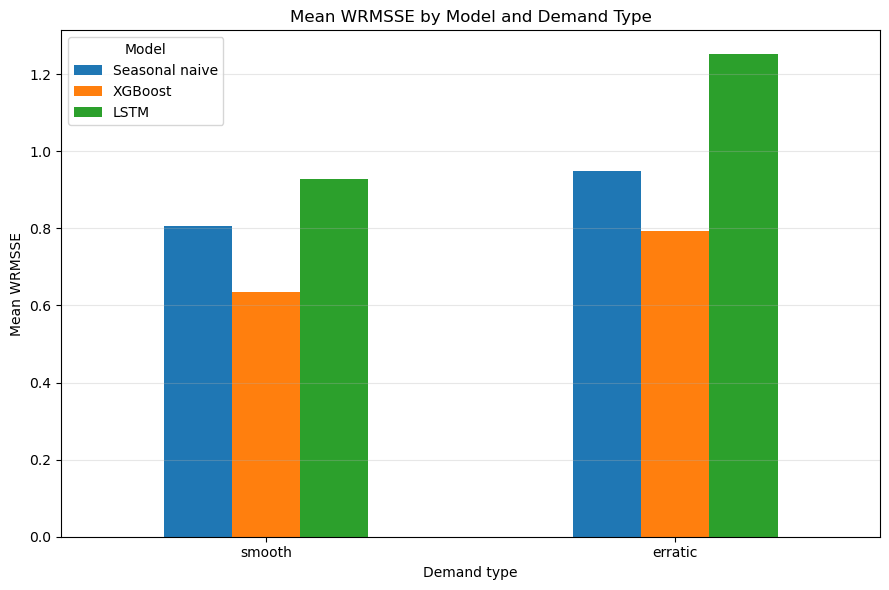

Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step19\step19_mean_wrmsse_by_demand_type.png


In [27]:
# Cell 22: Plot mean WRMSSE by model and demand type

import matplotlib.pyplot as plt

wrmsse_plot_data = (
    step19_report_summary
    .set_index(
        DEMAND_TYPE_COLUMN
    )[
        [
            "mean_seasonal_naive_wrmsse",
            "mean_xgb_wrmsse",
            "mean_lstm_wrmsse",
        ]
    ]
    .rename(
        columns={
            "mean_seasonal_naive_wrmsse":
                "Seasonal naive",
            "mean_xgb_wrmsse":
                "XGBoost",
            "mean_lstm_wrmsse":
                "LSTM",
        }
    )
    .reindex(
        LSTM_DEMAND_TYPES
    )
)

figure, axis = plt.subplots(
    figsize=(9, 6)
)

wrmsse_plot_data.plot(
    kind="bar",
    ax=axis,
)

axis.set_title(
    "Mean WRMSSE by Model and Demand Type"
)

axis.set_xlabel(
    "Demand type"
)

axis.set_ylabel(
    "Mean WRMSSE"
)

axis.tick_params(
    axis="x",
    rotation=0,
)

axis.legend(
    title="Model"
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

STEP19_WRMSSE_FIGURE_FILE = (
    STEP19_FIGURE_DIR
    / "step19_mean_wrmsse_by_demand_type.png"
)

figure.savefig(
    STEP19_WRMSSE_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

if not STEP19_WRMSSE_FIGURE_FILE.exists():
    raise FileNotFoundError(
        "The Step 19 WRMSSE figure was not saved."
    )

print("Saved:")
print(STEP19_WRMSSE_FIGURE_FILE)

### LSTM Performance Relative to XGBoost Across the Hierarchy

The figure shows the percentage difference between LSTM and XGBoost at each M5 hierarchy level. Positive values indicate that the LSTM produced a higher, and therefore worse, level-normalised WRMSSE.

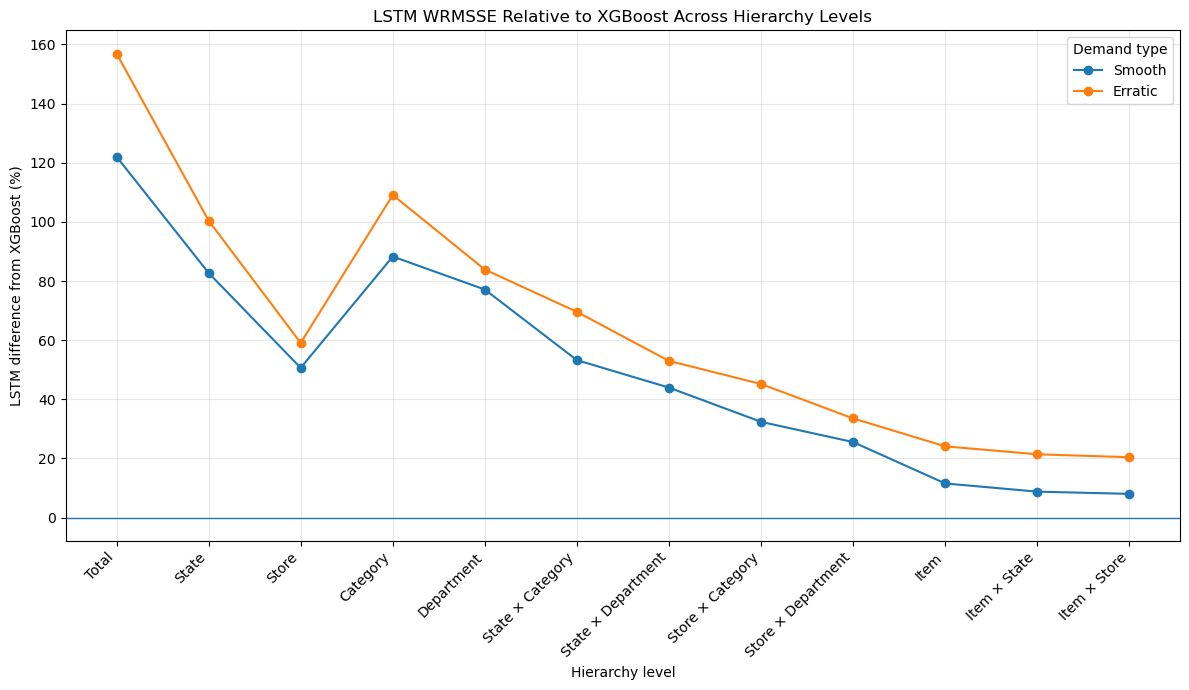

Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step19\step19_lstm_xgb_hierarchy_difference.png


In [28]:
# Cell 23: Plot the LSTM–XGBoost hierarchy difference

hierarchy_level_labels = {
    1: "Total",
    2: "State",
    3: "Store",
    4: "Category",
    5: "Department",
    6: "State × Category",
    7: "State × Department",
    8: "Store × Category",
    9: "Store × Department",
    10: "Item",
    11: "Item × State",
    12: "Item × Store",
}

figure, axis = plt.subplots(
    figsize=(12, 7)
)

for demand_type in LSTM_DEMAND_TYPES:
    demand_rows = (
        hierarchy_comparison.loc[
            hierarchy_comparison[
                DEMAND_TYPE_COLUMN
            ] == demand_type
        ]
        .sort_values(
            "level"
        )
    )

    axis.plot(
        demand_rows["level"],
        demand_rows[
            "lstm_vs_xgb_level_percentage"
        ],
        marker="o",
        label=demand_type.capitalize(),
    )

axis.axhline(
    y=0,
    linewidth=1,
)

axis.set_title(
    "LSTM WRMSSE Relative to XGBoost Across Hierarchy Levels"
)

axis.set_xlabel(
    "Hierarchy level"
)

axis.set_ylabel(
    "LSTM difference from XGBoost (%)"
)

axis.set_xticks(
    list(
        hierarchy_level_labels.keys()
    )
)

axis.set_xticklabels(
    list(
        hierarchy_level_labels.values()
    ),
    rotation=45,
    ha="right",
)

axis.legend(
    title="Demand type"
)

axis.grid(
    alpha=0.3,
)

figure.tight_layout()

STEP19_HIERARCHY_FIGURE_FILE = (
    STEP19_FIGURE_DIR
    / "step19_lstm_xgb_hierarchy_difference.png"
)

figure.savefig(
    STEP19_HIERARCHY_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

if not STEP19_HIERARCHY_FIGURE_FILE.exists():
    raise FileNotFoundError(
        "The hierarchy comparison figure "
        "was not saved."
    )

print("Saved:")
print(STEP19_HIERARCHY_FIGURE_FILE)

### LSTM Mean Forecast Error

The figure reports the average LSTM forecast error for each fold. Negative values indicate underforecasting.

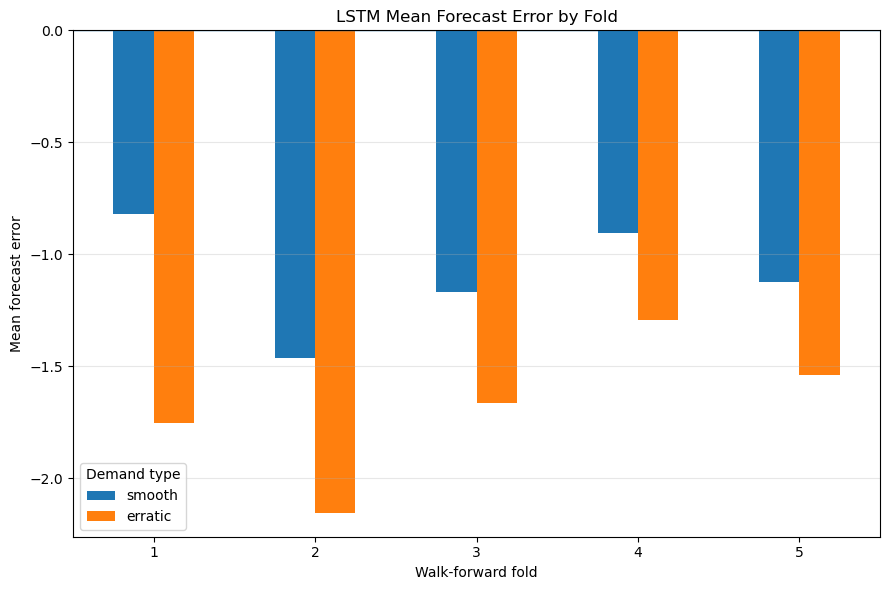

Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\figures\step19\step19_lstm_mean_error_by_fold.png


In [29]:
# Cell 24: Plot LSTM mean forecast error by fold

mean_error_plot_data = (
    model_comparison_by_fold
    .pivot(
        index="fold",
        columns=DEMAND_TYPE_COLUMN,
        values="lstm_mean_error",
    )
    .reindex(
        columns=LSTM_DEMAND_TYPES
    )
)

figure, axis = plt.subplots(
    figsize=(9, 6)
)

mean_error_plot_data.plot(
    kind="bar",
    ax=axis,
)

axis.axhline(
    y=0,
    linewidth=1,
)

axis.set_title(
    "LSTM Mean Forecast Error by Fold"
)

axis.set_xlabel(
    "Walk-forward fold"
)

axis.set_ylabel(
    "Mean forecast error"
)

axis.tick_params(
    axis="x",
    rotation=0,
)

axis.legend(
    title="Demand type"
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

STEP19_BIAS_FIGURE_FILE = (
    STEP19_FIGURE_DIR
    / "step19_lstm_mean_error_by_fold.png"
)

figure.savefig(
    STEP19_BIAS_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

if not STEP19_BIAS_FIGURE_FILE.exists():
    raise FileNotFoundError(
        "The LSTM mean-error figure was not saved."
    )

print("Saved:")
print(STEP19_BIAS_FIGURE_FILE)

## Step 19 Interpretation Log

| Finding | Numerical evidence | Interpretation |
|---|---|---|
| The LSTM did not improve the primary evaluation metric for smooth demand. | Mean LSTM WRMSSE was 0.927770, compared with 0.635986 for XGBoost and 0.806369 for seasonal naive. The LSTM was 45.879% worse than XGBoost and 15.055% worse than seasonal naive. | The compact sequence-only LSTM was not competitive for hierarchical forecasting of smooth demand under the tested design. |
| The LSTM performed even less favourably for erratic demand. | Mean LSTM WRMSSE was 1.251330, compared with 0.793776 for XGBoost and 0.949980 for seasonal naive. The LSTM was 57.643% worse than XGBoost and 31.722% worse than seasonal naive. | Greater demand variability did not create an advantage for the LSTM. |
| XGBoost produced the lowest WRMSSE in every evaluated fold. | XGBoost won 10 of 10 fold-and-demand-type WRMSSE comparisons. The LSTM won 0 of 10. | The engineered-feature XGBoost model remained the strongest model for the primary metric. |
| The LSTM improved bottom-level error relative to seasonal naive but not hierarchical WRMSSE. | The LSTM produced lower MAE and RMSE than seasonal naive in all 10 folds, but higher WRMSSE in all 10 folds. | Improvements in average bottom-level errors did not translate into improved weighted performance across the 12-level hierarchy. |
| The LSTM was generally less accurate than XGBoost at the bottom level. | XGBoost won MAE in 8 of 10 folds and RMSE in 9 of 10 folds. The LSTM won MAE in 2 folds and RMSE in 1 fold. | The LSTM showed limited isolated gains but no stable advantage over XGBoost. |
| LSTM underforecasting was consistent. | Mean forecast error was negative in all 10 folds. The five-fold mean was -1.096112 for smooth demand and -1.680902 for erratic demand. | The direct LSTM forecasts showed systematic downward bias on the original sales scale. |
| The largest LSTM disadvantage appeared at aggregated hierarchy levels. | At Level 1, LSTM level-normalised WRMSSE was 122.060% higher than XGBoost for smooth demand and 156.940% higher for erratic demand. | Small bottom-level forecast biases accumulated when the forecasts were aggregated. |
| The model difference narrowed near the bottom of the hierarchy. | At Level 12, the LSTM was 8.020% worse than XGBoost for smooth demand and 20.411% worse for erratic demand. | The LSTM was relatively closer to XGBoost at the item-store level than at highly aggregated levels. |
| The smooth hierarchy result was fully consistent across folds. | XGBoost produced lower level-normalised WRMSSE at all 12 levels in all five smooth-demand folds. | The smooth-demand hierarchy result was not driven by one unusual fold. |
| The erratic hierarchy result was also strongly consistent. | XGBoost was lower in all five folds at Levels 1–10 and in four of five folds at Levels 11–12. | The two isolated lower-level LSTM wins did not change the overall demand-type result. |
| Epoch selection varied substantially across folds. | Selected epochs ranged from 2 to 17 for smooth demand and from 4 to 13 for erratic demand. Mean selected epochs were 9.4 and 9.2 respectively. | A single fixed training duration would not have represented every fold equally well. |
| The experiment remains a feasibility comparison rather than a controlled architecture comparison. | The LSTM used only 56 historical sales observations, while XGBoost used lag, rolling, calendar, event, SNAP and price features. | The results compare practical forecasting systems with different information sets and do not isolate the effect of algorithm choice alone. |

## Step 19 Surprise Log

| Unexpected result | Numerical evidence | Treatment |
|---|---|---|
| Lower bottom-level errors did not produce lower WRMSSE. | The LSTM beat seasonal naive on MAE and RMSE in all 10 folds but lost on WRMSSE in all 10 folds. | Report the distinction between bottom-level error and weighted hierarchical performance explicitly. |
| The LSTM disadvantage increased sharply after aggregation. | The smooth gap increased from 8.020% at Level 12 to 122.060% at Level 1. The erratic gap increased from 20.411% to 156.940%. | Discuss aggregation sensitivity and systematic forecast bias without making a causal claim. |
| All final LSTM forecasts were biased in the same direction. | All 10 fold-level mean errors were negative. | Treat underforecasting as a consistent descriptive result rather than random fold variation. |
| The sequence-only model failed to recognise the Christmas closure pattern during pilot validation. | On validation horizon 19, corresponding to 25 December 2015, mean actual sales were 0.020 while the mean LSTM forecast was 4.822. | Use this as an example of the limitation created by excluding calendar and event features. |
| The LSTM occasionally beat XGBoost at the lowest erratic hierarchy levels. | LSTM was lower in one of five folds at Levels 11 and 12, although its five-fold mean remained worse by 21.398% and 20.411%. | Retain the fold-level result but do not present it as a general LSTM advantage. |
| Training wall-clock times became highly irregular during the unattended run. | The full run lasted 530.58 minutes, and some individual epochs recorded several hundred seconds despite most epochs taking approximately 25–40 seconds. | Do not use wall-clock runtime to compare model efficiency because the execution environment was not controlled throughout the run. |

In [30]:
# Cell 27: Run the final Step 19 completion audit

import json

print("Running the final Step 19 completion audit")
print("-" * 70)

# ---------------------------------------------------------
# Save the locked Step 19 configuration
# ---------------------------------------------------------

STEP19_CONFIGURATION_FILE = (
    STEP19_TABLE_DIR
    / "step19_configuration.json"
)

step19_configuration = {
    "experiment": {
        "purpose": (
            "Sequence-only LSTM feasibility study"
        ),
        "demand_types": list(
            LSTM_DEMAND_TYPES
        ),
        "folds": 5,
        "models": 10,
        "series_per_model": 200,
        "forecast_horizon_days": (
            OUTPUT_LENGTH
        ),
        "input_history_days": (
            INPUT_LENGTH
        ),
        "forecast_design": (
            "Direct 28-day multi-output"
        ),
    },
    "transformation": {
        "sales_transformation": (
            LOG_TRANSFORMATION
        ),
        "scaling": SCALING_METHOD,
        "scaling_scope": (
            "Fitted separately for each series "
            "using training data only"
        ),
    },
    "architecture": {
        "lstm_units": LSTM_UNITS,
        "dense_units": DENSE_UNITS,
        "model_parameters": 5356,
        "loss": "Mean squared error",
        "optimizer": "Adam",
        "learning_rate": (
            LEARNING_RATE
        ),
        "clipnorm": CLIPNORM,
    },
    "training": {
        "batch_size": BATCH_SIZE,
        "maximum_epochs": MAX_EPOCHS,
        "early_stopping_patience": (
            EARLY_STOPPING_PATIENCE
        ),
        "early_stopping_min_delta": (
            EARLY_STOPPING_MIN_DELTA
        ),
        "inner_validation_days": (
            INNER_VALIDATION_DAYS
        ),
        "seed": SEED,
        "deterministic_operations": True,
    },
    "software": {
        "python_version": (
            sys.version
        ),
        "tensorflow_version": (
            tf.__version__
        ),
        "keras_version": getattr(
            keras,
            "__version__",
            "Not separately exposed",
        ),
        "execution_device": (
            "Windows CPU"
        ),
    },
    "evaluation": {
        "primary_metric": "WRMSSE",
        "secondary_metrics": [
            "MAE",
            "RMSE",
            "Mean forecast error",
        ],
        "hierarchy_levels": 12,
        "comparison_models": [
            "Seasonal naive",
            "XGBoost",
        ],
        "interpretation": (
            "Feasibility comparison, not an "
            "isolated architecture comparison"
        ),
    },
}

with open(
    STEP19_CONFIGURATION_FILE,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        step19_configuration,
        configuration_file,
        indent=2,
    )

# ---------------------------------------------------------
# Define all required named outputs
# ---------------------------------------------------------

required_named_outputs = {
    "CPU benchmark": (
        STEP19_TABLE_DIR
        / "step19_cpu_benchmark.csv"
    ),
    "Pilot selection history": (
        STEP19_TABLE_DIR
        / "step19_pilot_selection_history.csv"
    ),
    "Pilot selection summary": (
        STEP19_TABLE_DIR
        / "step19_pilot_selection_summary.csv"
    ),
    "Pilot validation by horizon": (
        STEP19_TABLE_DIR
        / "step19_pilot_validation_by_horizon.csv"
    ),
    "Pilot outer summary": (
        STEP19_TABLE_DIR
        / "step19_pilot_outer_summary.csv"
    ),
    "Pilot refit history": (
        STEP19_TABLE_DIR
        / "step19_pilot_refit_history.csv"
    ),
    "Final LSTM fold results": (
        STEP19_TABLE_DIR
        / "step19_lstm_fold_results.csv"
    ),
    "Training audit": (
        STEP19_TABLE_DIR
        / "step19_training_audit.csv"
    ),
    "Scorer validation": (
        STEP19_TABLE_DIR
        / "step19_scorer_validation.csv"
    ),
    "Model comparison by fold": (
        STEP19_TABLE_DIR
        / "step19_model_comparison_by_fold.csv"
    ),
    "WRMSSE level results": (
        STEP19_TABLE_DIR
        / "step19_wrmsse_level_results.csv"
    ),
    "Demand-type model summary": (
        STEP19_TABLE_DIR
        / "step19_model_summary_by_demand_type.csv"
    ),
    "Hierarchy model summary": (
        STEP19_TABLE_DIR
        / "step19_hierarchy_model_summary.csv"
    ),
    "Hierarchy comparison": (
        STEP19_TABLE_DIR
        / "step19_hierarchy_comparison.csv"
    ),
    "Fold-level hierarchy comparison": (
        STEP19_TABLE_DIR
        / "step19_fold_level_comparison.csv"
    ),
    "Report-ready summary": (
        STEP19_TABLE_DIR
        / "step19_report_summary.csv"
    ),
    "Combined LSTM predictions": (
        STEP19_RESULT_DIR
        / "step19_lstm_predictions.parquet"
    ),
    "Pilot predictions": (
        STEP19_RESULT_DIR
        / "step19_pilot_fold1_smooth_predictions.parquet"
    ),
    "Pilot epoch-selection figure": (
        STEP19_FIGURE_DIR
        / "step19_pilot_epoch_selection.png"
    ),
    "Mean WRMSSE figure": (
        STEP19_FIGURE_DIR
        / "step19_mean_wrmsse_by_demand_type.png"
    ),
    "Hierarchy-difference figure": (
        STEP19_FIGURE_DIR
        / "step19_lstm_xgb_hierarchy_difference.png"
    ),
    "Mean-error figure": (
        STEP19_FIGURE_DIR
        / "step19_lstm_mean_error_by_fold.png"
    ),
    "Configuration file": (
        STEP19_CONFIGURATION_FILE
    ),
}

missing_required_outputs = [
    output_name
    for output_name, output_path
    in required_named_outputs.items()
    if not output_path.exists()
]

empty_required_outputs = [
    output_name
    for output_name, output_path
    in required_named_outputs.items()
    if (
        output_path.exists()
        and output_path.stat().st_size == 0
    )
]

# ---------------------------------------------------------
# Locate individual model outputs
# ---------------------------------------------------------

individual_model_files = sorted(
    STEP19_MODEL_DIR.glob(
        "lstm_fold*_*.keras"
    )
)

individual_prediction_files = sorted(
    STEP19_RESULT_DIR.glob(
        "step19_lstm_predictions_fold*_*.parquet"
    )
)

selection_history_files = sorted(
    STEP19_TABLE_DIR.glob(
        "step19_selection_history_fold*_*.csv"
    )
)

refit_history_files = sorted(
    STEP19_TABLE_DIR.glob(
        "step19_refit_history_fold*_*.csv"
    )
)

partial_files = sorted(
    list(
        STEP19_TABLE_DIR.glob(
            "*partial*"
        )
    )
    + list(
        STEP19_RESULT_DIR.glob(
            "*partial*"
        )
    )
    + list(
        STEP19_MODEL_DIR.glob(
            "*partial*"
        )
    )
)

individual_prediction_rows = sum(
    pq.ParquetFile(
        prediction_file
    ).metadata.num_rows
    for prediction_file
    in individual_prediction_files
)

combined_prediction_rows = (
    pq.ParquetFile(
        required_named_outputs[
            "Combined LSTM predictions"
        ]
    )
    .metadata
    .num_rows
)

# ---------------------------------------------------------
# Reload the final tables from disk
# ---------------------------------------------------------

audit_lstm_results = pd.read_csv(
    required_named_outputs[
        "Final LSTM fold results"
    ]
)

audit_training_checks = pd.read_csv(
    required_named_outputs[
        "Training audit"
    ]
)

audit_scorer_validation = pd.read_csv(
    required_named_outputs[
        "Scorer validation"
    ]
)

audit_model_comparison = pd.read_csv(
    required_named_outputs[
        "Model comparison by fold"
    ]
)

audit_level_results = pd.read_csv(
    required_named_outputs[
        "WRMSSE level results"
    ]
)

audit_demand_summary = pd.read_csv(
    required_named_outputs[
        "Demand-type model summary"
    ]
)

audit_hierarchy_comparison = pd.read_csv(
    required_named_outputs[
        "Hierarchy comparison"
    ]
)

audit_report_summary = pd.read_csv(
    required_named_outputs[
        "Report-ready summary"
    ]
)

training_audit_passed = (
    audit_training_checks[
        "passed"
    ]
    .astype(str)
    .str.lower()
    .eq("true")
    .all()
)

maximum_scorer_wrmsse_difference = float(
    audit_scorer_validation[
        "absolute_wrmsse_difference"
    ].max()
)

maximum_scorer_mae_difference = float(
    audit_scorer_validation[
        "absolute_mae_difference"
    ].max()
)

maximum_scorer_rmse_difference = float(
    audit_scorer_validation[
        "absolute_rmse_difference"
    ].max()
)

# ---------------------------------------------------------
# Final audit checks
# ---------------------------------------------------------

completion_checks = {
    "Ten final LSTM result rows": (
        len(audit_lstm_results) == 10
    ),
    "Five folds represented": (
        audit_lstm_results[
            "fold"
        ].nunique() == 5
    ),
    "Smooth and erratic represented": (
        set(
            audit_lstm_results[
                DEMAND_TYPE_COLUMN
            ].astype(str)
        )
        == set(LSTM_DEMAND_TYPES)
    ),
    "All selected epochs valid": (
        audit_lstm_results[
            "selected_epochs"
        ].between(
            1,
            MAX_EPOCHS,
            inclusive="both",
        ).all()
    ),
    "Manual and callback epochs agree": (
        (
            audit_lstm_results[
                "manual_selected_epoch"
            ]
            == audit_lstm_results[
                "callback_selected_epoch"
            ]
        ).all()
    ),
    "Ten model files": (
        len(individual_model_files) == 10
    ),
    "All model files non-empty": (
        all(
            model_file.stat().st_size > 0
            for model_file
            in individual_model_files
        )
    ),
    "Ten individual prediction files": (
        len(
            individual_prediction_files
        ) == 10
    ),
    "56,000 rows across individual predictions": (
        individual_prediction_rows
        == 56_000
    ),
    "56,000 combined prediction rows": (
        combined_prediction_rows
        == 56_000
    ),
    "Ten selection-history files": (
        len(selection_history_files)
        == 10
    ),
    "Ten refit-history files": (
        len(refit_history_files)
        == 10
    ),
    "Saved training audit passed": (
        training_audit_passed
    ),
    "Ten scorer-validation rows": (
        len(
            audit_scorer_validation
        ) == 10
    ),
    "XGBoost WRMSSE reproduced within 1e-8": (
        maximum_scorer_wrmsse_difference
        < 1e-8
    ),
    "XGBoost MAE reproduced within 1e-8": (
        maximum_scorer_mae_difference
        < 1e-8
    ),
    "XGBoost RMSE reproduced within 1e-8": (
        maximum_scorer_rmse_difference
        < 1e-8
    ),
    "Ten model-comparison rows": (
        len(
            audit_model_comparison
        ) == 10
    ),
    "XGBoost won all ten WRMSSE comparisons": (
        audit_model_comparison[
            "wrmsse_winner"
        ].eq(
            "XGBoost"
        ).all()
    ),
    "All ten LSTM mean errors negative": (
        audit_model_comparison[
            "lstm_mean_error"
        ].lt(0).all()
    ),
    "240 hierarchy-level result rows": (
        len(
            audit_level_results
        ) == 240
    ),
    "Two demand-type summary rows": (
        len(
            audit_demand_summary
        ) == 2
    ),
    "24 hierarchy-comparison rows": (
        len(
            audit_hierarchy_comparison
        ) == 24
    ),
    "Twelve levels per demand type": (
        audit_hierarchy_comparison
        .groupby(
            DEMAND_TYPE_COLUMN,
            observed=True,
        )["level"]
        .nunique()
        .eq(12)
        .all()
    ),
    "Two report-summary rows": (
        len(
            audit_report_summary
        ) == 2
    ),
    "Report conclusion recorded": (
        audit_report_summary[
            "feasibility_result"
        ]
        .eq(
            "LSTM did not improve WRMSSE"
        )
        .all()
    ),
    "All four figures exist": (
        all(
            required_named_outputs[
                figure_name
            ].exists()
            for figure_name in [
                "Pilot epoch-selection figure",
                "Mean WRMSSE figure",
                "Hierarchy-difference figure",
                "Mean-error figure",
            ]
        )
    ),
    "No required named output missing": (
        len(
            missing_required_outputs
        ) == 0
    ),
    "No required named output empty": (
        len(
            empty_required_outputs
        ) == 0
    ),
    "No partial files remain": (
        len(partial_files) == 0
    ),
}

completion_audit_table = pd.DataFrame(
    {
        "check": completion_checks.keys(),
        "passed": completion_checks.values(),
    }
)

display(
    completion_audit_table
)

failed_completion_checks = [
    check
    for check, passed
    in completion_checks.items()
    if not passed
]

if failed_completion_checks:
    raise AssertionError(
        "Step 19 completion audit failed:\n- "
        + "\n- ".join(
            failed_completion_checks
        )
    )

STEP19_COMPLETION_AUDIT_FILE = (
    STEP19_TABLE_DIR
    / "step19_completion_audit.csv"
)

completion_audit_table.to_csv(
    STEP19_COMPLETION_AUDIT_FILE,
    index=False,
)

print()
print("Step 19 output audit")
print("-" * 70)
print(
    "Required named outputs:",
    len(required_named_outputs),
)
print(
    "Individual model files:",
    len(individual_model_files),
)
print(
    "Individual prediction files:",
    len(individual_prediction_files),
)
print(
    "Rows across individual predictions:",
    f"{individual_prediction_rows:,}",
)
print(
    "Combined prediction rows:",
    f"{combined_prediction_rows:,}",
)
print(
    "Selection-history files:",
    len(selection_history_files),
)
print(
    "Refit-history files:",
    len(refit_history_files),
)
print(
    "Missing required outputs:",
    missing_required_outputs,
)
print(
    "Empty required outputs:",
    empty_required_outputs,
)
print(
    "Remaining partial files:",
    [
        str(partial_file)
        for partial_file
        in partial_files
    ],
)
print(
    "Maximum scorer WRMSSE difference:",
    f"{maximum_scorer_wrmsse_difference:.12e}",
)
print(
    "Maximum scorer MAE difference:",
    f"{maximum_scorer_mae_difference:.12e}",
)
print(
    "Maximum scorer RMSE difference:",
    f"{maximum_scorer_rmse_difference:.12e}",
)

print()
print("Step 19 completion audit passed.")
print("Saved:")
print(STEP19_COMPLETION_AUDIT_FILE)
print(STEP19_CONFIGURATION_FILE)

Running the final Step 19 completion audit
----------------------------------------------------------------------


,check,passed
0,Ten final LSTM result rows,True
1,Five folds represented,True
2,Smooth and erratic represented,True
3,All selected epochs valid,True
4,Manual and callback epochs agree,True
5,Ten model files,True
6,All model files non-empty,True
7,Ten individual prediction files,True
8,"56,000 rows across individual predictions",True
9,"56,000 combined prediction rows",True



Step 19 output audit
----------------------------------------------------------------------
Required named outputs: 23
Individual model files: 10
Individual prediction files: 10
Rows across individual predictions: 56,000
Combined prediction rows: 56,000
Selection-history files: 10
Refit-history files: 10
Missing required outputs: []
Empty required outputs: []
Remaining partial files: []
Maximum scorer WRMSSE difference: 1.110223024625e-16
Maximum scorer MAE difference: 4.440892098501e-16
Maximum scorer RMSE difference: 4.440892098501e-16

Step 19 completion audit passed.
Saved:
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_completion_audit.csv
C:\Users\gamec\Documents\MSc_Dissertation_M5\outputs\tables\step19\step19_configuration.json
